In [1]:
import pandas as pd
import sklearn
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df1 = pd.read_excel('/Users/polina/b2b_reccomendation_systems/correct_data_2015_all.xlsx')

In [3]:
df1.shape

(382178, 26)

In [4]:
df2 = pd.read_excel('/Users/polina/b2b_reccomendation_systems/correct_data_2020_all.xlsx')

In [5]:
df2.shape

(109900, 26)

In [6]:
df = pd.concat([df1, df2])
df

,Уровень,Заказчик,ИНН заказчика,Стоимость(руб.) Заказчик,Реестровый номер публикации,Идентификационный код закупки,Сфера деятельности,Регион поставки,Город поставки,Дата публикации,...,Статус допуска,"Снижение на торгах,%",Форма публикации,Тип торгов,Обеспечение заявки (руб.),"Обеспечение заявки, %",Обеспечение контракта (руб.),"Обеспечение контракта, %",РНП сейчас,РНП ранее
0,1,"АНО ""ДФИКММ ЧО""",7451432207,1.464126e+07,0321718002DP,NaN,"[ОКПД2 27.20] Батареи и аккумуляторы, [ОКВЭД2 ...",Челябинская область,Челябинск,2018-12-14 12:35:50,...,Допущен,0.048235,Торговая процедура,Иной способ,NaN,NaN,NaN,NaN,0,0
1,2,"АНО ""ДФИКММ ЧО""",7451432207,NaN,0321718003DP,NaN,[ОКПД2 28.25] Оборудование промышленное холоди...,Челябинская область,Челябинск,2018-12-14 12:39:28,...,Не допущен,0.171902,Торговая процедура,NaN,NaN,NaN,NaN,NaN,0,0
2,2,"АНО ""ДФИКММ ЧО""",7451432207,NaN,0321718003DP,NaN,[ОКПД2 28.25] Оборудование промышленное холоди...,Челябинская область,Челябинск,2018-12-14 12:39:28,...,Допущен,0.166269,Торговая процедура,NaN,NaN,NaN,NaN,NaN,0,0
3,2,"ООО ""ЗНСМ""",7710305634,NaN,1000111,NaN,[ОКПД2 41.20] Здания и работы по возведению зд...,Архангельская область,Архангельская область,2018-04-06 12:16:40,...,Неизвестно,-0.089841,Торговая процедура,NaN,NaN,NaN,NaN,NaN,0,0
4,2,"ООО ""ЗНСМ""",7710305634,NaN,1000111,NaN,[ОКПД2 41.20] Здания и работы по возведению зд...,Архангельская область,Архангельская область,2018-04-06 12:16:40,...,Неизвестно,-0.307809,Торговая процедура,NaN,NaN,NaN,NaN,NaN,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
109895,2,"АО ""МОСВОДОКАНАЛ""",7701984274,4.812948e+06,32009305437,NaN,[ОКПД2 71.12] Услуги в области инженерно-техни...,Москва,Москва,2020-07-09 09:01:44,...,Допущен,0.000000,Торговая процедура,NaN,NaN,NaN,NaN,NaN,0,0
109896,2,МАОУ СОШ № 38,3906045856,7.685720e+05,32110152379,NaN,[ОКПД2 46.90] Услуги по неспециализированной о...,Калининградская область,Калининградская область,2021-04-01 18:18:20,...,Допущен,-0.033996,Торговая процедура,NaN,NaN,NaN,NaN,NaN,0,0
109897,2,"АО ""ОЗК""",7708632345,7.307850e+08,32211237428,NaN,[ОКПД2 52.10] Услуги по складированию и хранен...,Москва,Москва,2022-03-18 18:20:39,...,Допущен,0.029126,Торговая процедура,NaN,5000.0,0.000007,NaN,NaN,0,0
109898,2,"МУП АГО ""АНГАРСКИЙ ВОДОКАНАЛ""",3801006828,9.015408e+06,32211471613,NaN,"[ОКПД2 80.10] Услуги охранных служб, в том чис...",Иркутская область,Иркутская область,2022-06-15 16:51:50,...,Допущен,0.370089,Торговая процедура,NaN,450770.4,0.050000,NaN,NaN,0,0


In [7]:
rev = pd.read_excel('/Users/polina/b2b_reccomendation_systems/revenue_spark_final.xlsx')

In [8]:
rev

,ИНН поставщика,Адрес,Отрасль,Выручка,Персонал,Сводный риск
0,272909593,"450095, Башкортостан Респ, г.о. город Уфа, г У...","Торговля оптовая лесоматериалами, строительным...",NaN,1.0,Высокий риск
1,7805363761,"198095, г. Санкт-Петербург, ул. Зои Космодемья...",Строительство водных сооружений,5.959000e+07,14.0,Низкий риск
2,2320033513,"354000, Краснодарский кр., г. Сочи, проспект К...",Деятельность гостиниц и прочих мест для времен...,3.402400e+08,104.0,Низкий риск
3,7722327689,"630007, Новосибирская обл., г. Новосибирск, ул...",Деятельность курьерская,4.243533e+10,NaN,Низкий риск
4,6453128666,"410065, Саратовская обл., г. Саратов, ул. Одес...",Торговля оптовая одеждой и обувью,NaN,NaN,Недействующий
...,...,...,...,...,...,...
79907,2466192870,"660028, Красноярский край, г.о. город Краснояр...",Производство электромонтажных работ,5.805300e+07,2.0,Низкий риск
79908,2337022573,"353387, Краснодарский кр., Крымский район, г. ...",Строительство жилых и нежилых зданий,1.563000e+06,1.0,Низкий риск
79909,7706193727,"107589, г. Москва, ул. Красноярская, д. 11 к. А",Производство электромонтажных работ,2.263000e+07,17.0,Высокий риск
79910,5408302159,"681024, Хабаровский край, г.о. город Комсомоль...",Научные исследования и разработки в области ес...,5.503000e+06,NaN,Высокий риск


In [9]:
df_new = df.merge(rev, on='ИНН поставщика', how='left')
df_new

,Уровень,Заказчик,ИНН заказчика,Стоимость(руб.) Заказчик,Реестровый номер публикации,Идентификационный код закупки,Сфера деятельности,Регион поставки,Город поставки,Дата публикации,...,"Обеспечение заявки, %",Обеспечение контракта (руб.),"Обеспечение контракта, %",РНП сейчас,РНП ранее,Адрес,Отрасль,Выручка,Персонал,Сводный риск
0,1,"АНО ""ДФИКММ ЧО""",7451432207,1.464126e+07,0321718002DP,NaN,"[ОКПД2 27.20] Батареи и аккумуляторы, [ОКВЭД2 ...",Челябинская область,Челябинск,2018-12-14 12:35:50,...,NaN,NaN,NaN,0,0,"454080, Челябинская обл., г. Челябинск, ул. Эн...",Торговля оптовая производственным электротехни...,3.639350e+08,22.0,Низкий риск
1,2,"АНО ""ДФИКММ ЧО""",7451432207,NaN,0321718003DP,NaN,[ОКПД2 28.25] Оборудование промышленное холоди...,Челябинская область,Челябинск,2018-12-14 12:39:28,...,NaN,NaN,NaN,0,0,"454092, Челябинская обл., г. Челябинск, ул. Ки...","Производство электромонтажных, санитарно-техни...",1.269900e+07,2.0,Высокий риск
2,2,"АНО ""ДФИКММ ЧО""",7451432207,NaN,0321718003DP,NaN,[ОКПД2 28.25] Оборудование промышленное холоди...,Челябинская область,Челябинск,2018-12-14 12:39:28,...,NaN,NaN,NaN,0,0,"119435, г. Москва, вн.тер.г. муниципальный окр...",Строительство жилых и нежилых зданий,4.652704e+09,360.0,Низкий риск
3,2,"ООО ""ЗНСМ""",7710305634,NaN,1000111,NaN,[ОКПД2 41.20] Здания и работы по возведению зд...,Архангельская область,Архангельская область,2018-04-06 12:16:40,...,NaN,NaN,NaN,0,0,"169711, Коми респ., г. Усинск, ул. Парковая, д...",Строительство жилых и нежилых зданий,9.009080e+08,219.0,Низкий риск
4,2,"ООО ""ЗНСМ""",7710305634,NaN,1000111,NaN,[ОКПД2 41.20] Здания и работы по возведению зд...,Архангельская область,Архангельская область,2018-04-06 12:16:40,...,NaN,NaN,NaN,0,0,"385140, Адыгея респ., Тахтамукайский район, пг...",Строительство жилых и нежилых зданий,1.520000e+06,2.0,Высокий риск
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
492073,2,"АО ""МОСВОДОКАНАЛ""",7701984274,4.812948e+06,32009305437,NaN,[ОКПД2 71.12] Услуги в области инженерно-техни...,Москва,Москва,2020-07-09 09:01:44,...,NaN,NaN,NaN,0,0,"111141, г. Москва, ул. Плеханова, д. 7 офис 60...","Технические испытания, исследования, анализ и ...",4.867000e+07,18.0,Средний риск
492074,2,МАОУ СОШ № 38,3906045856,7.685720e+05,32110152379,NaN,[ОКПД2 46.90] Услуги по неспециализированной о...,Калининградская область,Калининградская область,2021-04-01 18:18:20,...,NaN,NaN,NaN,0,0,"236029, Калининградская обл., г. Калининград, ...",Торговля розничная по почте или по информацион...,1.342000e+06,NaN,Высокий риск
492075,2,"АО ""ОЗК""",7708632345,7.307850e+08,32211237428,NaN,[ОКПД2 52.10] Услуги по складированию и хранен...,Москва,Москва,2022-03-18 18:20:39,...,0.000007,NaN,NaN,0,0,"663613, Красноярский кр., г. Канск, ул. Комсом...",Хранение и складирование зерна,8.656100e+07,51.0,Низкий риск
492076,2,"МУП АГО ""АНГАРСКИЙ ВОДОКАНАЛ""",3801006828,9.015408e+06,32211471613,NaN,"[ОКПД2 80.10] Услуги охранных служб, в том чис...",Иркутская область,Иркутская область,2022-06-15 16:51:50,...,0.050000,NaN,NaN,0,0,"665826, Иркутская обл., г. Ангарск, микрорайон...","Деятельность охранных служб, в том числе частных",8.723400e+07,66.0,Низкий риск


In [10]:
pd.options.display.float_format = '{:,.2f}'.format 

Появились новые данные - в них включена выручка и сводный риск компании поставщика. Разберемся с ними

In [11]:
df = df_new.copy()

In [12]:
df['Сводный риск'].unique()

array(['Низкий риск', 'Высокий риск', 'Средний риск', 'Недействующий',
       'Риск не определен', nan], dtype=object)

In [13]:
df.loc[df['Сводный риск'] == 'Высокий риск', 'Сводный риск'] = 3
df.loc[df['Сводный риск'] == 'Средний риск', 'Сводный риск'] = 2
df.loc[df['Сводный риск'] == 'Низкий риск', 'Сводный риск'] = 1
df.loc[(df['Сводный риск'] == 'Риск не определен') | (df['Сводный риск'] == 'Недействующий'), 'Сводный риск'] = 0

print(df['Сводный риск'].describe())
print(df['Сводный риск'].value_counts())
print(f"Количество пропусков в сводном риске: {df['Сводный риск'].isna().sum()}")

count     427850
unique         4
top            1
freq      267260
Name: Сводный риск, dtype: int64
Сводный риск
1    267260
2     58280
0     58010
3     44300
Name: count, dtype: int64
Количество пропусков в сводном риске: 64228


Здесь пропуски можем заполнить нулями - поскольку туда попадают компании с недействующим (то есть уже не существующие) и с неопределенным риском

In [14]:
df['Сводный риск'] = df['Сводный риск'].fillna(0)
print(df['Сводный риск'].isna().sum())

0


/var/folders/7_/sz_ftshd1b1b9sppxlm9vj9m0000gn/T/ipykernel_72457/3347266145.py:1: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Сводный риск'] = df['Сводный риск'].fillna(0)


In [15]:
print(df['Выручка'].describe())
print(f"Количество пропусков в выручке: {df['Выручка'].isna().sum()}")


count             313,091.00
mean        6,211,559,339.42
std        43,893,504,233.41
min            -1,800,000.00
25%            41,570,500.00
50%           155,690,000.00
75%           700,383,000.00
max     3,791,566,978,000.00
Name: Выручка, dtype: float64
Количество пропусков в выручке: 178987


***EDA***

In [16]:
df.isna().sum()

Уровень                                                                                                                     0
Заказчик                                                                                                                    0
ИНН заказчика                                                                                                               0
Стоимость(руб.) Заказчик                                                                                                46532
Реестровый номер публикации                                                                                                 0
Идентификационный код закупки                                                                                          458321
Сфера деятельности                                                                                                         14
Регион поставки                                                                                                       

In [17]:
df.groupby("Реестровый номер публикации").count()

,Уровень,Заказчик,ИНН заказчика,Стоимость(руб.) Заказчик,Идентификационный код закупки,Сфера деятельности,Регион поставки,Город поставки,Дата публикации,Дата окончания приема заявок / Дата планового окончания исполнения контракта / Плановая дата публикации лота по ППГ,...,"Обеспечение заявки, %",Обеспечение контракта (руб.),"Обеспечение контракта, %",РНП сейчас,РНП ранее,Адрес,Отрасль,Выручка,Персонал,Сводный риск
Реестровый номер публикации,,,,,,,,,,,,,,,,,,,,,
54383,7,7,7,0,0,7,7,7,7,7,...,0,0,0,7,7,7,7,5,5,7
1420408,2,2,2,2,0,2,2,2,2,2,...,0,0,0,2,2,2,2,2,2,2
1423175,2,2,2,2,0,2,2,2,2,2,...,0,0,0,2,2,2,2,2,2,2
1423763,2,2,2,0,0,2,2,2,2,2,...,0,0,0,2,2,2,2,2,1,2
1426970,2,2,2,0,0,2,2,2,2,2,...,0,0,0,2,2,2,2,2,1,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
966553,2,2,2,0,0,2,2,2,2,2,...,0,0,0,2,2,2,2,1,1,2
970998,5,5,5,0,0,5,5,5,5,5,...,0,0,0,5,5,5,5,3,3,5
973130,2,2,2,0,0,2,2,2,2,2,...,0,0,0,2,2,2,2,2,2,2


In [18]:
df[df["Реестровый номер публикации"] == 54383]

,Уровень,Заказчик,ИНН заказчика,Стоимость(руб.) Заказчик,Реестровый номер публикации,Идентификационный код закупки,Сфера деятельности,Регион поставки,Город поставки,Дата публикации,...,"Обеспечение заявки, %",Обеспечение контракта (руб.),"Обеспечение контракта, %",РНП сейчас,РНП ранее,Адрес,Отрасль,Выручка,Персонал,Сводный риск
455521,2,"ПАО ""Т ПЛЮС""",6315376946,NaN,54383,NaN,"[ОКПД2 32.99] Изделия готовые прочие, не включ...",Московская область,Красногорск,2020-07-17 17:17:59,...,NaN,NaN,NaN,0,0,"193091, г. Санкт-Петербург, набережная Октябрь...",Торговля оптовая неспециализированная,"1,494,795,000.00",47.00,1
456508,2,"ПАО ""Т ПЛЮС""",6315376946,NaN,54383,NaN,"[ОКПД2 32.99] Изделия готовые прочие, не включ...",Московская область,Красногорск,2020-07-17 17:17:59,...,NaN,NaN,NaN,0,0,"117292, г. Москва, вн.тер.г. муниципальный окр...",Производство спецодежды,"15,171,994,000.00",136.00,1
473786,2,"ПАО ""Т ПЛЮС""",6315376946,NaN,54383,NaN,"[ОКПД2 32.99] Изделия готовые прочие, не включ...",Московская область,Красногорск,2020-07-17 17:17:59,...,NaN,NaN,NaN,0,0,"193091, г. Санкт-Петербург, набережная Октябрь...",Торговля оптовая неспециализированная,"1,494,795,000.00",47.00,1
477919,2,"ПАО ""Т ПЛЮС""",6315376946,NaN,54383,NaN,"[ОКПД2 32.99] Изделия готовые прочие, не включ...",Московская область,Красногорск,2020-07-17 17:17:59,...,NaN,NaN,NaN,0,0,"117105, г. Москва, вн.тер.г. муниципальный окр...",Производство спецодежды,"1,446,961,000.00",37.00,1
481074,2,"ПАО ""Т ПЛЮС""",6315376946,NaN,54383,NaN,"[ОКПД2 32.99] Изделия готовые прочие, не включ...",Московская область,Красногорск,2020-07-17 17:17:59,...,NaN,NaN,NaN,0,0,"142400, Московская обл., г. Ногинск, ул. Рабоч...",Производство спецодежды,NaN,NaN,2
485931,2,"ПАО ""Т ПЛЮС""",6315376946,NaN,54383,NaN,"[ОКПД2 32.99] Изделия готовые прочие, не включ...",Московская область,Красногорск,2020-07-17 17:17:59,...,NaN,NaN,NaN,0,0,"153031, Ивановская обл., г. Иваново, лн. 23-Я,...",Производство спецодежды,NaN,NaN,2
489726,2,"ПАО ""Т ПЛЮС""",6315376946,NaN,54383,NaN,"[ОКПД2 32.99] Изделия готовые прочие, не включ...",Московская область,Красногорск,2020-07-17 17:17:59,...,NaN,NaN,NaN,0,0,"193091, г. Санкт-Петербург, набережная Октябрь...",Торговля оптовая неспециализированная,"1,494,795,000.00",47.00,1


In [19]:
df['Статус допуска'].unique()

array(['Допущен', 'Не допущен', 'Неизвестно'], dtype=object)

In [20]:
np.where(
    (df["Победитель"] == "Победитель") & 
    (df["Статус допуска"].isin(["Не допущен", "Неизвестно"])), 
    1, 
    0
).sum()

np.int64(8336)

In [21]:
np.where(
    (df["Победитель"] == "Победитель") & 
    (df["Статус допуска"] == "Не допущен"), 
    1, 
    0
).sum()

#спокойно удаляем

np.int64(7)

In [22]:
np.where(
    (df["Победитель"] == "Победитель") & 
    (df["Статус допуска"] == "Неизвестно"), 
    1, 
    0
).sum()

np.int64(8329)

**Обработаем отсутствующие значения:** 

Как видно выше, участники тендера, не ставшие победителями, в столбце "Победитель" имеют значения (NaN), поэтому заменим их на участников. Если же в тендере только один участник, то он и будет победителем (даже если значение в столбце "Победитель" - NaN). Если же в тендере один участник, и он не допущен (столбец - статус допуска), то такие тендеры не учитываем. Если же компания является победителем, но статус допуска у нее "Неизвестно", для упрощения можем такие компании также считать победителями. Если компания -  победитель, но статус у нее - "Не допущен", то можем удалить, их очень мало

In [17]:
tender_participants = df.groupby("Реестровый номер публикации")["ИНН поставщика"].count().reset_index()
tender_participants.columns = ["Реестровый номер публикации", "participants_count"]
df = df.merge(tender_participants, on="Реестровый номер публикации")

#тендеры с одним участником, который не допущен
df = df[~((df["participants_count"] == 1) & (df["Статус допуска"] == "Не допущен"))]

# победитель имеет статус "Не допущен"
df = df[~((df["Победитель"] == "Победитель") & (df["Статус допуска"] == "Не допущен"))]

df["Победитель"] = np.where(
    (df["Победитель"] == "Победитель") | (df["participants_count"] == 1) | ((df["Победитель"] == "Победитель") & (df["Статус допуска"] == "Неизвестно")),
    1, 0
)

df["Статус допуска"] = np.where(df["Статус допуска"] == "Допущен", 1, 0)

In [18]:
df['Тип торгов'].unique()

array(['Иной способ', nan, 'Запрос предложений', 'Запрос котировок',
       'Прямые закупки', 'Запрос цен', 'Конкурс открытый',
       'Запрос котировок в электронной форме',
       'Запрос предложений в электронной форме',
       'Закупка у единственного поставщика (исполнителя, подрядчика)',
       'Аукцион электронный', 'Аукцион открытый',
       'Отбор квалификационный', 'Открытый конкурс в электронной форме',
       'Запрос котировок закрытый',
       'Запрос предложений с квалификационным отбором',
       'Переговоры конкурентные',
       'Переговоры конкурентные с квалификационным отбором',
       'Аукцион с квалификационным отбором',
       'Запрос котировок с квалификационным отбором', 'Мелкая закупка',
       'Конкурс открытый с ограниченным участием (с предквалификационным отбором)',
       'Маркетинговое исследование', 'Внутригрупповые закупки',
       'Отбор предварительный', 'Запрос предложений закрытый',
       'Аукцион закрытый', 'Конкурс двухэтапный'], dtype=object)

**Отсутствующие значения в обеспечении**

Их можем заполнить нулями, поскольку пропуски означают, что обеспечение установлено не было

In [19]:
df[['Обеспечение заявки (руб.)',
       'Обеспечение заявки, %', 'Обеспечение контракта (руб.)',
       'Обеспечение контракта, %']] = df[['Обеспечение заявки (руб.)',
       'Обеспечение заявки, %', 'Обеспечение контракта (руб.)',
       'Обеспечение контракта, %']].fillna(0)

**Обработаем отсутствующие значения:** 

В столбце Тип торгов достаточно много пропусков, заменим их просто на "Неизвестно". Так как у нас есть реестровый номер публикации, идентификационный код закупки с большим количеством пропусков можем удалить. Есть еще несколько пропусков в столбце Сфере деятельности - в силу специфики задачи можем удалить

*Пропусков в столбце Стоимость (руб.) Заказчик достаточно много, заменим их на медиану по тому же заказчику и той же сфере деятельности, если же по такой сфере нет, но по заказчику есть, то заменим на медиану по заказчику, аналогично при отсутствии данных по заказчику - если и заказчик, и сфера новая, то заменим на медиану по региону - иначе, на глобальную*

Протестируем, как именно лучше заполнить пропуски в Стоимости и Выручке, посмотрев на распределение

In [20]:
df['Тип торгов'] = df['Тип торгов'].fillna('Неизвестно')
df = df.drop(columns=['Идентификационный код закупки'])

In [21]:
df = df[df['Сфера деятельности'].notna()]

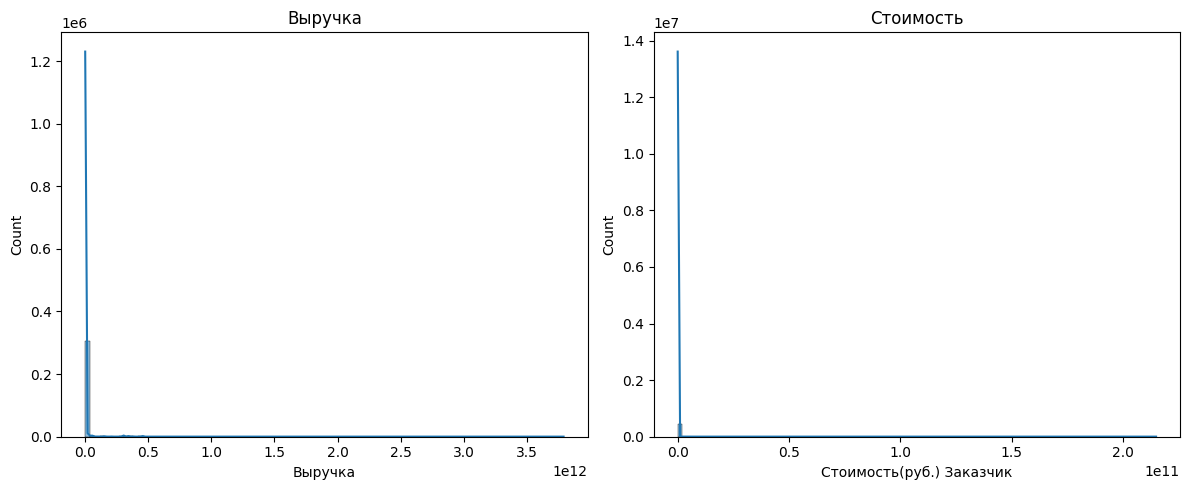

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.histplot(df['Выручка'], ax=axes[0], kde=True, bins=100).set_title('Выручка')
sns.histplot(df['Стоимость(руб.) Заказчик'], ax=axes[1], kde=True, bins=100).set_title('Стоимость')
plt.tight_layout()
plt.show()

Попробуем построить в логарифмах и с обрезанными квантилями - ничего не видно 

/Users/polina/b2b_reccomendation_systems/.venv/lib/python3.13/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


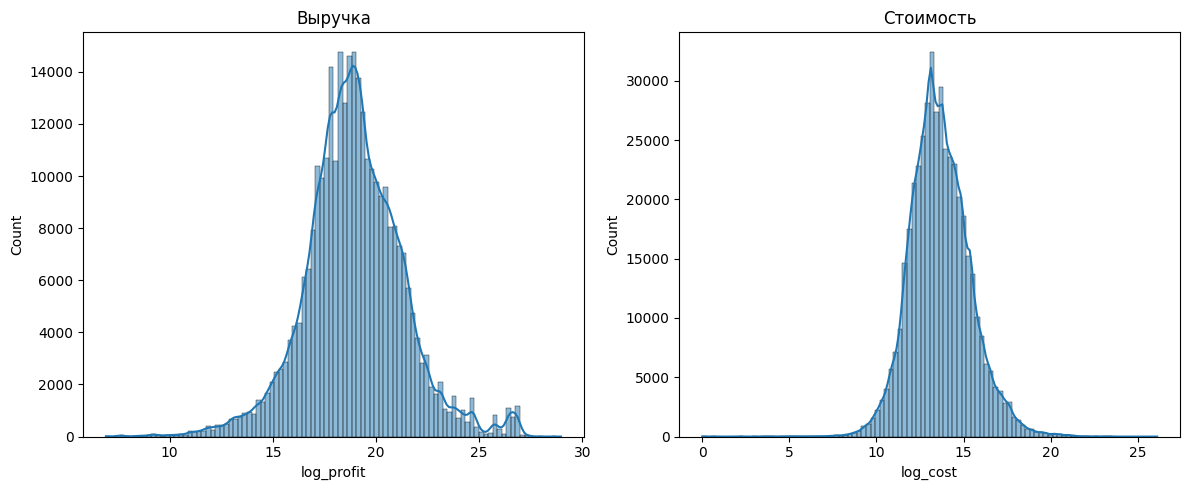

In [35]:
df['log_profit'] = np.log1p(df['Выручка'])
df['log_cost'] = np.log1p(df['Стоимость(руб.) Заказчик'])
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.histplot(df['log_profit'], ax=axes[0], kde=True, bins=100).set_title('Выручка')
sns.histplot(df['log_cost'], ax=axes[1], kde=True, bins=100).set_title('Стоимость')
plt.tight_layout()
plt.show()

Выручка: 1%=831000.00, 99%=52299742000.00
Стоимость: 1%=29980.16, 99%=44779970.00


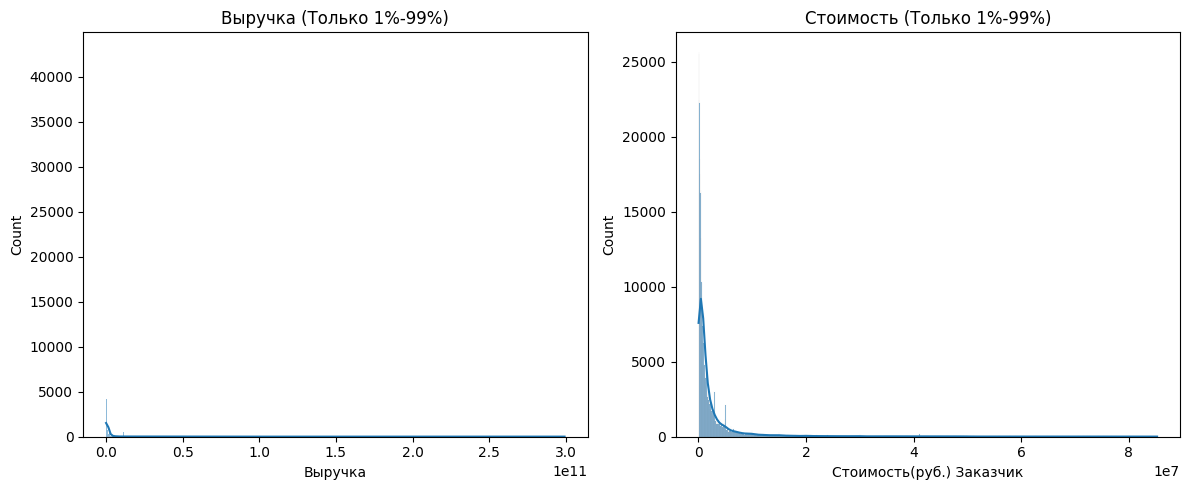

In [36]:
df_filtered_vis = df[(df['Выручка'] >= df['Выручка'].quantile(0.01)) & (df['Выручка'] <= df['Выручка'].quantile(0.99))]
df_filtered_vis_cost = df[(df['Стоимость(руб.) Заказчик'] >= df['Стоимость(руб.) Заказчик'].quantile(0.01)) & (df['Стоимость(руб.) Заказчик'] <= df['Стоимость(руб.) Заказчик'].quantile(0.99))]

print(f"Выручка: 1%={df_filtered_vis['Выручка'].quantile(0.01):.2f}, 99%={df_filtered_vis['Выручка'].quantile(0.99):.2f}")
print(f"Стоимость: 1%={df_filtered_vis_cost['Стоимость(руб.) Заказчик'].quantile(0.01):.2f}, 99%={df_filtered_vis_cost['Стоимость(руб.) Заказчик'].quantile(0.99):.2f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.histplot(df_filtered_vis['Выручка'], ax=axes[0], kde=True).set_title('Выручка (Только 1%-99%)')
sns.histplot(df_filtered_vis_cost['Стоимость(руб.) Заказчик'], ax=axes[1], kde=True).set_title('Стоимость (Только 1%-99%)')
plt.tight_layout()
plt.show()

Выручка: 10%=25847000.00, 90%=1215665000.00
Стоимость: 10%=190698.24, 90%=3757615.14


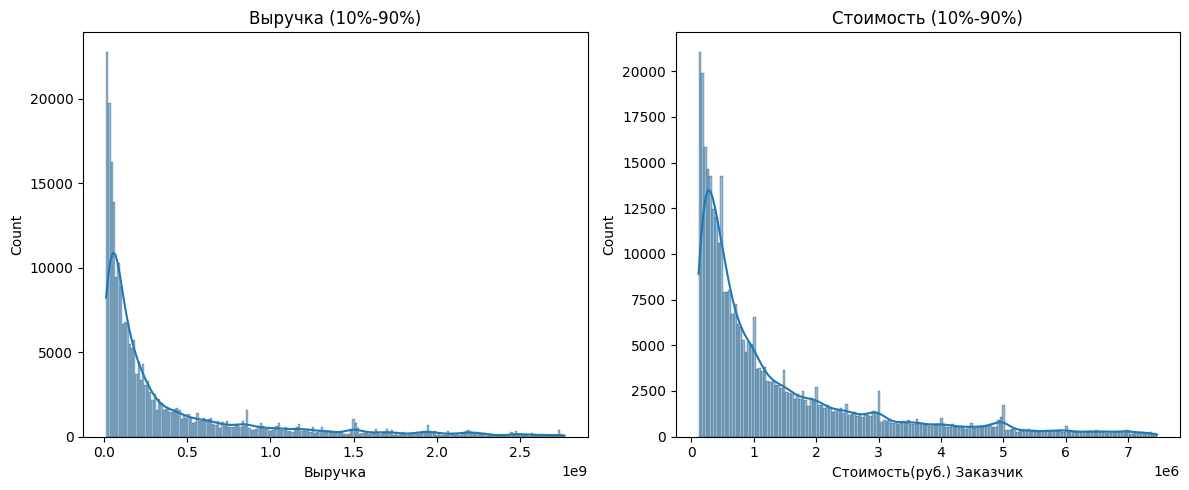

In [37]:
df_filtered_vis = df[(df['Выручка'] >= df['Выручка'].quantile(0.1)) & (df['Выручка'] <= df['Выручка'].quantile(0.9))]
df_filtered_vis_cost = df[(df['Стоимость(руб.) Заказчик'] >= df['Стоимость(руб.) Заказчик'].quantile(0.1)) & (df['Стоимость(руб.) Заказчик'] <= df['Стоимость(руб.) Заказчик'].quantile(0.9))]

print(f"Выручка: 10%={df_filtered_vis['Выручка'].quantile(0.1):.2f}, 90%={df_filtered_vis['Выручка'].quantile(0.9):.2f}")
print(f"Стоимость: 10%={df_filtered_vis_cost['Стоимость(руб.) Заказчик'].quantile(0.1):.2f}, 90%={df_filtered_vis_cost['Стоимость(руб.) Заказчик'].quantile(0.9):.2f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.histplot(df_filtered_vis['Выручка'], ax=axes[0], kde=True).set_title('Выручка (10%-90%)')
sns.histplot(df_filtered_vis_cost['Стоимость(руб.) Заказчик'], ax=axes[1], kde=True).set_title('Стоимость (10%-90%)')
plt.tight_layout()
plt.show()

Теперь перейдем к заполнению пропусков - судя по данным, можно попробовать также заполнять пропуски и на лографмированных признаках (особенно если мы берем заполнение через разные imputer методы) - потому что заполнение на исходных данных будет подстраиваться под распределение с очень длинным правым хвостом, получится менее точно, а логарифмированное распределение значительно ближе к нормальному

После заполнения любым способом будем сравнивать распределения

In [24]:
sphere_company_median = df.groupby(['ИНН заказчика', 'Сфера деятельности'])['Стоимость(руб.) Заказчик'].transform('median')
company_median = df.groupby('ИНН заказчика')['Стоимость(руб.) Заказчик'].transform('median')
sphere_median = df.groupby('Сфера деятельности')['Стоимость(руб.) Заказчик'].transform('median')
region_median = df.groupby('Регион поставки')['Стоимость(руб.) Заказчик'].transform('median')
global_median = df['Стоимость(руб.) Заказчик'].median()
new_df = df.copy()
new_df['Стоимость(руб.) Заказчик'] = np.where(df['Стоимость(руб.) Заказчик'].isna(),
                sphere_company_median.fillna(company_median.fillna(sphere_median.fillna(region_median.fillna(global_median)))),
                df['Стоимость(руб.) Заказчик']
    )

sphere_company_median = df.groupby(['ИНН заказчика', 'Сфера деятельности'])['Выручка'].transform('median')
company_median = df.groupby('ИНН заказчика')['Выручка'].transform('median')
sphere_median = df.groupby('Сфера деятельности')['Выручка'].transform('median')
region_median = df.groupby('Регион поставки')['Выручка'].transform('median')
global_median = df['Выручка'].median()

new_df['Выручка'] = np.where(df['Выручка'].isna(),
                sphere_company_median.fillna(company_median.fillna(sphere_median.fillna(region_median.fillna(global_median)))),
                df['Выручка']
    )

In [25]:
print(f"Выручка до заполнения: {df['Выручка'].describe()}")
print(f"Выручка c заполнением медианами: {new_df['Выручка'].describe()}")

Выручка до заполнения: count              74,416.00
mean        7,463,411,174.99
std        50,026,467,915.84
min                 1,000.00
25%            40,097,000.00
50%           167,641,000.00
75%           792,944,250.00
max     3,791,566,978,000.00
Name: Выручка, dtype: float64
Выручка c заполнением медианами: count             109,875.00
mean        5,680,442,152.37
std        42,622,232,339.13
min                 1,000.00
25%            39,607,000.00
50%           141,539,000.00
75%           570,515,000.00
max     3,791,566,978,000.00
Name: Выручка, dtype: float64


In [26]:
print(f"Стоимость до заполнения: {df['Стоимость(руб.) Заказчик'].describe()}")
print(f"Стоимость c заполнением медианами: {new_df['Стоимость(руб.) Заказчик'].describe()}")

Стоимость до заполнения: count           73,066.00
mean         5,265,719.69
std        171,559,420.74
min                  2.00
25%            163,807.30
50%            403,298.35
75%          1,192,338.75
max     39,006,943,870.00
Name: Стоимость(руб.) Заказчик, dtype: float64
Стоимость c заполнением медианами: count          109,875.00
mean         6,823,500.70
std        149,839,439.22
min                  2.00
25%            222,766.88
50%            517,442.70
75%          1,806,271.45
max     39,006,943,870.00
Name: Стоимость(руб.) Заказчик, dtype: float64


С медианой по нелогарифмированным данным распределение достаточно сильно изменяется. Попробуем использовать аналогичное с логарифмом (для сравнения распределений от логарифмов будем назад переходить к исходным признакам)

In [27]:
sphere_company_median = df.groupby(['ИНН заказчика', 'Сфера деятельности'])['log_cost'].transform('median')
company_median = df.groupby('ИНН заказчика')['log_cost'].transform('median')
sphere_median = df.groupby('Сфера деятельности')['log_cost'].transform('median')
region_median = df.groupby('Регион поставки')['log_cost'].transform('median')
global_median = df['log_cost'].median()
new_df['log_cost'] = np.where(df['log_cost'].isna(),
                sphere_company_median.fillna(company_median.fillna(sphere_median.fillna(region_median.fillna(global_median)))),
                df['log_cost']
    )

sphere_company_median = df.groupby(['ИНН заказчика', 'Сфера деятельности'])['log_profit'].transform('median')
company_median = df.groupby('ИНН заказчика')['log_profit'].transform('median')
sphere_median = df.groupby('Сфера деятельности')['log_profit'].transform('median')
region_median = df.groupby('Регион поставки')['log_profit'].transform('median')
global_median = df['log_profit'].median()

new_df['log_profit'] = np.where(df['log_profit'].isna(),
                sphere_company_median.fillna(company_median.fillna(sphere_median.fillna(region_median.fillna(global_median)))),
                df['log_profit']
)

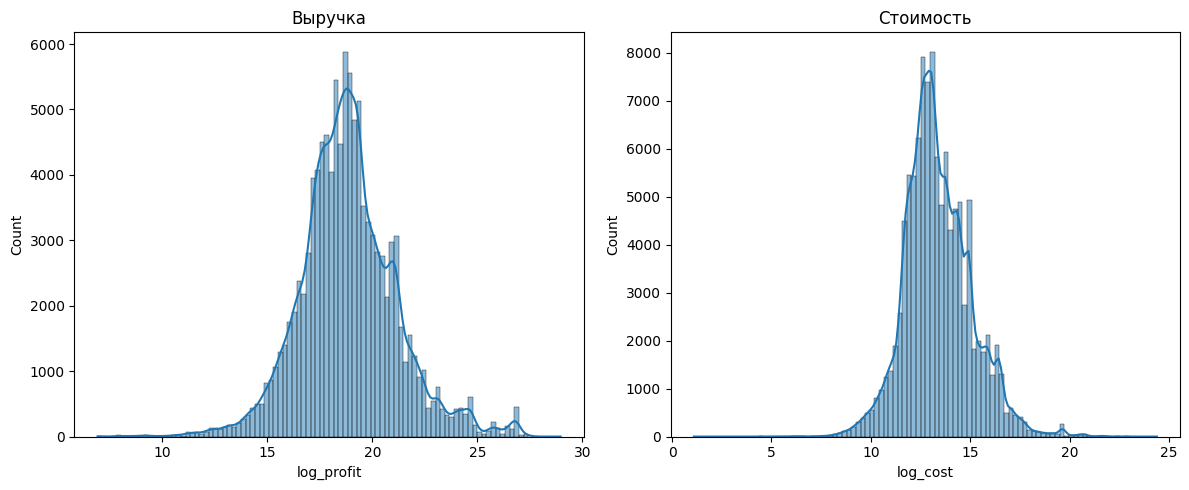

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.histplot(new_df['log_profit'], ax=axes[0], kde=True, bins=100).set_title('Выручка')
sns.histplot(new_df['log_cost'], ax=axes[1], kde=True, bins=100).set_title('Стоимость')
plt.tight_layout()
plt.show()

In [29]:
print(f"Выручка до заполнения: {df['Выручка'].describe()}")
print(f"Выручка c заполнением медианами по логарифмам: {np.expm1(new_df['log_profit']).describe()}")

Выручка до заполнения: count              74,416.00
mean        7,463,411,174.99
std        50,026,467,915.84
min                 1,000.00
25%            40,097,000.00
50%           167,641,000.00
75%           792,944,250.00
max     3,791,566,978,000.00
Name: Выручка, dtype: float64
Выручка c заполнением медианами по логарифмам: count             109,875.00
mean        5,539,737,913.40
std        42,296,409,656.02
min                 1,000.00
25%            38,499,000.00
50%           138,257,000.00
75%           558,463,000.00
max     3,791,566,977,999.99
Name: log_profit, dtype: float64


In [30]:
print(f"Стоимость до заполнения: {df['Стоимость(руб.) Заказчик'].describe()}")
print(f"Стоимость c заполнением медианами по логарифмам: {np.expm1(new_df['log_cost']).describe()}")

Стоимость до заполнения: count           73,066.00
mean         5,265,719.69
std        171,559,420.74
min                  2.00
25%            163,807.30
50%            403,298.35
75%          1,192,338.75
max     39,006,943,870.00
Name: Стоимость(руб.) Заказчик, dtype: float64
Стоимость c заполнением медианами по логарифмам: count          109,875.00
mean         6,679,700.24
std        149,649,739.94
min                  2.00
25%            222,200.00
50%            512,850.00
75%          1,797,261.81
max     39,006,943,870.00
Name: log_cost, dtype: float64


Само распредление стало немного ближе к нормальному - из медиан этот вариант лучший. В дальнейшем будем использовать логарифмированные признаки стоимости и выручки. Попробуем KNN

In [31]:
from sklearn.impute import KNNImputer
from sklearn.preprocessing import RobustScaler

knn_df = df.copy()
#scaler = RobustScaler()
#knn_df[['Выручка', 'Стоимость(руб.) Заказчик']] = scaler.fit_transform(knn_df[['Выручка', 'Стоимость(руб.) Заказчик']])
imputer = KNNImputer(n_neighbors=7, weights='distance')
knn_df[['Выручка', 'Стоимость(руб.) Заказчик']] = imputer.fit_transform(knn_df[['Выручка', 'Стоимость(руб.) Заказчик']])

KeyboardInterrupt: 

In [32]:
print(f"Выручка до заполнения: {df['Выручка'].describe()}")
print(f"Выручка c заполнением KNN: {knn_df['Выручка'].describe()}")

Выручка до заполнения: count              74,416.00
mean        7,463,411,174.99
std        50,026,467,915.84
min                 1,000.00
25%            40,097,000.00
50%           167,641,000.00
75%           792,944,250.00
max     3,791,566,978,000.00
Name: Выручка, dtype: float64
Выручка c заполнением KNN: count             109,875.00
mean       50,749,615,388.82
std       120,941,377,824.47
min                 1,000.00
25%            76,966,000.00
50%           474,296,000.00
75%         7,463,411,174.99
max     3,791,566,978,000.00
Name: Выручка, dtype: float64


In [ ]:
print(f"Стоимость до заполнения: {df['Стоимость(руб.) Заказчик'].describe()}")
print(f"Стоимость c заполнением KNN: {knn_df['Стоимость(руб.) Заказчик'].describe()}")

Стоимость до заполнения: count           73,066.00
mean         5,265,719.69
std        171,559,420.74
min                  2.00
25%            163,807.30
50%            403,298.35
75%          1,192,338.75
max     39,006,943,870.00
Name: Стоимость(руб.) Заказчик, dtype: float64
Стоимость c заполнением KNN: count          109,875.00
mean         5,926,638.92
std        141,763,560.25
min                  2.00
25%            222,438.28
50%            601,865.98
75%          2,821,500.00
max     39,006,943,870.00
Name: Стоимость(руб.) Заказчик, dtype: float64


Явно использовать KNN для выручки - идея плохая, но вот для стоимости он показывает наилучший результат из всех перебранных выше (вероятно, в силу распределений этих признаков - для выручки оно слишком "острое") Попробую заполнить по логарифмам через KNN

In [34]:
imputer = KNNImputer(n_neighbors=7, weights='distance')
knn_df[['log_cost', 'log_profit']] = imputer.fit_transform(knn_df[['log_cost', 'log_profit']])

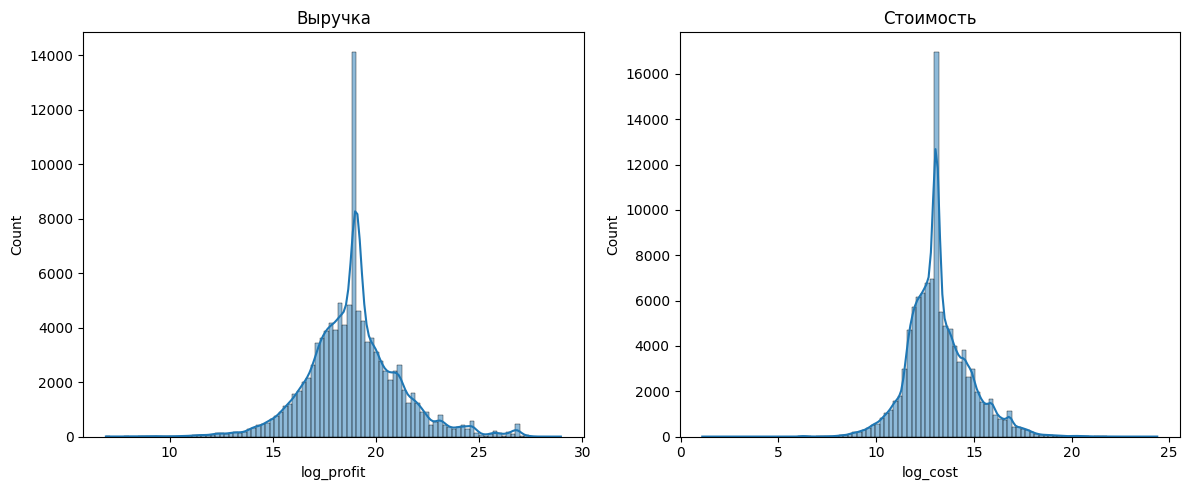

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.histplot(knn_df['log_profit'], ax=axes[0], kde=True, bins=100).set_title('Выручка')
sns.histplot(knn_df['log_cost'], ax=axes[1], kde=True, bins=100).set_title('Стоимость')
plt.tight_layout()
plt.show()

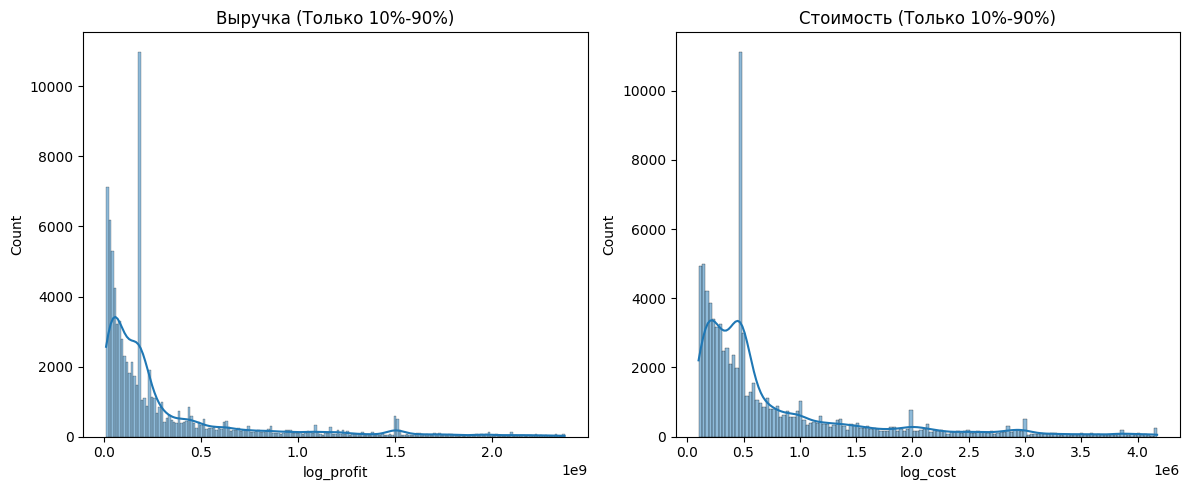

In [36]:
df_filtered_vis = knn_df[(knn_df['log_profit'] >= knn_df['log_profit'].quantile(0.1)) & (knn_df['log_profit'] <= knn_df['log_profit'].quantile(0.9))]
df_filtered_vis_cost = knn_df[(knn_df['log_cost'] >= knn_df['log_cost'].quantile(0.1)) & (knn_df['log_cost'] <= knn_df['log_cost'].quantile(0.9))]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.histplot(np.expm1(df_filtered_vis['log_profit']), ax=axes[0], kde=True).set_title('Выручка (Только 10%-90%)')
sns.histplot(np.expm1(df_filtered_vis_cost['log_cost']), ax=axes[1], kde=True).set_title('Стоимость (Только 10%-90%)')
plt.tight_layout()
plt.show()

In [37]:
print(f"Выручка до заполнения: {df['Выручка'].describe()}")
print(f"Выручка c заполнением KNN: {np.expm1(knn_df['log_profit']).describe()}")

Выручка до заполнения: count              74,416.00
mean        7,463,411,174.99
std        50,026,467,915.84
min                 1,000.00
25%            40,097,000.00
50%           167,641,000.00
75%           792,944,250.00
max     3,791,566,978,000.00
Name: Выручка, dtype: float64
Выручка c заполнением KNN: count             109,875.00
mean        5,351,358,437.26
std        41,867,388,110.88
min                 1,000.00
25%            45,754,500.00
50%           179,963,000.00
75%           492,211,000.00
max     3,791,566,977,999.99
Name: log_profit, dtype: float64


In [38]:
print(f"Стоимость до заполнения: {df['Стоимость(руб.) Заказчик'].describe()}")
print(f"Стоимость c заполнением KNN: {np.expm1(knn_df['log_cost']).describe()}")

Стоимость до заполнения: count           73,066.00
mean         5,265,719.69
std        171,559,420.74
min                  2.00
25%            163,807.30
50%            403,298.35
75%          1,192,338.75
max     39,006,943,870.00
Name: Стоимость(руб.) Заказчик, dtype: float64
Стоимость c заполнением KNN: count          109,875.00
mean         4,528,428.68
std        140,699,235.66
min                  2.00
25%            205,675.06
50%            475,471.99
75%          1,209,972.06
max     39,006,943,870.00
Name: log_cost, dtype: float64


Очевидно получилось сомнительно, судя по распределению. Последний вариант - IterativeImputer (строящий m регрессий и основывающий заполнение на них)

In [22]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.ensemble import RandomForestRegressor

ii_df = df.copy()

imputer = IterativeImputer(estimator=RandomForestRegressor(n_estimators=50, random_state=42, bootstrap=True), max_iter=10, verbose=2)
ii_df[['Стоимость(руб.) Заказчик', 'Выручка']] = imputer.fit_transform(ii_df[['Стоимость(руб.) Заказчик', 'Выручка']])

[IterativeImputer] Completing matrix with shape (492057, 2)
[IterativeImputer] Ending imputation round 1/10, elapsed time 55.71
[IterativeImputer] Change: 1240237396890.654, scaled tolerance: 3791566978.0 
[IterativeImputer] Ending imputation round 2/10, elapsed time 124.38
[IterativeImputer] Change: 339245375931.5, scaled tolerance: 3791566978.0 
[IterativeImputer] Ending imputation round 3/10, elapsed time 193.67
[IterativeImputer] Change: 333860282673.3333, scaled tolerance: 3791566978.0 
[IterativeImputer] Ending imputation round 4/10, elapsed time 260.90
[IterativeImputer] Change: 333860282673.3333, scaled tolerance: 3791566978.0 
[IterativeImputer] Ending imputation round 5/10, elapsed time 328.05
[IterativeImputer] Change: 333860282673.3333, scaled tolerance: 3791566978.0 
[IterativeImputer] Ending imputation round 6/10, elapsed time 397.50
[IterativeImputer] Change: 333860282673.3333, scaled tolerance: 3791566978.0 
[IterativeImputer] Ending imputation round 7/10, elapsed time 

/Users/polina/b2b_reccomendation_systems/.venv/lib/python3.13/site-packages/sklearn/impute/_iterative.py:895: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


In [23]:
print(f"Выручка до заполнения: {df['Выручка'].describe()}")
print(f"Выручка c заполнением IterativeImputer: {ii_df['Выручка'].describe()}")

Выручка до заполнения: count             313,075.00
mean        6,211,676,950.68
std        43,894,579,599.05
min            -1,800,000.00
25%            41,572,000.00
50%           155,690,000.00
75%           700,383,000.00
max     3,791,566,978,000.00
Name: Выручка, dtype: float64
Выручка c заполнением IterativeImputer: count             492,057.00
mean        5,779,529,728.37
std        37,309,085,663.08
min            -1,800,000.00
25%            69,023,000.00
50%           254,889,228.95
75%         1,253,809,000.00
max     3,791,566,978,000.00
Name: Выручка, dtype: float64


In [24]:
print(f"Стоимость до заполнения: {df['Стоимость(руб.) Заказчик'].describe()}")
print(f"Стоимость c заполнением IterativeImputer: {ii_df['Стоимость(руб.) Заказчик'].describe()}")

Стоимость до заполнения: count           445,539.00
mean          9,282,725.88
std         364,006,582.91
min                   0.01
25%             272,115.42
50%             760,000.00
75%           2,457,953.39
max     214,829,922,014.64
Name: Стоимость(руб.) Заказчик, dtype: float64
Стоимость c заполнением IterativeImputer: count           492,057.00
mean         10,005,182.22
std         346,782,023.53
min                   0.01
25%             301,128.00
50%             890,000.00
75%           2,986,497.13
max     214,829,922,014.64
Name: Стоимость(руб.) Заказчик, dtype: float64


Лучшим способом заполнения пропусков оказался IterativeImputer, берем его

- Сохраняет среднее лучше всего: для выручки реальное среднее без пропусков - 7.46 млрд, IterativeImputer - 6.79 млрд, по медианам получилось 5.68 млрд или 5.54 млрд для лог-версии, KNN также сильно занизил (а на оришинальных данных видимо обучился по выбросам, но при применении скелеров становится еще хуже). По стоимости значение еще ближе: при среднем без пропусков 5.27 млн IterativeImputer дает 5.18 млн, медианы и KNN его сильно завысили

- По медиане сравнение в целом почти полностью в его пользу -  выручка: IterativeImputer также ближе всего к исходной (168 млн) - получилось 164 млн, KNN на логарифмах сильно сломал распредление, остальные занизили медиану слишком сильно. По стоимости: все способы ее завышают (403 тыс.), в наименьшей степени это делает KNN на логарифмах, который не рассматриваем в силу крайне странного распределения. IterativeImputer получает (590 тыс.)

- Рассмотрим интерквартильный размах (IQR): 
  - Выручка (исходный): 793M - 40M = 753M
  - Median: 571M - 40M = 531M
  - Median log: 558M - 38M = 520M
  - KNN log: 492M - 46M = 446M
  - Iterative: 911M - 61M = 850M
  - Стоимость (исходный): 1192k - 164k = 1028k
  - Median: 1806k - 223k = 1583k
  - Median log: 1797k - 222k = 1575k
  - KNN log: 1210k - 206k = 1004k
  - Iterative: 1469k - 223k = 1246k
  IterativeImputer для выручки немного увеличил IQR, но для стоимости сохранил его относительно близко. По сравнению с другими, он хорошо сохранил IQR для обеих переменных

- Все методы предсказуемо уменьшили стандартное отклонение, так как заполнение ~33% данных значениями, которые менее экстремальны, чем исходные выбросы, снижает общий разброс. IterativeImputer снизил std примерно в той же мере, что и другие методы

Глобально, IterativeImputer (как и KNN) использует информацию из других столбцов для предсказания пропущенных значений, что приводит к более реалистичным заполнениям. Получается, IterativeImputer сохраняет наилучший баланс между сохранением статистических характеристик (среднее, медиана, IQR) для обоих признаков и использованием потенциально более точного подхода к заполнению, использующего взаимосвязи в данных. Методы заполнения медианой слишком сильно искажают статистики, а методы KNN показали либо нестабильность, либо плохие распределения

In [26]:
df['Выручка'] = ii_df['Выручка']
df['Стоимость(руб.) Заказчик'] = ii_df['Стоимость(руб.) Заказчик']
#df = df.drop(columns=['log_profit', 'log_cost'])

In [27]:
df.isna().sum()

Уровень                                                                                                                     0
Заказчик                                                                                                                    0
ИНН заказчика                                                                                                               0
Стоимость(руб.) Заказчик                                                                                                    0
Реестровый номер публикации                                                                                                 0
Сфера деятельности                                                                                                          0
Регион поставки                                                                                                             0
Город поставки                                                                                                        

Вроде все победили, теперь посмотрим на выбросы

In [28]:
df.dtypes

Уровень                                                                                                                         int64
Заказчик                                                                                                                       object
ИНН заказчика                                                                                                                   int64
Стоимость(руб.) Заказчик                                                                                                      float64
Реестровый номер публикации                                                                                                    object
Сфера деятельности                                                                                                             object
Регион поставки                                                                                                                object
Город поставки                                                

In [29]:
def find_outliers_iqr(series, multiplier=1.5):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1

    if iqr == 0:
        median = series.median()
        lower_bound = median
        upper_bound = median
        outlier_indices = series.index[series != median]
    else:
        lower_bound = q1 - multiplier * iqr
        upper_bound = q3 + multiplier * iqr
        outlier_indices = series.index[(series < lower_bound) | (series > upper_bound)]
        
    return outlier_indices, lower_bound, upper_bound

In [30]:
cols_to_analyze = [
    'Стоимость(руб.) Заказчик',
    'Снижение на торгах,%',
    'Выручка',
    'Сводный риск',
    'Уровень'
]

print(" Анализ выбросов через  IQR ")
print("_" * 40)

outlier_details = {}
for col in cols_to_analyze:
    n_unique = df[col].nunique()
    print(f"\nСтолбец '{col}' имеет  {n_unique} уникальных значений")
    outlier_indices, lower_bound, upper_bound = find_outliers_iqr(df[col])
    n_outliers = len(outlier_indices)
    perc_outliers = (n_outliers / len(df)) * 100
    print(f"Нижняя граница: {lower_bound:,.2f}")
    print(f"Верхняя граница: {upper_bound:,.2f}")
    print(f"Найдено выбросов: {n_outliers}")
    print(f"Процент выбросов: {perc_outliers:.2f}%")
        
    outlier_details[col] = {
            'indices': outlier_indices,
            'lower_bound': lower_bound,
            'upper_bound': upper_bound,
            'percentage': perc_outliers
        }
    

 Анализ выбросов через  IQR 
________________________________________

Столбец 'Стоимость(руб.) Заказчик' имеет  173780 уникальных значений
Нижняя граница: -3,726,925.69
Верхняя граница: 7,014,550.82
Найдено выбросов: 68111
Процент выбросов: 13.84%

Столбец 'Снижение на торгах,%' имеет  349506 уникальных значений
Нижняя граница: -0.33
Верхняя граница: 0.57
Найдено выбросов: 29959
Процент выбросов: 6.09%

Столбец 'Выручка' имеет  123971 уникальных значений
Нижняя граница: -1,708,156,000.00
Верхняя граница: 3,030,988,000.00
Найдено выбросов: 78850
Процент выбросов: 16.02%

Столбец 'Сводный риск' имеет  4 уникальных значений
Нижняя граница: 1.00
Верхняя граница: 1.00
Найдено выбросов: 224810
Процент выбросов: 45.69%

Столбец 'Уровень' имеет  2 уникальных значений
Нижняя граница: 2.00
Верхняя граница: 2.00
Найдено выбросов: 104617
Процент выбросов: 21.26%


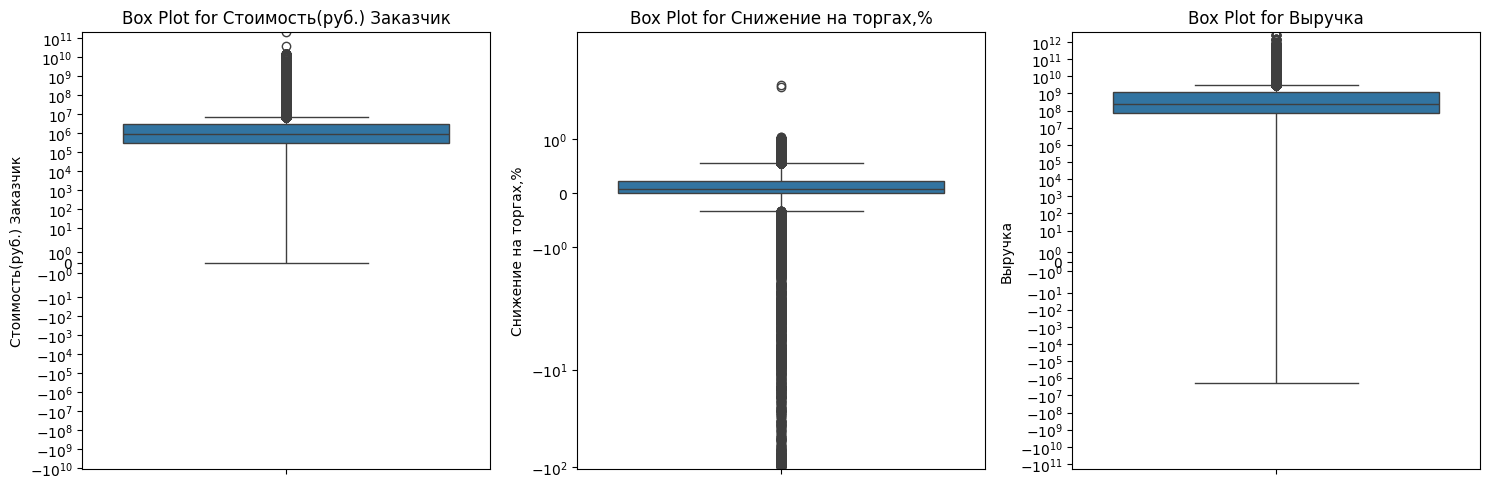

In [31]:
n_cols_plot = 3
n_rows_plot = 1
plt.figure(figsize=(n_cols_plot * 5, n_rows_plot * 5)) 
plot_index = 1
for col in ['Стоимость(руб.) Заказчик', 'Снижение на торгах,%', 'Выручка']:
    plt.subplot(n_rows_plot, n_cols_plot, plot_index)
    min_val = df[col].min() 
    max_val = df[col].max()
    use_symlog = (max_val > 1000 and min_val >= 0) or (min_val < 0) 
    sns.boxplot(y=df[col])
    plt.title(f'Box Plot for {col}')
    if use_symlog:
        plt.yscale('symlog')
    plot_index += 1

plt.tight_layout()
plt.show()

Границы для ограничения: 1% = -0.19, 99% = 1.00


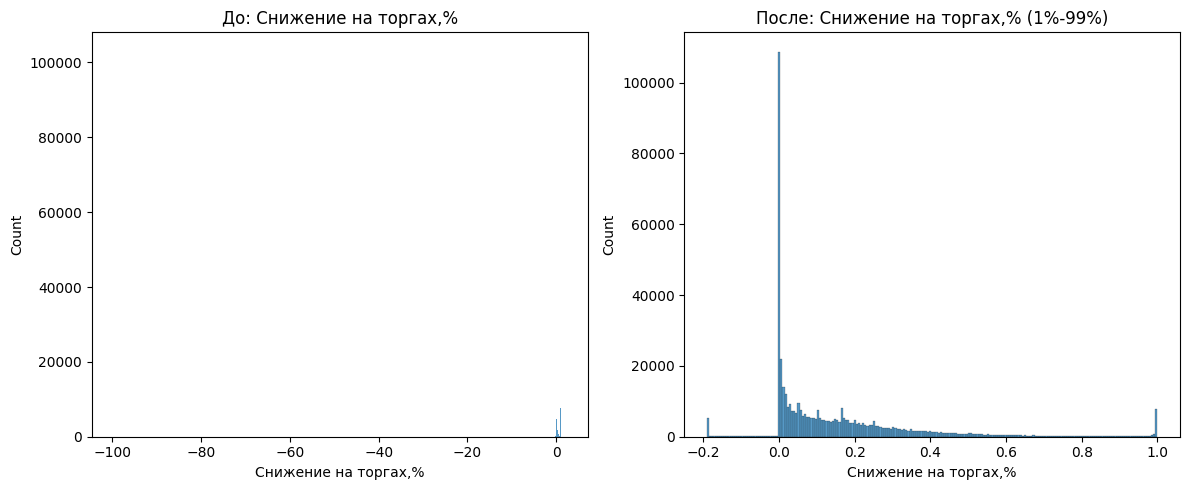

In [33]:
target_col_for_winsorize = 'Снижение на торгах,%' 
p01 = df[target_col_for_winsorize].quantile(0.01)
p99 = df[target_col_for_winsorize].quantile(0.99)
print(f"Границы для ограничения: 1% = {p01:.2f}, 99% = {p99:.2f}")
df_processed = df.copy() 
df_processed[target_col_for_winsorize] = df_processed[target_col_for_winsorize].clip(lower=p01, upper=p99)

plt.figure(figsize=(12, 5))
    
plt.subplot(1, 2, 1)
sns.histplot(df[target_col_for_winsorize], kde=False)
plt.title(f"До: {target_col_for_winsorize}")
    
plt.subplot(1, 2, 2)
sns.histplot(df_processed[target_col_for_winsorize], kde=False)
plt.title(f"После: {target_col_for_winsorize} (1%-99%)")
plt.tight_layout()
plt.show()

In [34]:
m = df[df[target_col_for_winsorize] <= 0][target_col_for_winsorize]
print(m.unique().tolist())
print(f'Number of negative values: {m.shape[0]}')
print(f'Percent of negative values: {m.shape[0]/df.shape[0]*100}%')

[-0.08984091877144011, -0.3078091025257281, -0.0889291956892501, -0.4701606883794684, -0.05555710815217031, -0.1692893774387642, -0.3728768610446743, -0.795742392736407, 0.0, -0.1499999390794231, -0.03790124043479236, -0.1214397379251023, -0.03861851841712463, -0.07447451480760191, -0.1930608401552711, -0.05095798862809561, -0.2513254105832122, -0.1593427756068454, -2.827315486564031e-07, -2.78193030050664e-06, -0.01173253203234465, -0.1739561142962019, -0.1689812685794573, -1.54697336474868, -0.2005980711216144, -0.02608632040604039, -0.6648668106551476, -0.2749942857142857, -0.2003527582445636, -0.45328375, -0.99269125, -0.12171, -0.1054141666666667, -0.1696325469115524, -0.7464212831616146, -1.534359912398586, -1.527411216465084, -0.02934172387435383, -0.03959641326893282, -2.39561602683779, -0.2, -0.4878826666666667, -0.2891713853644939, -0.1626135503354951, -0.2701341647770219, -0.0969751, -1.07759375, -13.87033887614679, -14.927624872579, -14.17356724643221, -6.299489546390994, -

Как можно заметить, доля выбросов достаточно большая - от 8 до 13-16% от всех данных, поэтому удалять их не будем в таком виде - кажется, что такие данные отражают в том числе и специфику. Когда будут данные, повторю анализ с учетом обеспечения - и вероятно часть из них и не будет выбросами. Вместо этого логарифмирую столбцы Выручки и Стоимости, со снижением на торгах ситуация интересная - так как есть большое число отрицательных значений (видимо повышения стоимости на торгах), ну явно не будем трогать

In [35]:
df['log_profit'] = np.log1p(df['Выручка'])
df['log_cost'] = np.log1p(df['Стоимость(руб.) Заказчик'])

/Users/polina/b2b_reccomendation_systems/.venv/lib/python3.13/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


____________________________________________________________________________________________________________________


**Feature engineering**

Вопрос, как делить данные на test и train. С одной стороны, лучше бы не использовать будущие тендеры для предикта по текущим. С другой стороны, данные по компаниям за разные года не сильно пересекаются. Покажу, почему берем именно так (и в любом случае пропсуки будем заполнять по медиане/среднему, а не дропать, иначе тестовых совсем не будет)

In [36]:
df['year'] = df['Дата публикации'].dt.year
df['month'] = df['Дата публикации'].dt.month

Количество строк по годам:
year
2015    0.35
2016    0.55
2017    0.35
2018    5.81
2019   70.61
2020   11.75
2021    3.81
2022    2.95
2023    1.92
2024    1.65
2025    0.24
Name: count, dtype: float64


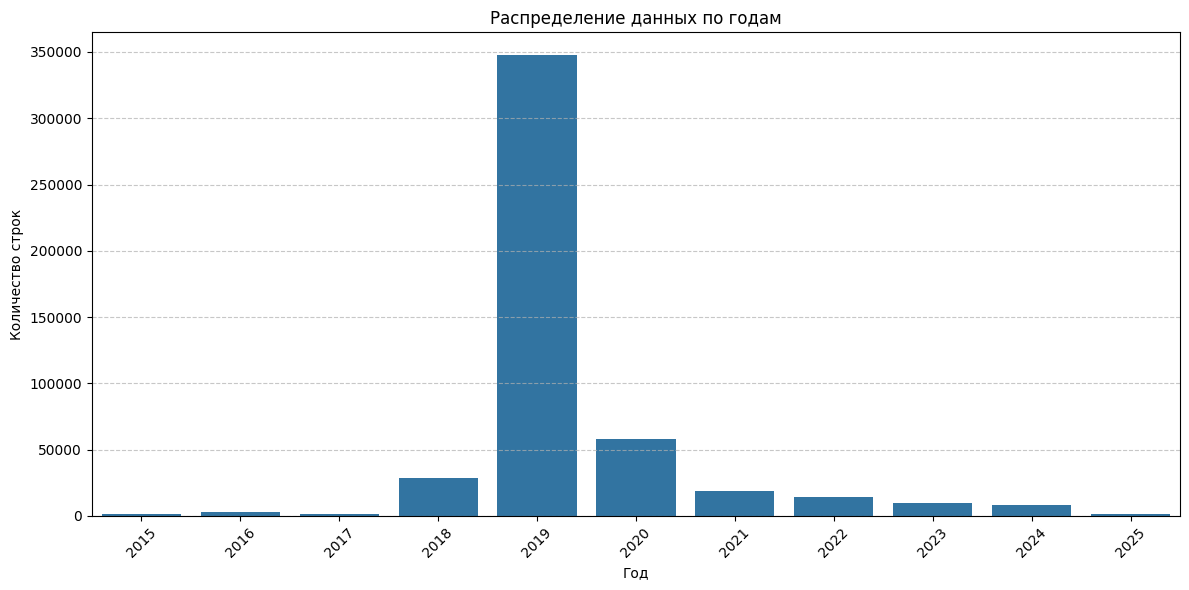

In [42]:
year_counts = df['year'].value_counts().sort_index()
print("Количество строк по годам:")
print(year_counts/df.shape[0]*100)


plt.figure(figsize=(12, 6))
sns.barplot(x=year_counts.index, y=year_counts.values)
plt.title('Распределение данных по годам')
plt.xlabel('Год')
plt.ylabel('Количество строк')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [37]:
df1 = df[df['year'].isin([2019, 2020, 2021, 2022, 2023])]
df2 = df[df['year'].isin([2024, 2025])]
group1 = set(df1['ИНН поставщика'].dropna().unique())
group2 = set(df2['ИНН поставщика'].dropna().unique())
common_inn = group1 & group2

common_inn_list = list(common_inn)
print(f"Количество общих ИНН: {len(common_inn_list)}")
print(df1.shape)
print(df2.shape)
print(f"Доля пересекающихся данных от общего объема тестовой выборки(при тесте от 2024): {round(len(common_inn_list)/df2.shape[0], 4)}")

Количество общих ИНН: 2532
(447969, 35)
(9311, 35)
Доля пересекающихся данных от общего объема тестовой выборки(при тесте от 2024): 0.2719


In [38]:
df1 = df[df['year'].isin([2019, 2020, 2021, 2022])]
df2 = df[df['year'].isin([2023, 2024, 2025])]
group1 = set(df1['ИНН поставщика'].dropna().unique())
group2 = set(df2['ИНН поставщика'].dropna().unique())
common_inn = group1 & group2

common_inn_list = list(common_inn)
print(f"Количество общих ИНН: {len(common_inn_list)}")
print(df1.shape)
print(df2.shape)
print(f"Доля пересекающихся данных от общего объема тестовой выборки(при тесте от 2023): {round(len(common_inn_list)/df2.shape[0], 4)}")

Количество общих ИНН: 4001
(438544, 35)
(18736, 35)
Доля пересекающихся данных от общего объема тестовой выборки(при тесте от 2023): 0.2135


In [43]:
train_data = df[df['year'].isin(range(2015, 2021))]
test_data = df[df['year'].isin(range(2021, 2026))]

In [44]:
print(train_data.shape)
print(test_data.shape)

(440066, 35)
(51991, 35)


Делим на тестовые тренировочные данные так, чтобы обучались модельки только по прошлым периодам

Генерим новые фичи по обучающей выборке

In [45]:
df['win_rate'] = train_data.groupby(['ИНН поставщика'])['Победитель'].transform(lambda x: (x == 1).sum() / len(x))

df['region_activity'] = train_data.groupby(['ИНН поставщика', 'Регион поставки'])['Победитель'].transform('count')
df['region_wins'] = train_data.groupby(['ИНН поставщика', 'Регион поставки'])['Победитель'].transform(lambda x: (x == 1).sum())
df['region_win_rate'] = df['region_wins'] / df['region_activity']

df['customer_activity'] = train_data.groupby(['ИНН поставщика', 'Заказчик'])['Победитель'].transform('count')
df['customer_wins'] = train_data.groupby(['ИНН поставщика', 'Заказчик'])['Победитель'].transform(lambda x: (x == 1).sum())
df['customer_win_rate'] = df['customer_wins'] / df['customer_activity']

df['sphere_activity'] = train_data.groupby(['ИНН поставщика', 'Сфера деятельности'])['Победитель'].transform('count')
df['sphere_wins'] = train_data.groupby(['ИНН поставщика', 'Сфера деятельности'])['Победитель'].transform(lambda x: (x == 1).sum())
df['sphere_win_rate'] = df['sphere_wins'] / df['sphere_activity']

df['total_activity'] = train_data.groupby('ИНН поставщика')['Победитель'].transform('count')
df['total_wins'] = train_data.groupby('ИНН поставщика')['Победитель'].transform(lambda x: (x == 1).sum())

df['avg_price_drop'] = train_data.groupby('ИНН поставщика')['Снижение на торгах,%'].transform('mean')

df["last_activity_date"] = train_data.groupby("ИНН поставщика")["Дата публикации"].transform("max")

In [46]:
df['competitors_per_tender'] = train_data.groupby('Реестровый номер публикации')['ИНН поставщика'].transform('nunique')
train_data['competitors_per_tender'] = train_data.groupby('Реестровый номер публикации')['ИНН поставщика'].transform('nunique')

df['avg_competitors_in_region'] = train_data.groupby('Регион поставки')['competitors_per_tender'].transform('mean')
df['avg_competitors_in_sphere'] = train_data.groupby('Сфера деятельности')['competitors_per_tender'].transform('mean')
df['avg_competitors_in_customer'] = train_data.groupby('Заказчик')['competitors_per_tender'].transform('mean')

df['customer_loyalty'] = train_data.groupby('Заказчик')['ИНН поставщика'].transform('nunique') 

/var/folders/7_/sz_ftshd1b1b9sppxlm9vj9m0000gn/T/ipykernel_72457/3831653720.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_data['competitors_per_tender'] = train_data.groupby('Реестровый номер публикации')['ИНН поставщика'].transform('nunique')


In [47]:
df = df.drop(columns=['РНП сейчас', 'participants_count']) #в РНП сейчас нет значений
data = df.copy()

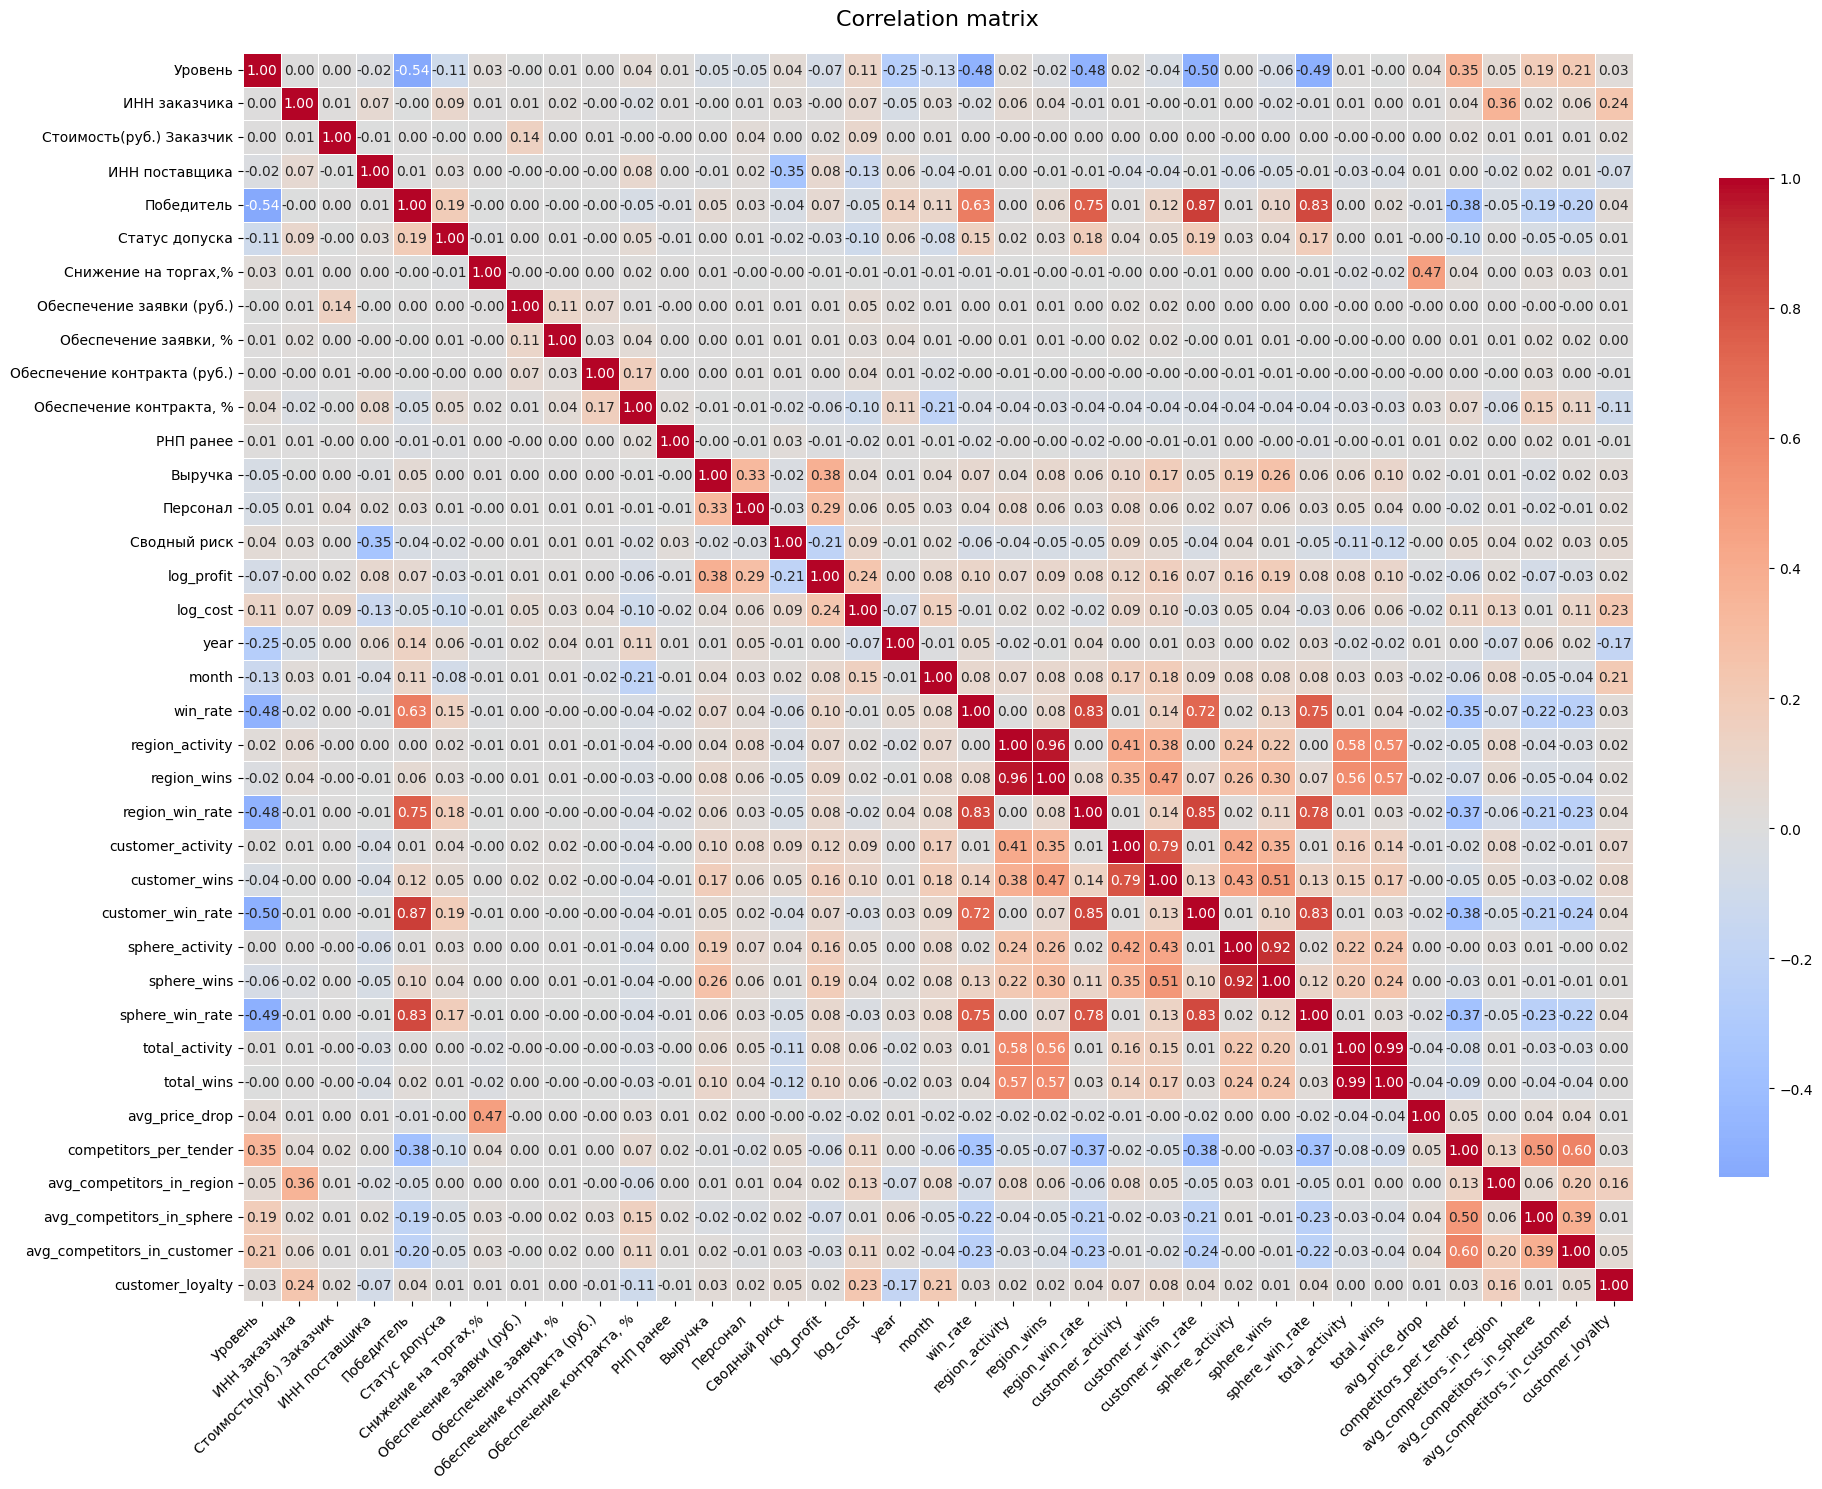

In [48]:
numeric_cols = data.select_dtypes(include=['number']).columns
corr_matrix = data[numeric_cols].corr()

plt.figure(figsize=(20, 15))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap='coolwarm',
    center=0,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8}
)
plt.title("Correlation matrix", pad=20, fontsize=16)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [49]:
target_corr = corr_matrix['Победитель'].sort_values(key=abs, ascending=False)
print("\nTop 20 correlations with target variable:")
print(target_corr.head(20))


Top 20 correlations with target variable:
Победитель                     1.00
customer_win_rate              0.87
sphere_win_rate                0.83
region_win_rate                0.75
win_rate                       0.63
Уровень                       -0.54
competitors_per_tender        -0.38
avg_competitors_in_customer   -0.20
avg_competitors_in_sphere     -0.19
Статус допуска                 0.19
year                           0.14
customer_wins                  0.12
month                          0.11
sphere_wins                    0.10
log_profit                     0.07
region_wins                    0.06
log_cost                      -0.05
Выручка                        0.05
Обеспечение контракта, %      -0.05
avg_competitors_in_region     -0.05
Name: Победитель, dtype: float64


В целом, что и логично, корреляция между соответствующими признаками activity и win_rate достаточно высокая, поэтому можем удалить признаки activity

Высоко коррелируют еще глобальный win_rate с win_rate по региону, по сфере деятельности и по заказчику, но пока удалять их не будем - для второго шага обучения они могут быть полезны

In [50]:
data = data.drop(columns=['region_activity', 'customer_activity', 'sphere_activity', 'total_activity'])

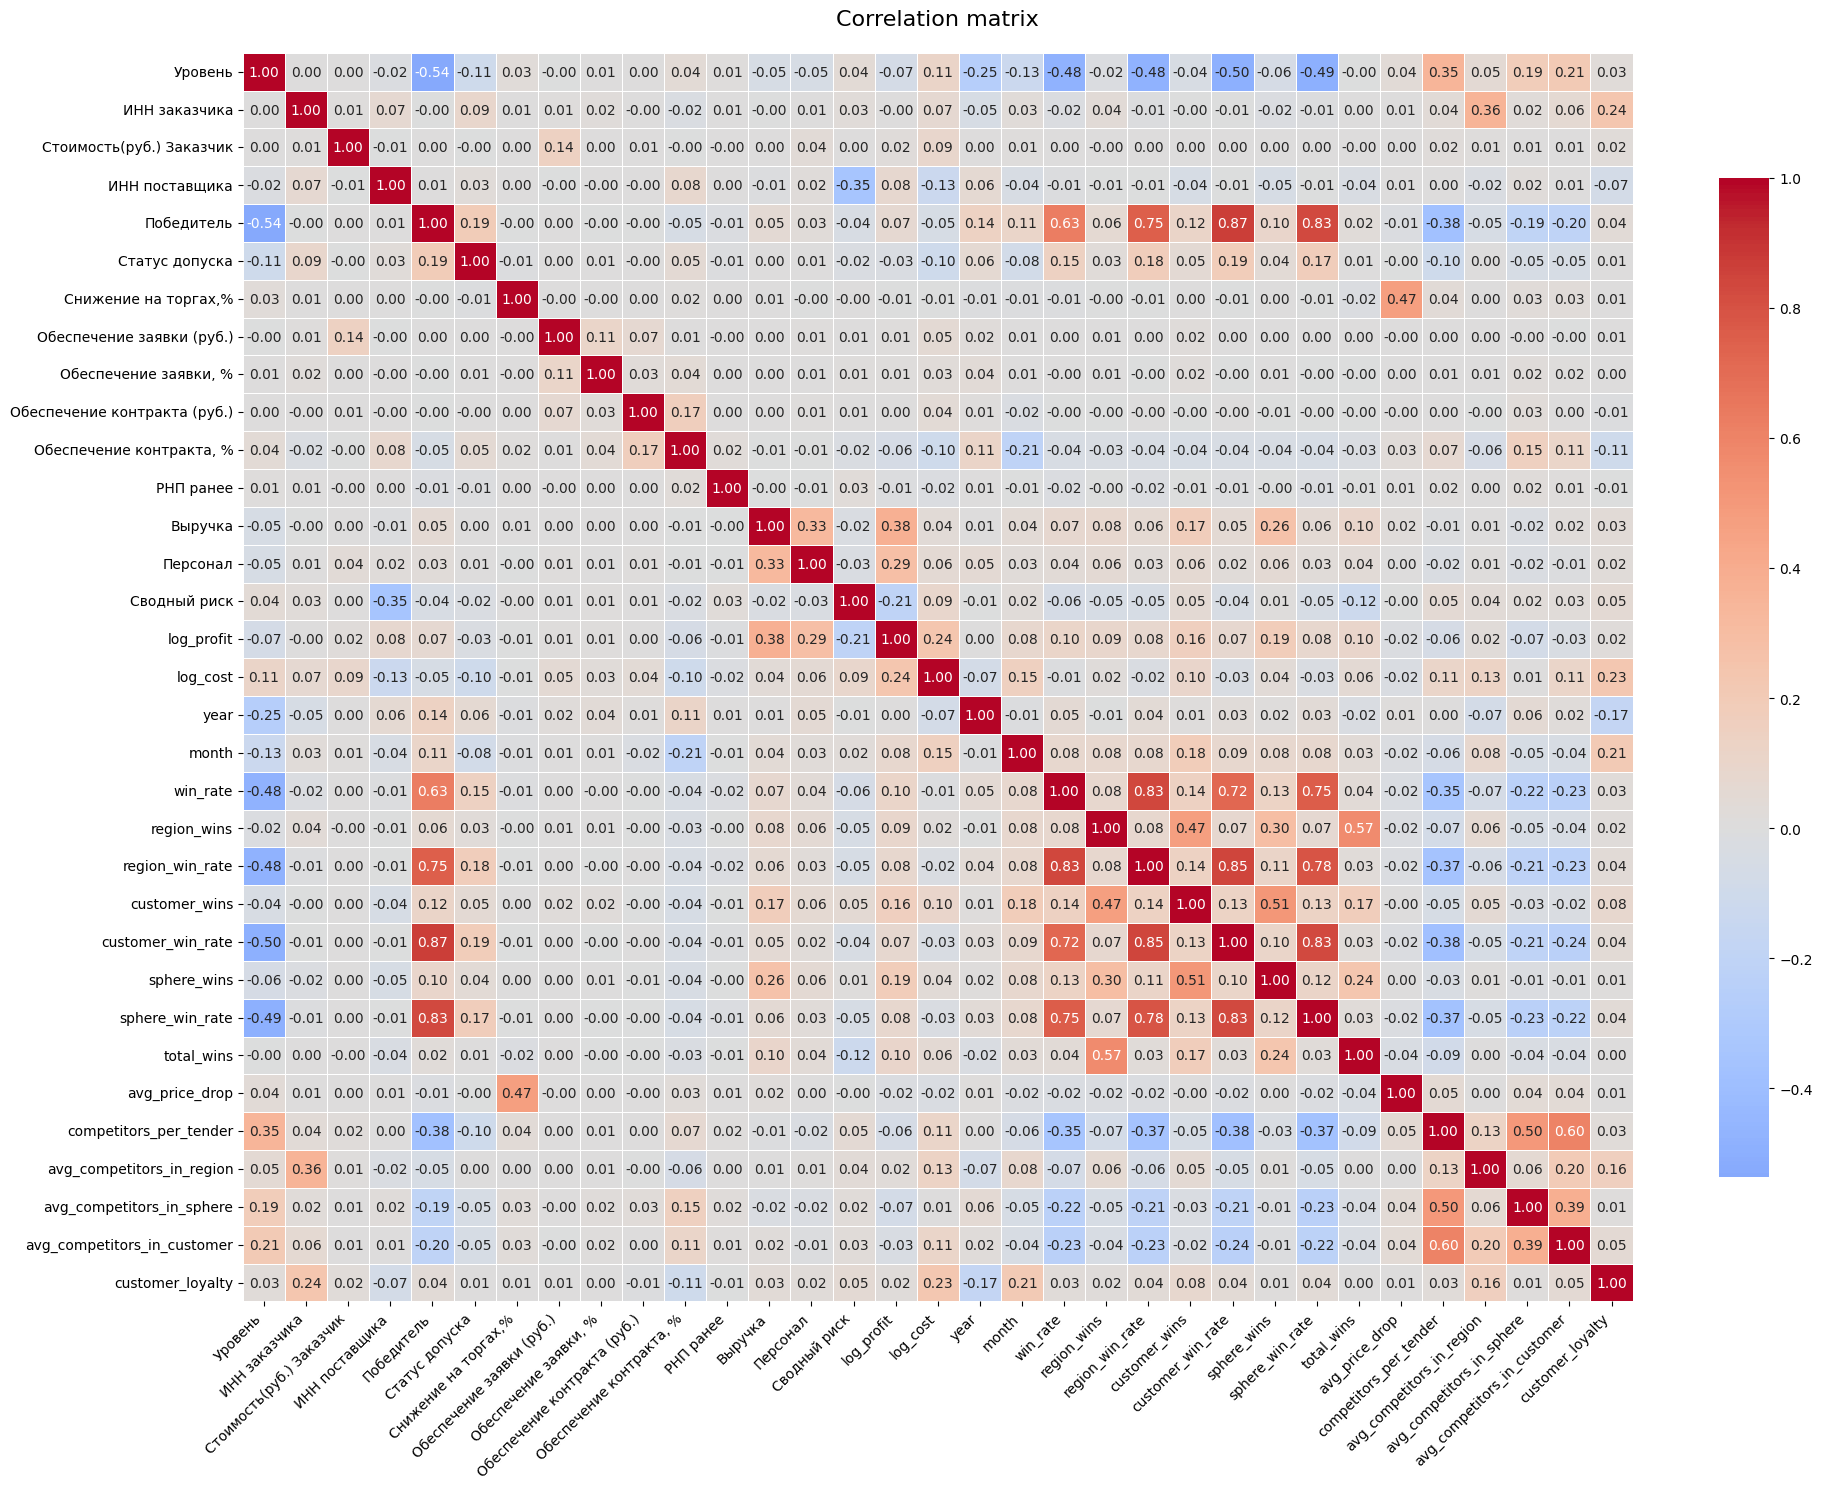

In [51]:
numeric_cols = data.select_dtypes(include=['number']).columns
corr_matrix = data[numeric_cols].corr()


plt.figure(figsize=(20, 15))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap='coolwarm',
    center=0,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8}
)
plt.title("Correlation matrix", pad=20, fontsize=16)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Проверим стат значимость признаков

In [52]:
from scipy import stats

won_data = data[data['Победитель'] == 1] 
lost_data = data[data['Победитель'] == 0]


numeric_features = data.select_dtypes(include=['float64', 'int64']).columns.tolist()
numeric_features = [col for col in numeric_features if 'Победитель' not in col]

print("Statistical significance tests:\n")
print("T-test results:")

for feature in numeric_features:
    #t-test
    statistic, p_value = stats.ttest_ind(
        won_data[feature].dropna(),
        lost_data[feature].dropna(),
        equal_var=False 
    )
    
    print(f"\n{feature}")
    print(f"t-statistic: {statistic:.4f}")
    print(f"p-value: {p_value:.10f}")
    print(f"Statistically significant: {p_value < 0.05}")

Statistical significance tests:

T-test results:

Уровень
t-statistic: -428.0170
p-value: 0.0000000000
Statistically significant: True

ИНН заказчика
t-statistic: -1.2945
p-value: 0.1954900830
Statistically significant: False

Стоимость(руб.) Заказчик
t-statistic: 1.5943
p-value: 0.1108592089
Statistically significant: False

ИНН поставщика
t-statistic: 3.7093
p-value: 0.0002078750
Statistically significant: True

Статус допуска
t-statistic: 141.6760
p-value: 0.0000000000
Statistically significant: True

Снижение на торгах,%
t-statistic: -3.5544
p-value: 0.0003788524
Statistically significant: True

Обеспечение заявки (руб.)
t-statistic: 2.8952
p-value: 0.0037896221
Statistically significant: True

Обеспечение заявки, %
t-statistic: -1.9214
p-value: 0.0546783762
Statistically significant: False

Обеспечение контракта (руб.)
t-statistic: -1.8076
p-value: 0.0706697542
Statistically significant: False

Обеспечение контракта, %
t-statistic: -32.3957
p-value: 0.0000000000
Statistically sign

In [53]:
categorical_features = data.select_dtypes(include=['object']).columns.tolist()
categorical_features = [col for col in categorical_features 
                      if 'Победитель' not in col 
                      and 'Дата' not in col]

print("\n\nChi-square test results:")

for feature in categorical_features:
    contingency = pd.crosstab(data[feature], data['Победитель'])
    chi2, p_value, dof, expected = stats.chi2_contingency(contingency)
    
    print(f"\n{feature}")
    print(f"chi2 statistic: {chi2:.4f}")
    print(f"p-value: {p_value:.10f}")
    print(f"Statistically significant: {p_value < 0.05}")



Chi-square test results:

Заказчик
chi2 statistic: 79230.7142
p-value: 0.0000000000
Statistically significant: True

Реестровый номер публикации
chi2 statistic: 205262.7090
p-value: 1.0000000000
Statistically significant: False

Сфера деятельности
chi2 statistic: 45837.8229
p-value: 0.0000000000
Statistically significant: True

Регион поставки
chi2 statistic: 5409.1221
p-value: 0.0000000000
Statistically significant: True

Город поставки
chi2 statistic: 14843.4670
p-value: 0.0000000000
Statistically significant: True

Поставщик
chi2 statistic: 177586.4611
p-value: 0.0000000000
Statistically significant: True

Форма публикации
chi2 statistic: 0.0000
p-value: 1.0000000000
Statistically significant: False

Тип торгов
chi2 statistic: 141231.6080
p-value: 0.0000000000
Statistically significant: True

Адрес
chi2 statistic: 153831.8743
p-value: 0.0000000000
Statistically significant: True

Отрасль
chi2 statistic: 21208.7138
p-value: 0.0000000000
Statistically significant: True


Все числовые статистически значимые, а в категориальных незначимым оказался только признак Форма публикации, его использовать не будем

In [54]:
data.isna().sum()

Уровень                                                                                                                     0
Заказчик                                                                                                                    0
ИНН заказчика                                                                                                               0
Стоимость(руб.) Заказчик                                                                                                    0
Реестровый номер публикации                                                                                                 0
Сфера деятельности                                                                                                          0
Регион поставки                                                                                                             0
Город поставки                                                                                                        

In [55]:
data = data.drop(columns=['Адрес', 'Персонал', 'Отрасль'])

In [56]:
data['win_rate'].describe()

count   440,066.00
mean          0.45
std           0.31
min           0.00
25%           0.22
50%           0.42
75%           0.67
max           1.00
Name: win_rate, dtype: float64

Пока заменю пропуски (новые фичи, которые попали в тест и имеют пропуски) - по ближайшим соседям

В отличие от заполнения медианой (когда все пропуски в столбце заполняются одним и тем же числом – медианой этого столбца), KNNImputer учитывает значения других признаков для конкретной строки. Если две строки похожи по 10 признакам, вероятно, их значения 11-го признака (даже если он пропущен у одной из них) тоже будут близки (он меряе т расстояние между строками через nan_euclidean_distances)

***Протестим точность заполнения, сравнив с реально посчитанными по тесту значениями***

In [58]:
check_df = data.copy()

check_df['win_rate'] = check_df.groupby(['ИНН поставщика'])['Победитель'].transform(lambda x: (x == 1).sum() / len(x))

check_df['region_activity'] = check_df.groupby(['ИНН поставщика', 'Регион поставки'])['Победитель'].transform('count')
check_df['region_wins'] = check_df.groupby(['ИНН поставщика', 'Регион поставки'])['Победитель'].transform(lambda x: (x == 1).sum())
check_df['region_win_rate'] = check_df['region_wins'] / check_df['region_activity']

check_df['customer_activity'] = check_df.groupby(['ИНН поставщика', 'Заказчик'])['Победитель'].transform('count')
check_df['customer_wins'] = check_df.groupby(['ИНН поставщика', 'Заказчик'])['Победитель'].transform(lambda x: (x == 1).sum())
check_df['customer_win_rate'] = check_df['customer_wins'] / check_df['customer_activity']

check_df['sphere_activity'] = check_df.groupby(['ИНН поставщика', 'Сфера деятельности'])['Победитель'].transform('count')
check_df['sphere_wins'] = check_df.groupby(['ИНН поставщика', 'Сфера деятельности'])['Победитель'].transform(lambda x: (x == 1).sum())
check_df['sphere_win_rate'] = check_df['sphere_wins'] / check_df['sphere_activity']

check_df['total_activity'] = check_df.groupby('ИНН поставщика')['Победитель'].transform('count')
check_df['total_wins'] = check_df.groupby('ИНН поставщика')['Победитель'].transform(lambda x: (x == 1).sum())

check_df['avg_price_drop'] = check_df.groupby('ИНН поставщика')['Снижение на торгах,%'].transform('mean')

check_df['competitors_per_tender'] = check_df.groupby('Реестровый номер публикации')['ИНН поставщика'].transform('nunique')
check_df['competitors_per_tender'] = check_df.groupby('Реестровый номер публикации')['ИНН поставщика'].transform('nunique')

check_df['avg_competitors_in_region'] = check_df.groupby('Регион поставки')['competitors_per_tender'].transform('mean')
check_df['avg_competitors_in_sphere'] = check_df.groupby('Сфера деятельности')['competitors_per_tender'].transform('mean')
check_df['avg_competitors_in_customer'] = check_df.groupby('Заказчик')['competitors_per_tender'].transform('mean')

check_df['customer_loyalty'] = check_df.groupby('Заказчик')['ИНН поставщика'].transform('nunique') 

In [57]:
test_data_with_nans = data.copy()

In [68]:
from sklearn.impute import KNNImputer

columns_to_impute = [
    'win_rate', 'region_wins', 'region_win_rate',
    'customer_wins', 'customer_win_rate', 'sphere_wins',
    'sphere_win_rate', 'total_wins', 'avg_price_drop',
    'competitors_per_tender', 'avg_competitors_in_region', 'avg_competitors_in_sphere',
    'avg_competitors_in_customer', 'customer_loyalty'
]

imputer = KNNImputer(n_neighbors=11) 
data[columns_to_impute] = imputer.fit_transform(data[columns_to_impute])

In [69]:
from sklearn.metrics import mean_squared_error

check_df_aligned = check_df[columns_to_impute]
nan_mask = test_data_with_nans[columns_to_impute].isna()
original_nan_indices = np.where(nan_mask.values) 
imputed_values = data[columns_to_impute].values[original_nan_indices]
true_values = check_df_aligned.values[original_nan_indices]

if len(true_values) > 0 and len(imputed_values) > 0:
    mse = mean_squared_error(true_values, imputed_values)
    print(f"Overall MSE for imputed values (n_neighbors=11): {mse:.4f}")

    print("\nMSE per column:")
    for col in columns_to_impute:
        col_mask = nan_mask[col]
        if col_mask.any(): 
            imputed_col_vals = data.loc[col_mask, col]
            true_col_vals = check_df_aligned.loc[col_mask, col]
            col_mse = mean_squared_error(true_col_vals, imputed_col_vals)
            print(f"- {col}: {col_mse:.4f}")
        else:
            print(f"- {col}: No NaNs originally")
else:
    print("No NaN values found in the specified columns to evaluate")

Overall MSE for imputed values (n_neighbors=11): 12346.7629

MSE per column:
- win_rate: 0.1524
- region_wins: 24335.8984
- region_win_rate: 0.1641
- customer_wins: 26605.1589
- customer_win_rate: 0.1696
- sphere_wins: 26118.9817
- sphere_win_rate: 0.1835
- total_wins: 26699.7577
- avg_price_drop: 0.7139
- competitors_per_tender: 43.2670
- avg_competitors_in_region: 18.9805
- avg_competitors_in_sphere: 39.3727
- avg_competitors_in_customer: 40.7577
- customer_loyalty: 68951.1228


Проверим ошибку при заполнении медианами

In [60]:
def hierarchical_median_impute(df, columns_to_fill, group_hierarchy):
    for col in columns_to_fill:
        is_null = df[col].isnull()
        for groups in group_hierarchy:
            if len(groups) == 0:
                global_median = df[col].median()
                df.loc[is_null, col] = global_median
                break
            medians = df.groupby(groups)[col].transform('median')
            df.loc[is_null, col] = df.loc[is_null, col].fillna(medians)
            is_null = df[col].isnull()
            if not is_null.any():
                break
    return df


group_hierarchy = [['Сфера деятельности', 'Регион поставки'],['Сфера деятельности'],['Регион поставки'],[]]

In [71]:
imputed_with_medians = test_data_with_nans.copy()
imputed_with_medians = hierarchical_median_impute(imputed_with_medians, columns_to_impute, group_hierarchy)
imputed_values_medians = imputed_with_medians[columns_to_impute].values[original_nan_indices]
mse = mean_squared_error(true_values, imputed_values_medians)
print(f"Overall MSE for imputed values (medians): {mse:.4f}")

print("\nMSE per column:")
for col in columns_to_impute:
    col_mask = nan_mask[col]
    if col_mask.any(): 
        imputed_col_vals = imputed_with_medians.loc[col_mask, col]
        true_col_vals = check_df_aligned.loc[col_mask, col]
        col_mse = mean_squared_error(true_col_vals, imputed_col_vals)
        print(f"- {col}: {col_mse:.4f}")
    else:
        print(f"- {col}: No NaNs originally.")

Overall MSE for imputed values (medians): 3993.4100

MSE per column:
- win_rate: 0.1188
- region_wins: 4815.3040
- region_win_rate: 0.1380
- customer_wins: 5710.3799
- customer_win_rate: 0.1468
- sphere_wins: 5487.2434
- sphere_win_rate: 0.1646
- total_wins: 6105.1016
- avg_price_drop: 0.7850
- competitors_per_tender: 4.8437
- avg_competitors_in_region: 3.4699
- avg_competitors_in_sphere: 1.0773
- avg_competitors_in_customer: 1.9930
- customer_loyalty: 33776.9740


In [63]:
from sklearn.impute import KNNImputer
columns_all = ['win_rate', 'region_wins', 'region_win_rate',
    'customer_wins', 'customer_win_rate', 'sphere_wins',
    'sphere_win_rate', 'total_wins', 'avg_price_drop',
     'competitors_per_tender',
    'avg_competitors_in_region', 'avg_competitors_in_sphere',
    'avg_competitors_in_customer']

smart_fill = test_data_with_nans.copy()
smart_fill = smart_fill.drop(columns=['customer_loyalty'])
check_df_aligned = check_df[columns_all]
nan_mask = smart_fill[columns_all].isna()
original_nan_indices = np.where(nan_mask.values) 
imputed_values = data[columns_all].values[original_nan_indices]
true_values = check_df_aligned.values[original_nan_indices]

smart_fill = hierarchical_median_impute(smart_fill, ['region_wins',
    'customer_wins', 'sphere_wins', 'total_wins', 'competitors_per_tender',
    'avg_competitors_in_region', 'avg_competitors_in_sphere',
    'avg_competitors_in_customer'], group_hierarchy)

columns_left = ['win_rate', 'region_win_rate',
    'customer_win_rate', 'sphere_win_rate', 'avg_price_drop']

imputer = KNNImputer(n_neighbors=25)
smart_fill[columns_left] = imputer.fit_transform(smart_fill[columns_left])
mse = mean_squared_error(true_values, smart_fill[columns_all].values[original_nan_indices])
print(f"Overall MSE for imputed values (medians+knn): {mse:.4f}")

print("\nMSE per column:")
for col in columns_all:
    col_mask = nan_mask[col]
    if col_mask.any(): 
        imputed_col_vals = smart_fill.loc[col_mask, col]
        true_col_vals = check_df_aligned.loc[col_mask, col]
        col_mse = mean_squared_error(true_col_vals, imputed_col_vals)
        print(f"- {col}: {col_mse:.4f}")
    else:
        print(f"- {col}: No NaNs originally")


KeyboardInterrupt: 

Таким образом, наименьшая ошибка достигается при сочетании использования медиан (для признаков количества) и заполнения через KNN (для процентных признаков)

In [64]:
data = test_data_with_nans.copy()

In [65]:
data = hierarchical_median_impute(data, ['region_wins',
    'customer_wins', 'sphere_wins', 'total_wins', 'competitors_per_tender',
    'avg_competitors_in_region', 'avg_competitors_in_sphere',
    'avg_competitors_in_customer'], group_hierarchy)

imputer = KNNImputer(n_neighbors=11)
data[columns_left] = imputer.fit_transform(data[columns_left])

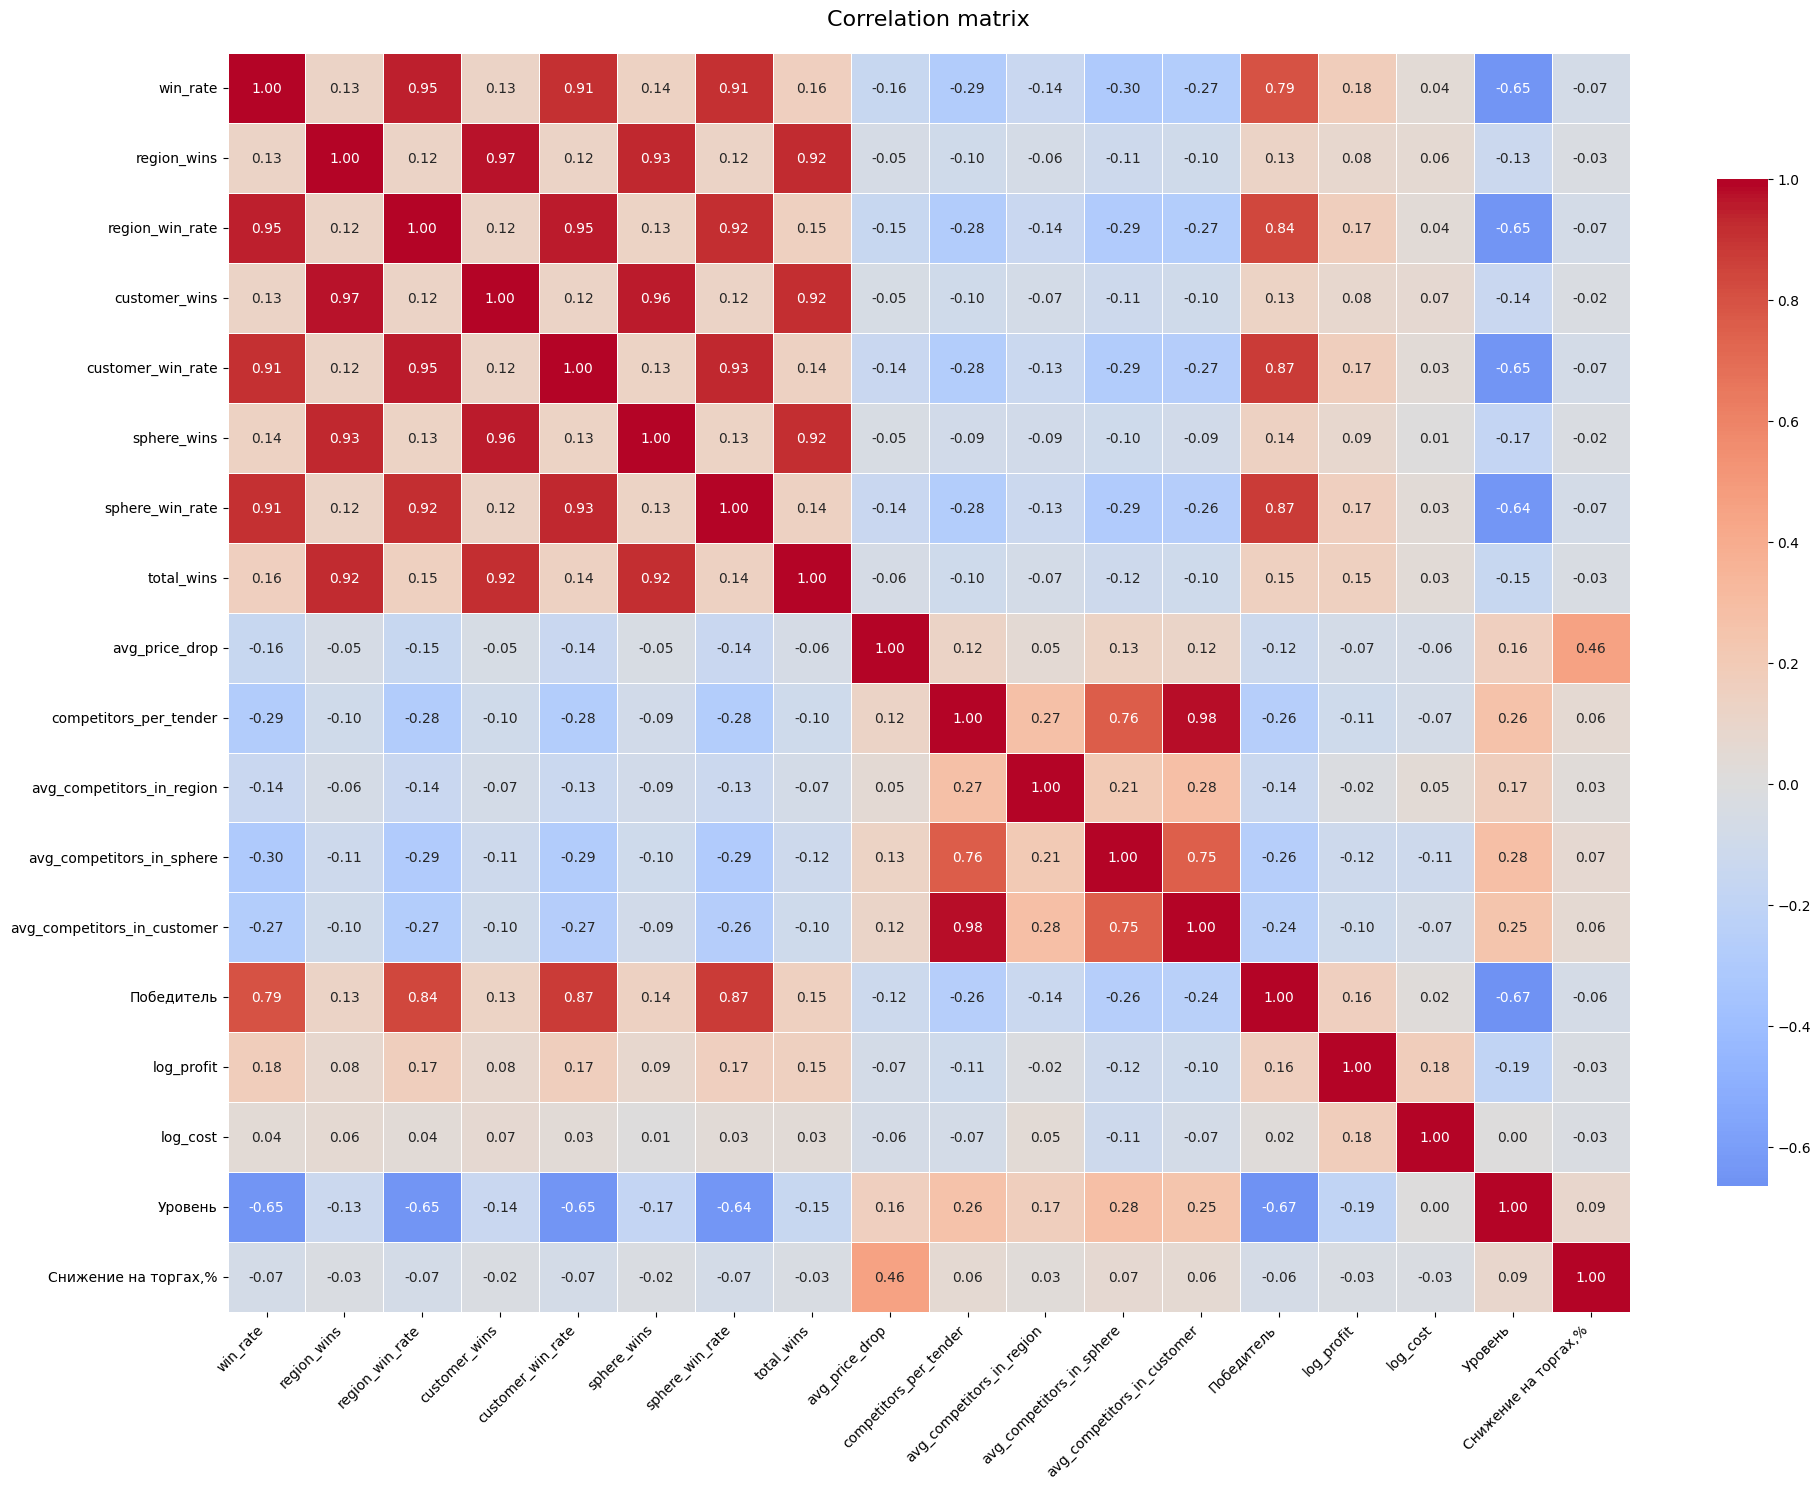

In [75]:
numeric_cols = ['win_rate', 'region_wins', 'region_win_rate',
    'customer_wins', 'customer_win_rate', 'sphere_wins',
    'sphere_win_rate', 'total_wins', 'avg_price_drop',
     'competitors_per_tender',
    'avg_competitors_in_region', 'avg_competitors_in_sphere',
    'avg_competitors_in_customer', 'Победитель', 'log_profit', 'log_cost', 'Уровень', 'Снижение на торгах,%']
corr_matrix = data[numeric_cols].corr()


plt.figure(figsize=(20, 15))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap='coolwarm',
    center=0,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8}
)
plt.title("Correlation matrix", pad=20, fontsize=16)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [66]:
data.isna().sum()

Уровень                                                                                                                    0
Заказчик                                                                                                                   0
ИНН заказчика                                                                                                              0
Стоимость(руб.) Заказчик                                                                                                   0
Реестровый номер публикации                                                                                                0
Сфера деятельности                                                                                                         0
Регион поставки                                                                                                            0
Город поставки                                                                                                             0


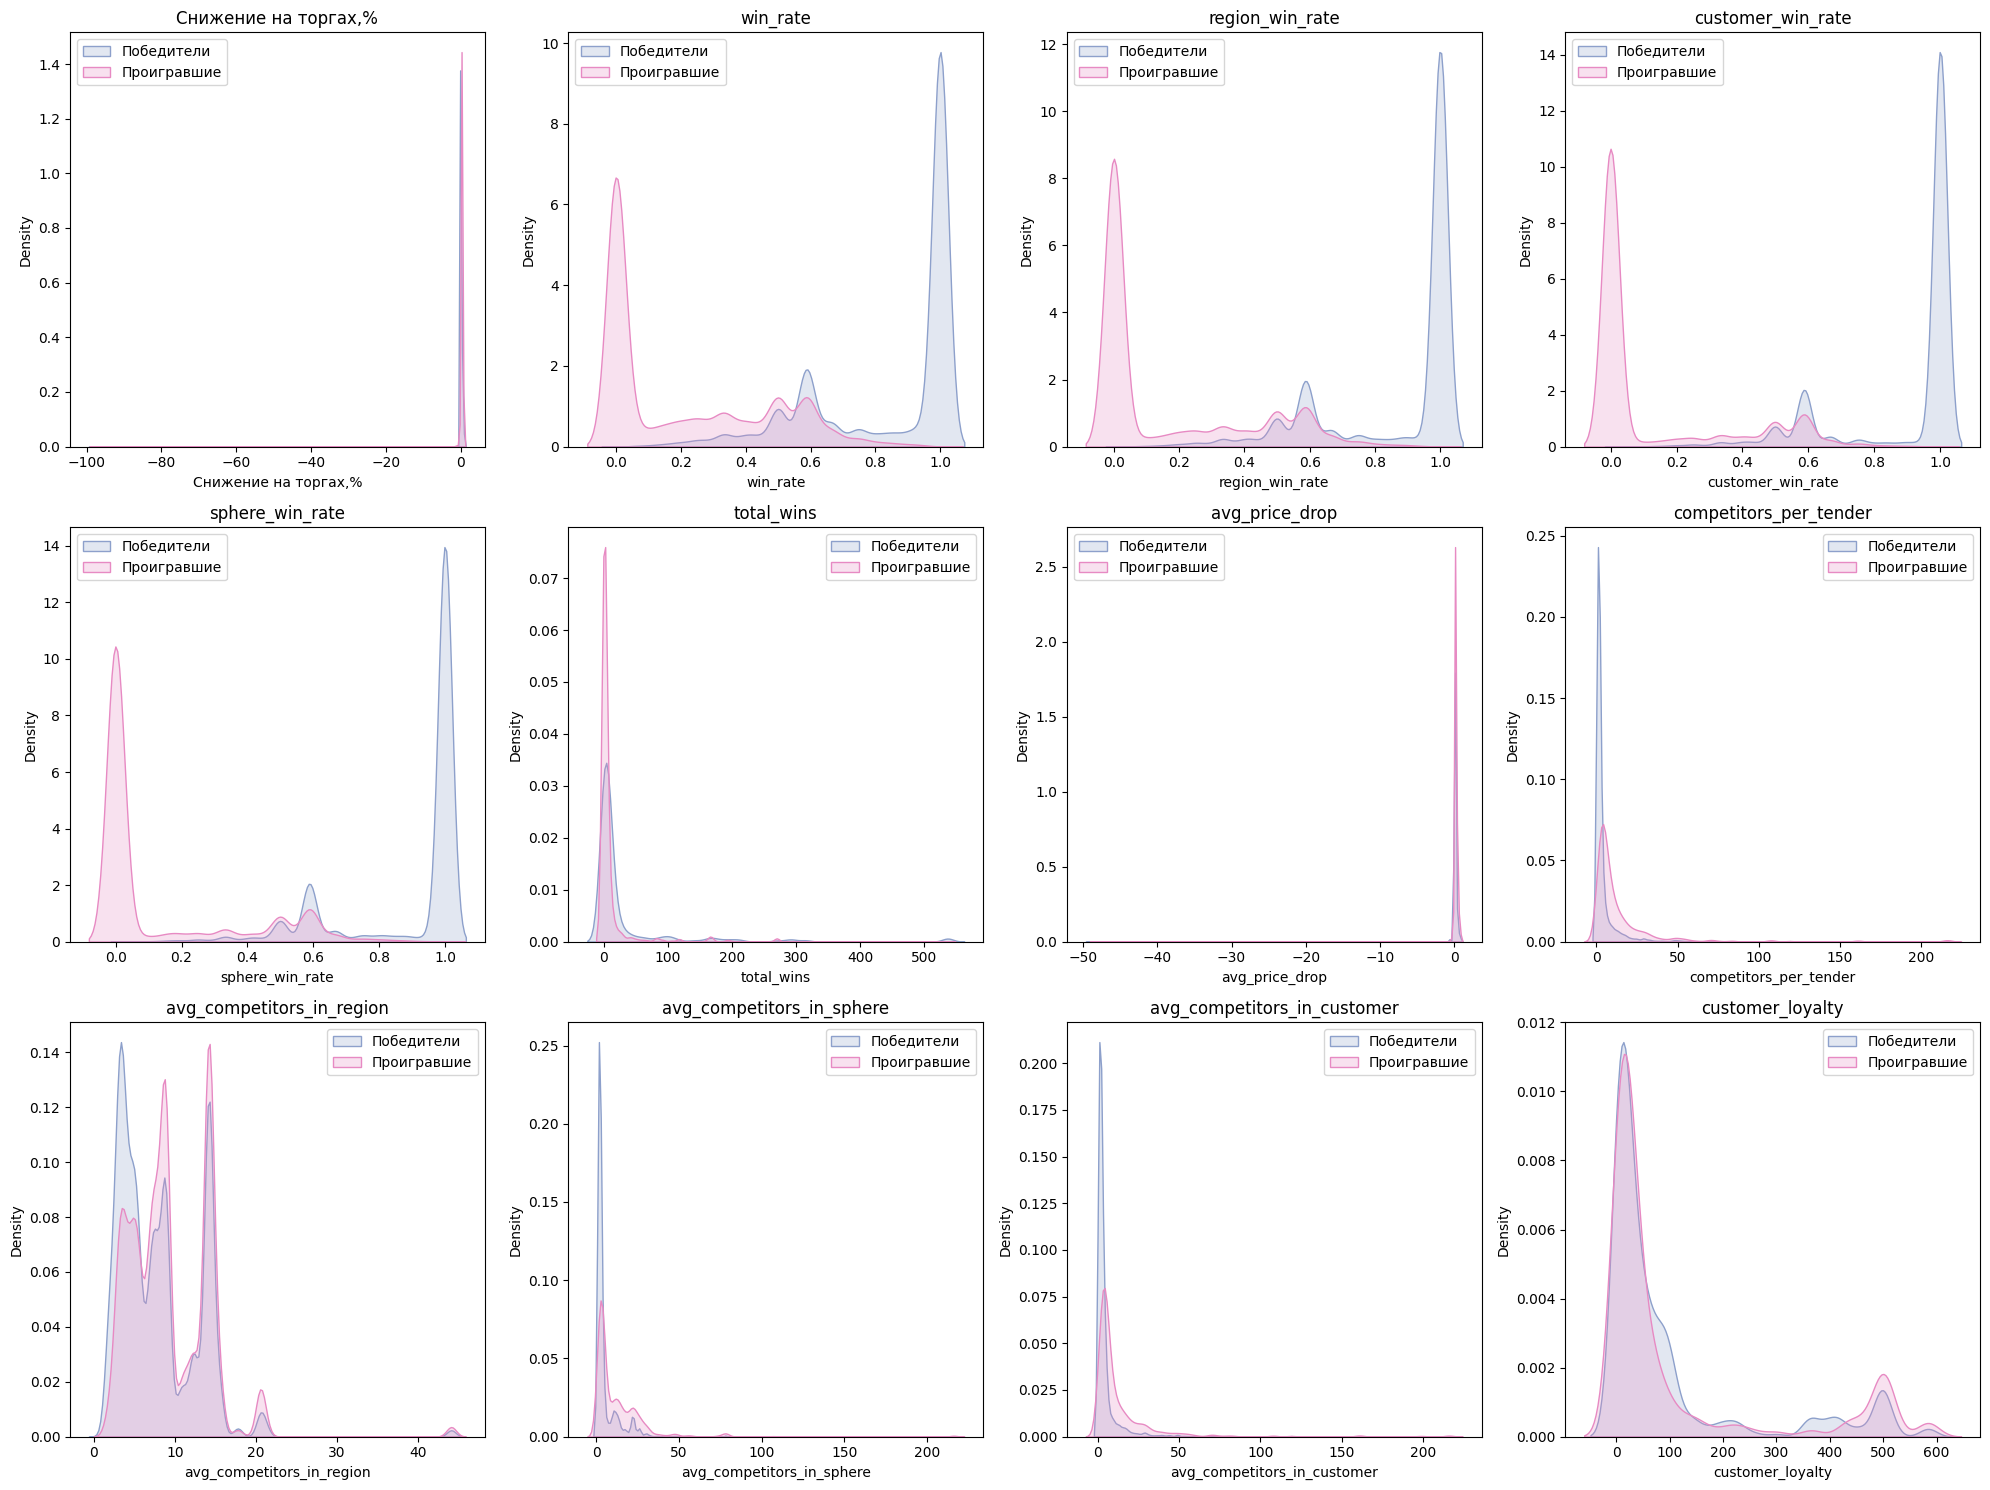

In [77]:
#numeric_features = data.select_dtypes(include=['float64', 'int64']).columns
numeric_features = ['Снижение на торгах,%', 'win_rate', 'region_win_rate', 'customer_win_rate', 'sphere_win_rate', 'total_wins', 'avg_price_drop', 'competitors_per_tender', 'avg_competitors_in_region', 'avg_competitors_in_sphere', 'avg_competitors_in_customer', 'customer_loyalty']
numeric_features = [col for col in numeric_features if col != 'Победитель']

n_features = len(numeric_features)
n_cols = 4
n_rows = (n_features + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 5*n_rows))
axes_flat = axes.flatten()

for idx, feature in enumerate(numeric_features):
    sns.kdeplot(data=data[data['Победитель']==1][feature], 
                ax=axes_flat[idx], 
                label='Победители',
                fill=True, color=sns.color_palette("Set2")[2])
    sns.kdeplot(data=data[data['Победитель']==0][feature], 
                ax=axes_flat[idx], 
                label='Проигравшие',
                fill=True, color=sns.color_palette("Set2")[3])
    axes_flat[idx].set_title(feature)
    axes_flat[idx].legend()

for idx in range(len(numeric_features), len(axes_flat)):
    fig.delaxes(axes_flat[idx])

plt.tight_layout()
plt.show()

Customer loyalty совсем не зависит от победы, поэтому удалим его, по всем остальным вроде все адекватно

In [67]:
data = data.drop(columns=['customer_loyalty'])

In [74]:
data

,Уровень,Заказчик,ИНН заказчика,Стоимость(руб.) Заказчик,Реестровый номер публикации,Сфера деятельности,Регион поставки,Город поставки,Дата публикации,Дата окончания приема заявок / Дата планового окончания исполнения контракта / Плановая дата публикации лота по ППГ,...,customer_win_rate,sphere_wins,sphere_win_rate,total_wins,avg_price_drop,last_activity_date,competitors_per_tender,avg_competitors_in_region,avg_competitors_in_sphere,avg_competitors_in_customer
0,1,"АНО ""ДФИКММ ЧО""",7451432207,"14,641,255.12",0321718002DP,"[ОКПД2 27.20] Батареи и аккумуляторы, [ОКВЭД2 ...",Челябинская область,Челябинск,2018-12-14 12:35:50,2018-12-19 13:00:00,...,1.00,1.00,1.00,1.00,0.04,2019-03-29 10:37:44,1.00,3.80,4.41,1.67
1,2,"АНО ""ДФИКММ ЧО""",7451432207,"4,474,289.40",0321718003DP,[ОКПД2 28.25] Оборудование промышленное холоди...,Челябинская область,Челябинск,2018-12-14 12:39:28,2018-12-19 13:00:00,...,0.00,0.00,0.00,0.00,0.17,2018-12-14 12:39:28,2.00,3.80,4.40,1.67
2,2,"АНО ""ДФИКММ ЧО""",7451432207,"14,949,291.57",0321718003DP,[ОКПД2 28.25] Оборудование промышленное холоди...,Челябинская область,Челябинск,2018-12-14 12:39:28,2018-12-19 13:00:00,...,1.00,1.00,1.00,4.00,0.05,2019-01-23 14:51:37,2.00,3.80,4.40,1.67
3,2,"ООО ""ЗНСМ""",7710305634,"6,903,712.61",1000111,[ОКПД2 41.20] Здания и работы по возведению зд...,Архангельская область,Архангельская область,2018-04-06 12:16:40,2018-04-23 12:00:00,...,0.50,1.00,1.00,6.00,0.03,2020-05-29 11:40:12,2.00,3.77,2.87,3.58
4,2,"ООО ""ЗНСМ""",7710305634,"31,225,101.29",1000111,[ОКПД2 41.20] Здания и работы по возведению зд...,Архангельская область,Архангельская область,2018-04-06 12:16:40,2018-04-23 12:00:00,...,0.30,0.00,0.00,5.00,-0.24,2019-08-06 00:00:00,2.00,3.77,2.87,3.58
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
492073,2,"АО ""МОСВОДОКАНАЛ""",7701984274,"4,812,947.59",32009305437,[ОКПД2 71.12] Услуги в области инженерно-техни...,Москва,Москва,2020-07-09 09:01:44,2020-07-29 10:30:00,...,0.00,0.00,0.00,1.00,0.03,2020-07-09 09:01:44,2.00,4.27,3.69,2.80
492074,2,МАОУ СОШ № 38,3906045856,"768,572.00",32110152379,[ОКПД2 46.90] Услуги по неспециализированной о...,Калининградская область,Калининградская область,2021-04-01 18:18:20,2021-04-02 12:00:00,...,0.45,1.00,0.45,4.00,0.13,NaT,2.00,3.79,2.94,2.91
492075,2,"АО ""ОЗК""",7708632345,"730,785,000.00",32211237428,[ОКПД2 52.10] Услуги по складированию и хранен...,Москва,Москва,2022-03-18 18:20:39,2022-04-18 10:00:00,...,0.45,1.00,0.45,4.00,0.13,NaT,1.00,4.27,1.50,2.18
492076,2,"МУП АГО ""АНГАРСКИЙ ВОДОКАНАЛ""",3801006828,"9,015,408.00",32211471613,"[ОКПД2 80.10] Услуги охранных служб, в том чис...",Иркутская область,Иркутская область,2022-06-15 16:51:50,2022-06-24 10:00:00,...,0.45,1.00,0.45,2.00,0.13,NaT,2.00,4.02,3.10,3.40


Разберемся с временными признаками

In [85]:
data['Дата окончания проведения торгов'] = pd.to_datetime(data['Дата окончания проведения торгов'], errors='coerce')

/var/folders/7_/sz_ftshd1b1b9sppxlm9vj9m0000gn/T/ipykernel_72457/3829976560.py:30: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  g3.set_xticklabels(['Пн','Вт','Ср','Чт','Пт','Сб','Вс'])


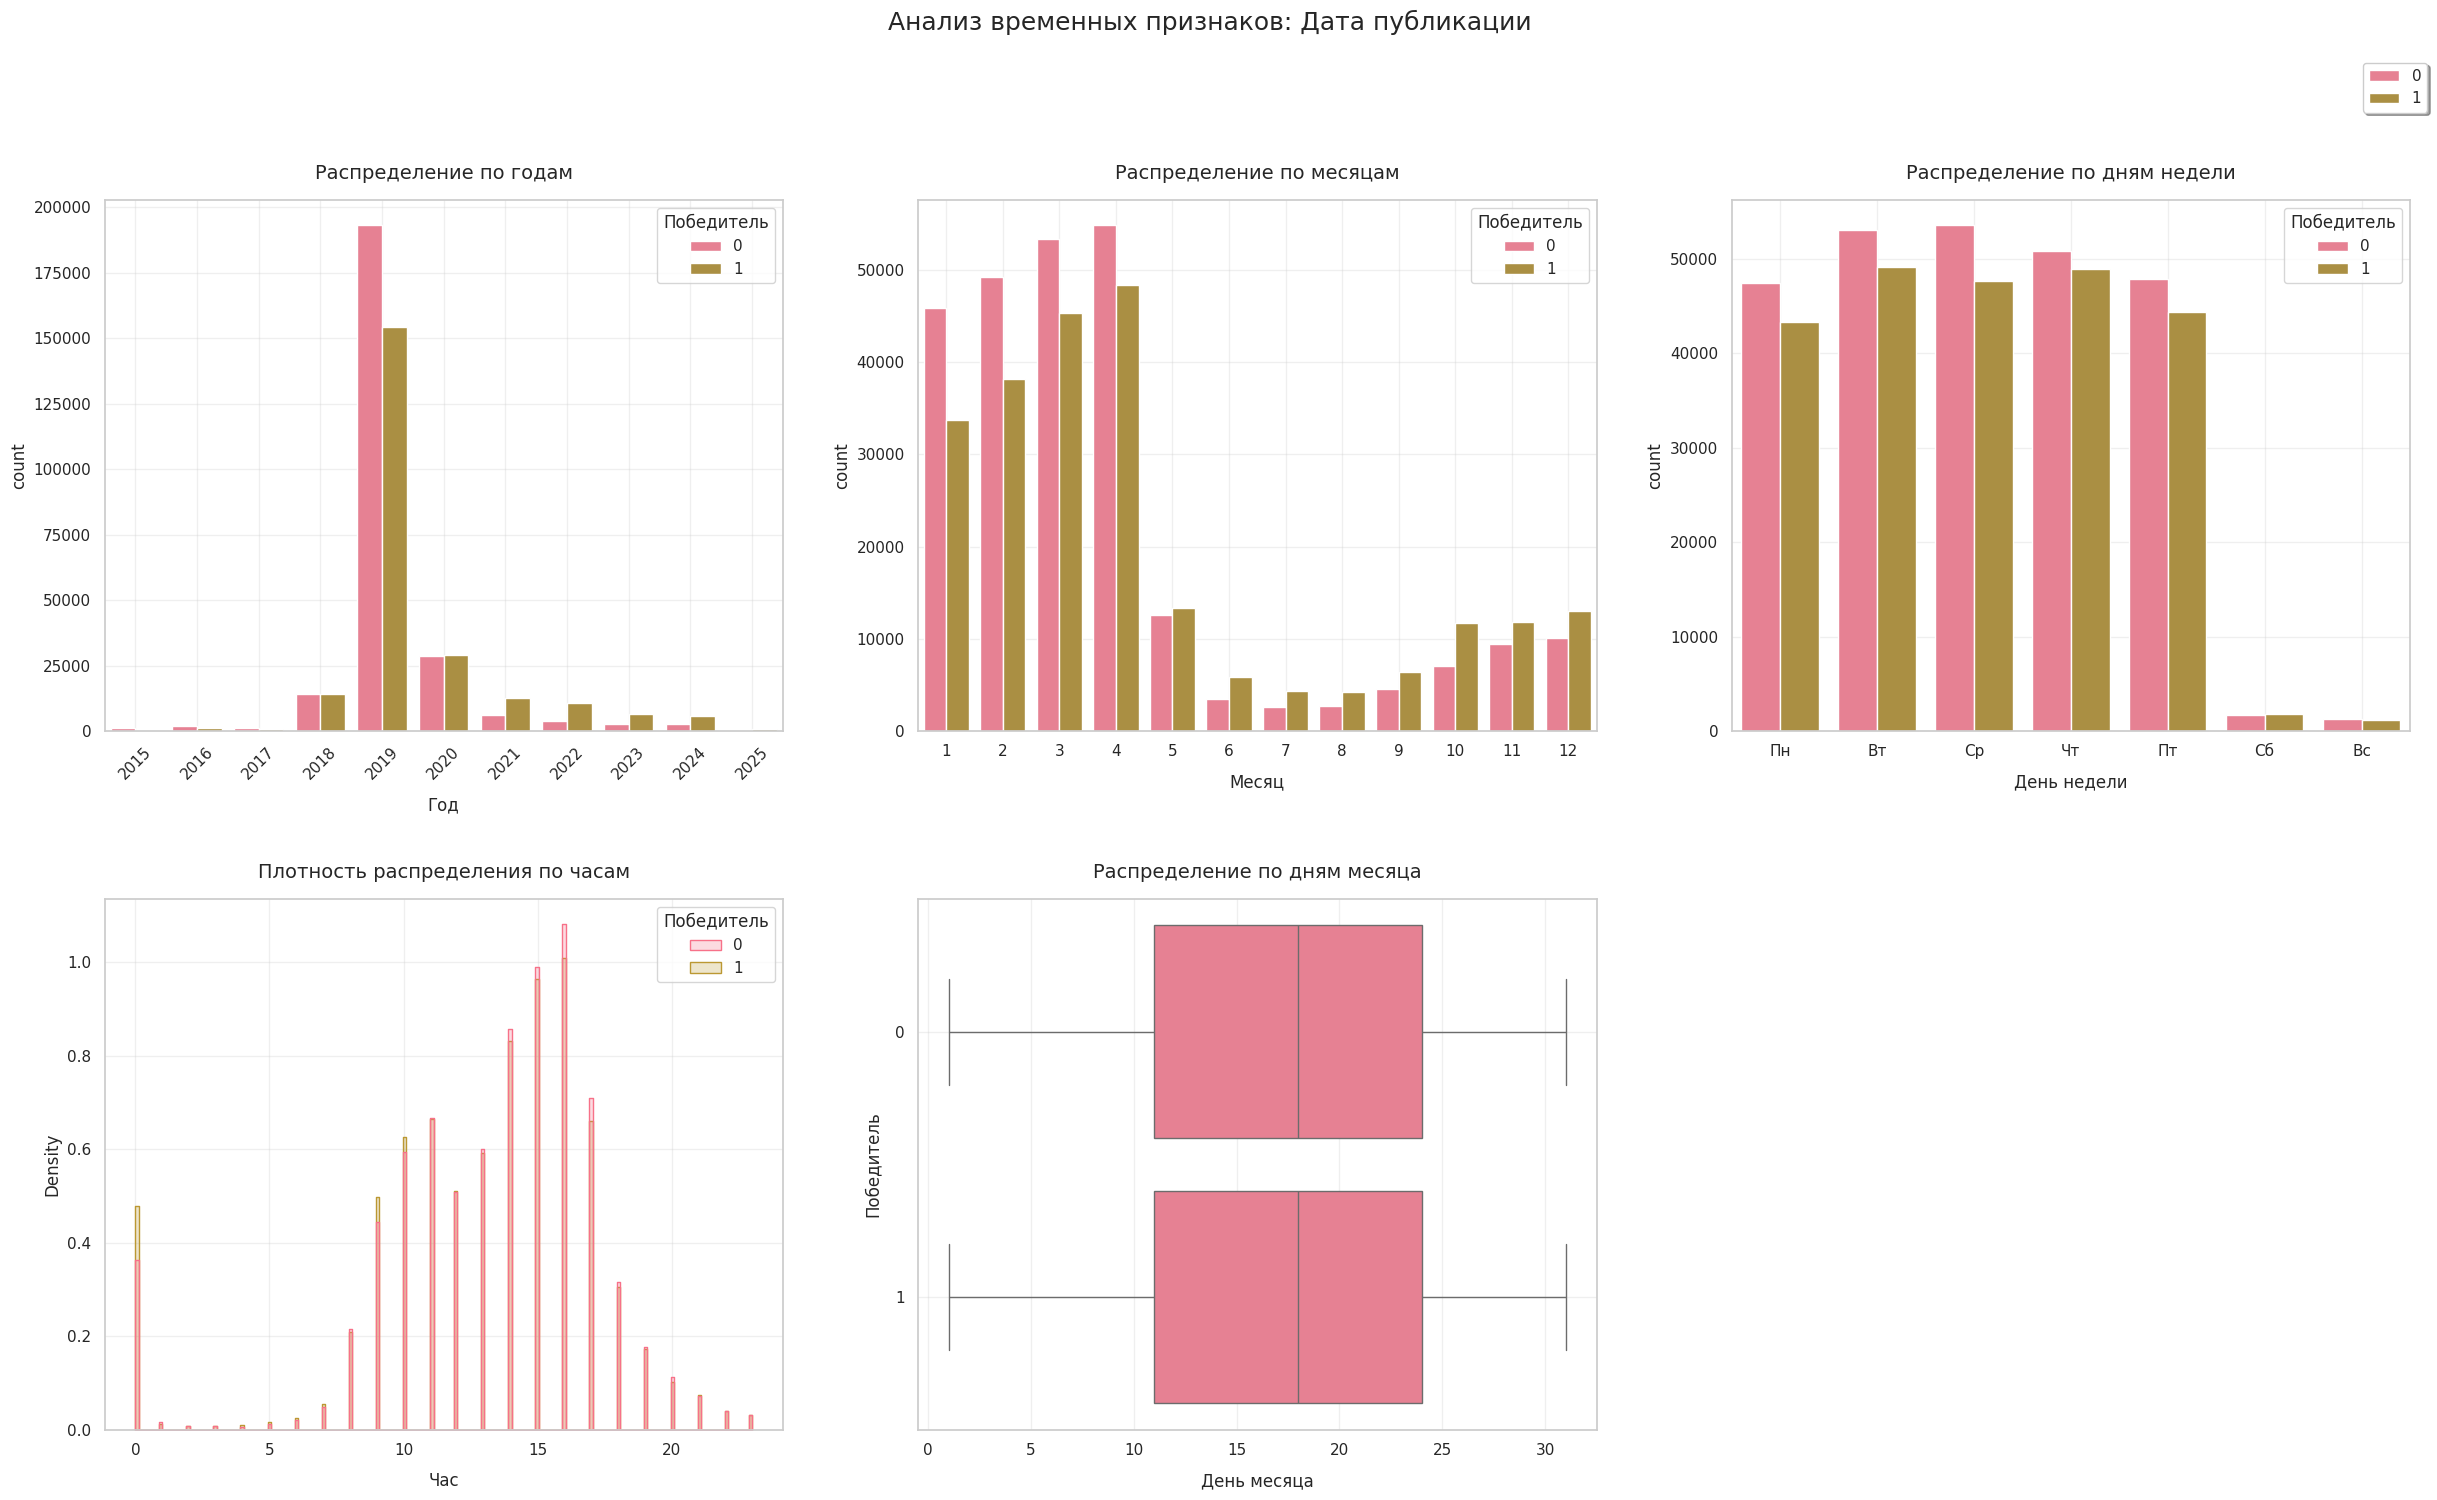

/var/folders/7_/sz_ftshd1b1b9sppxlm9vj9m0000gn/T/ipykernel_72457/3829976560.py:30: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  g3.set_xticklabels(['Пн','Вт','Ср','Чт','Пт','Сб','Вс'])


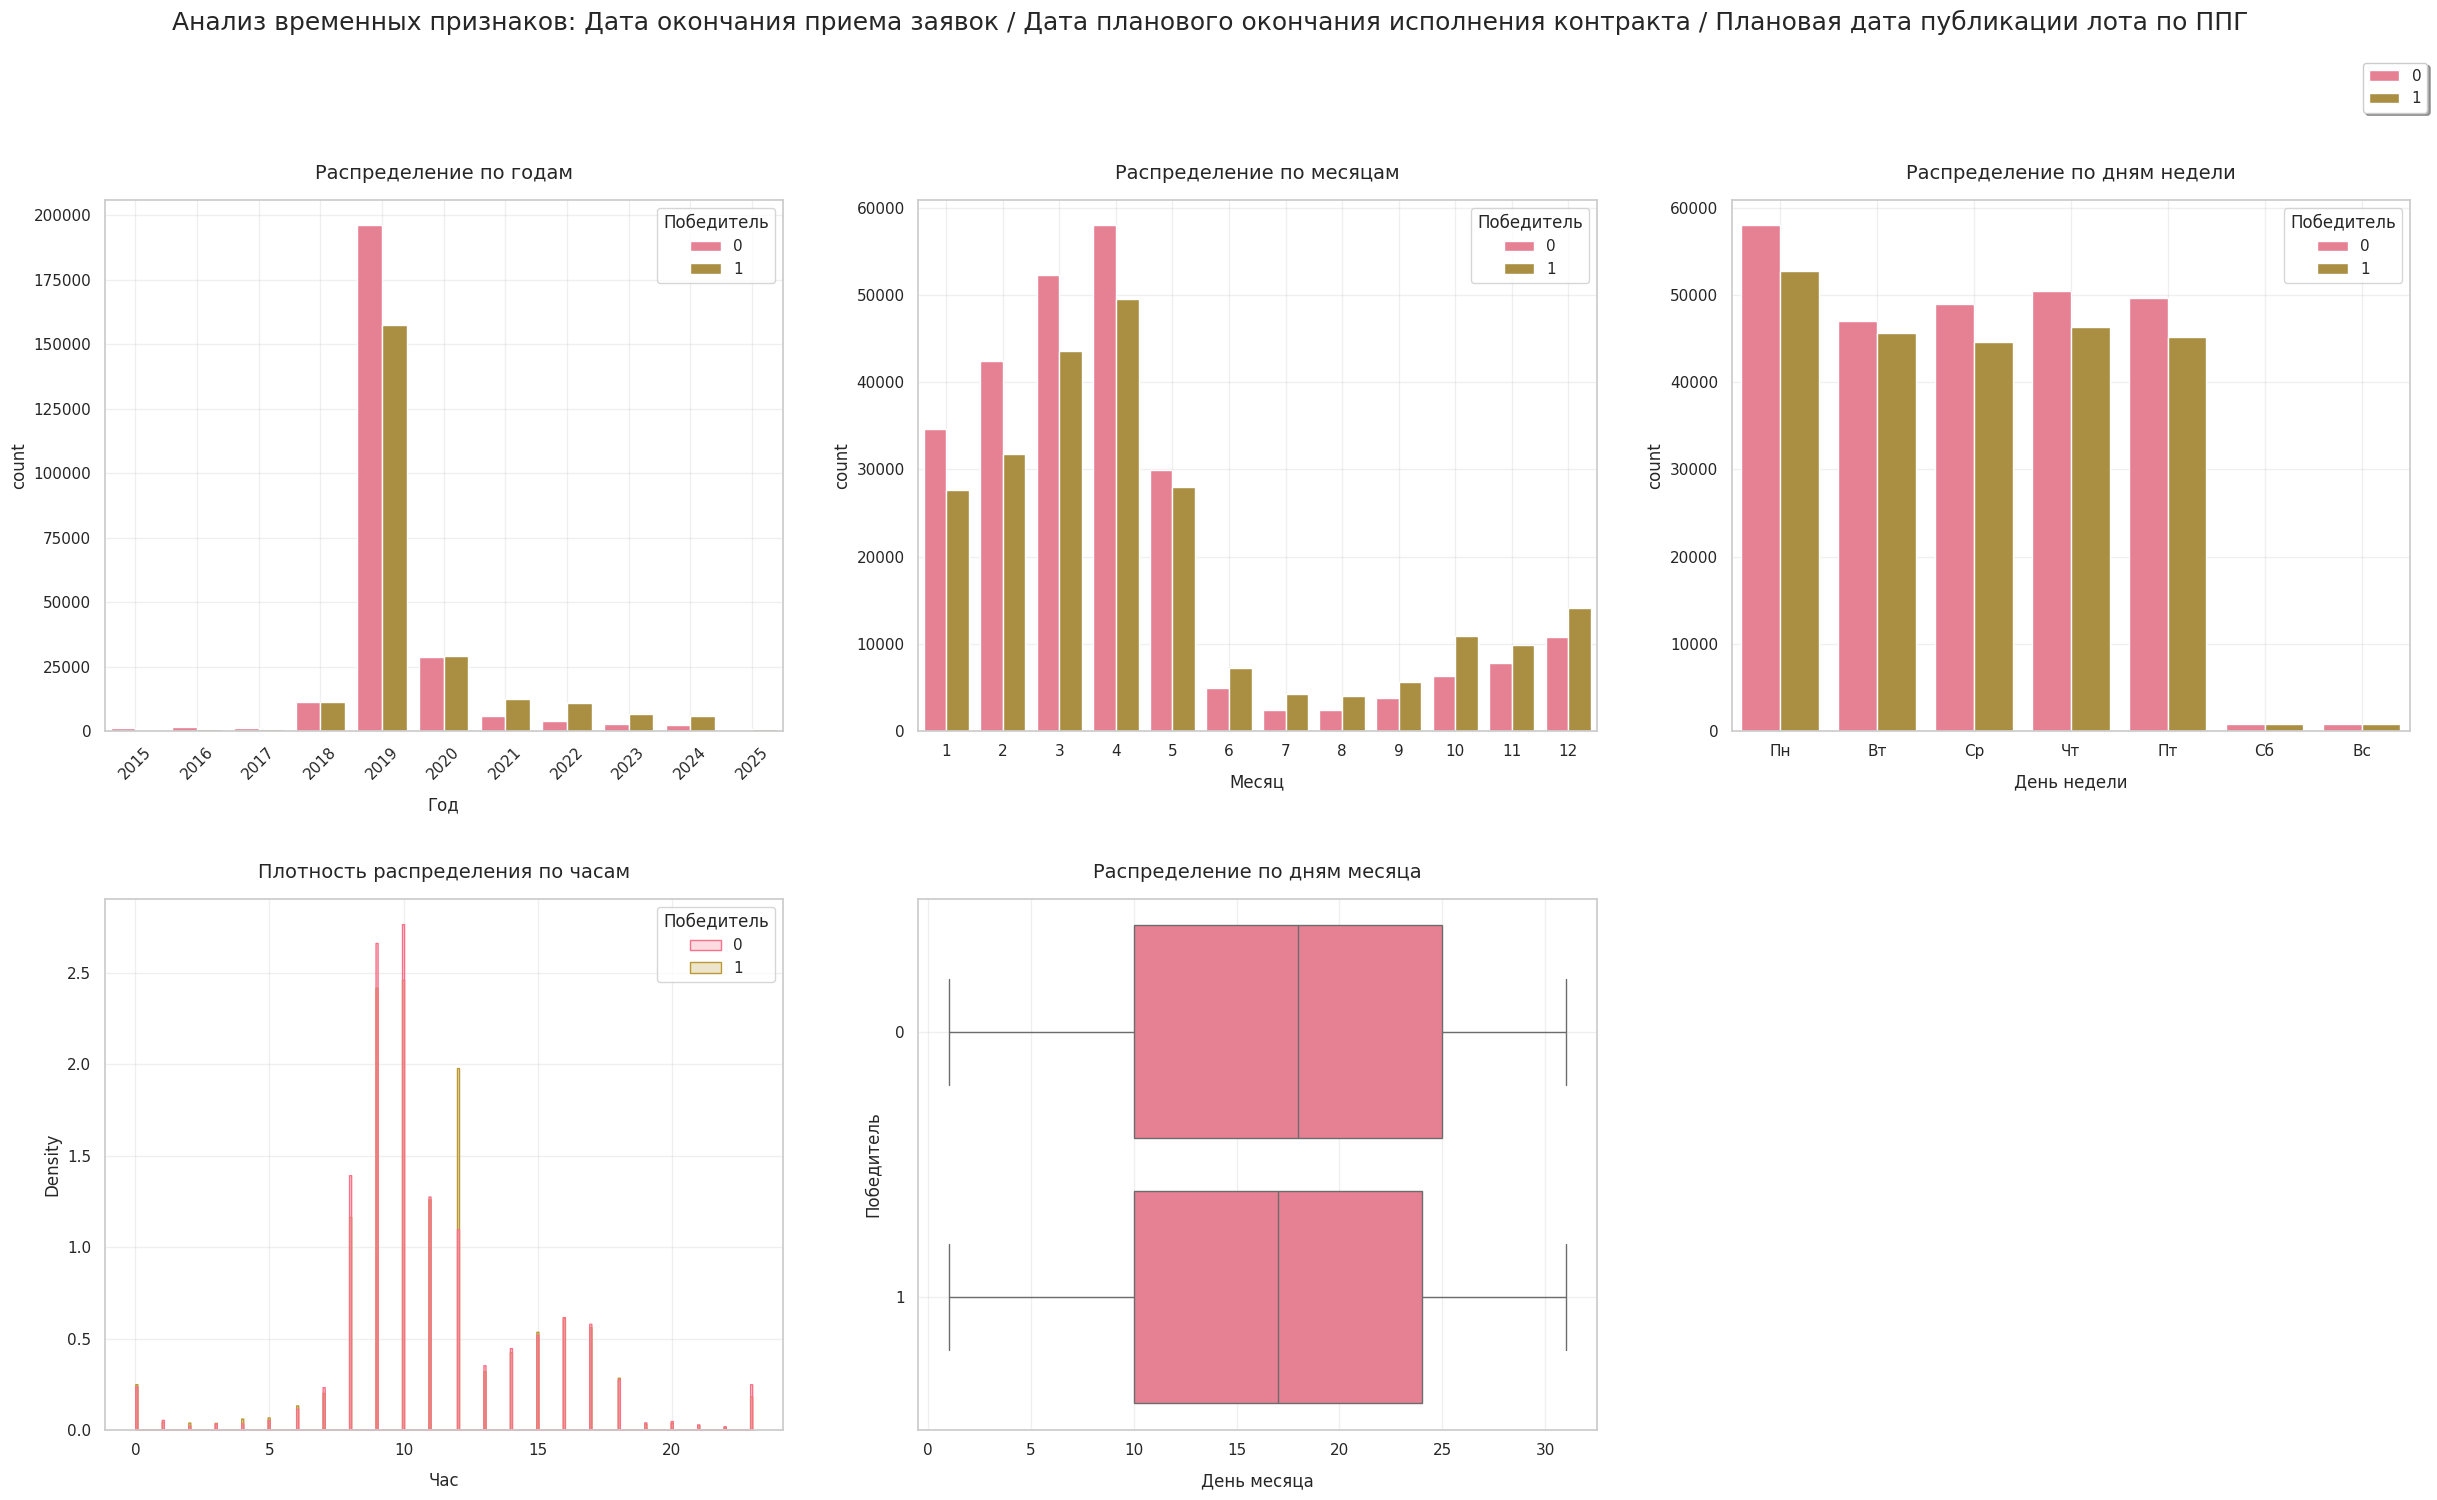

/var/folders/7_/sz_ftshd1b1b9sppxlm9vj9m0000gn/T/ipykernel_72457/3829976560.py:30: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  g3.set_xticklabels(['Пн','Вт','Ср','Чт','Пт','Сб','Вс'])


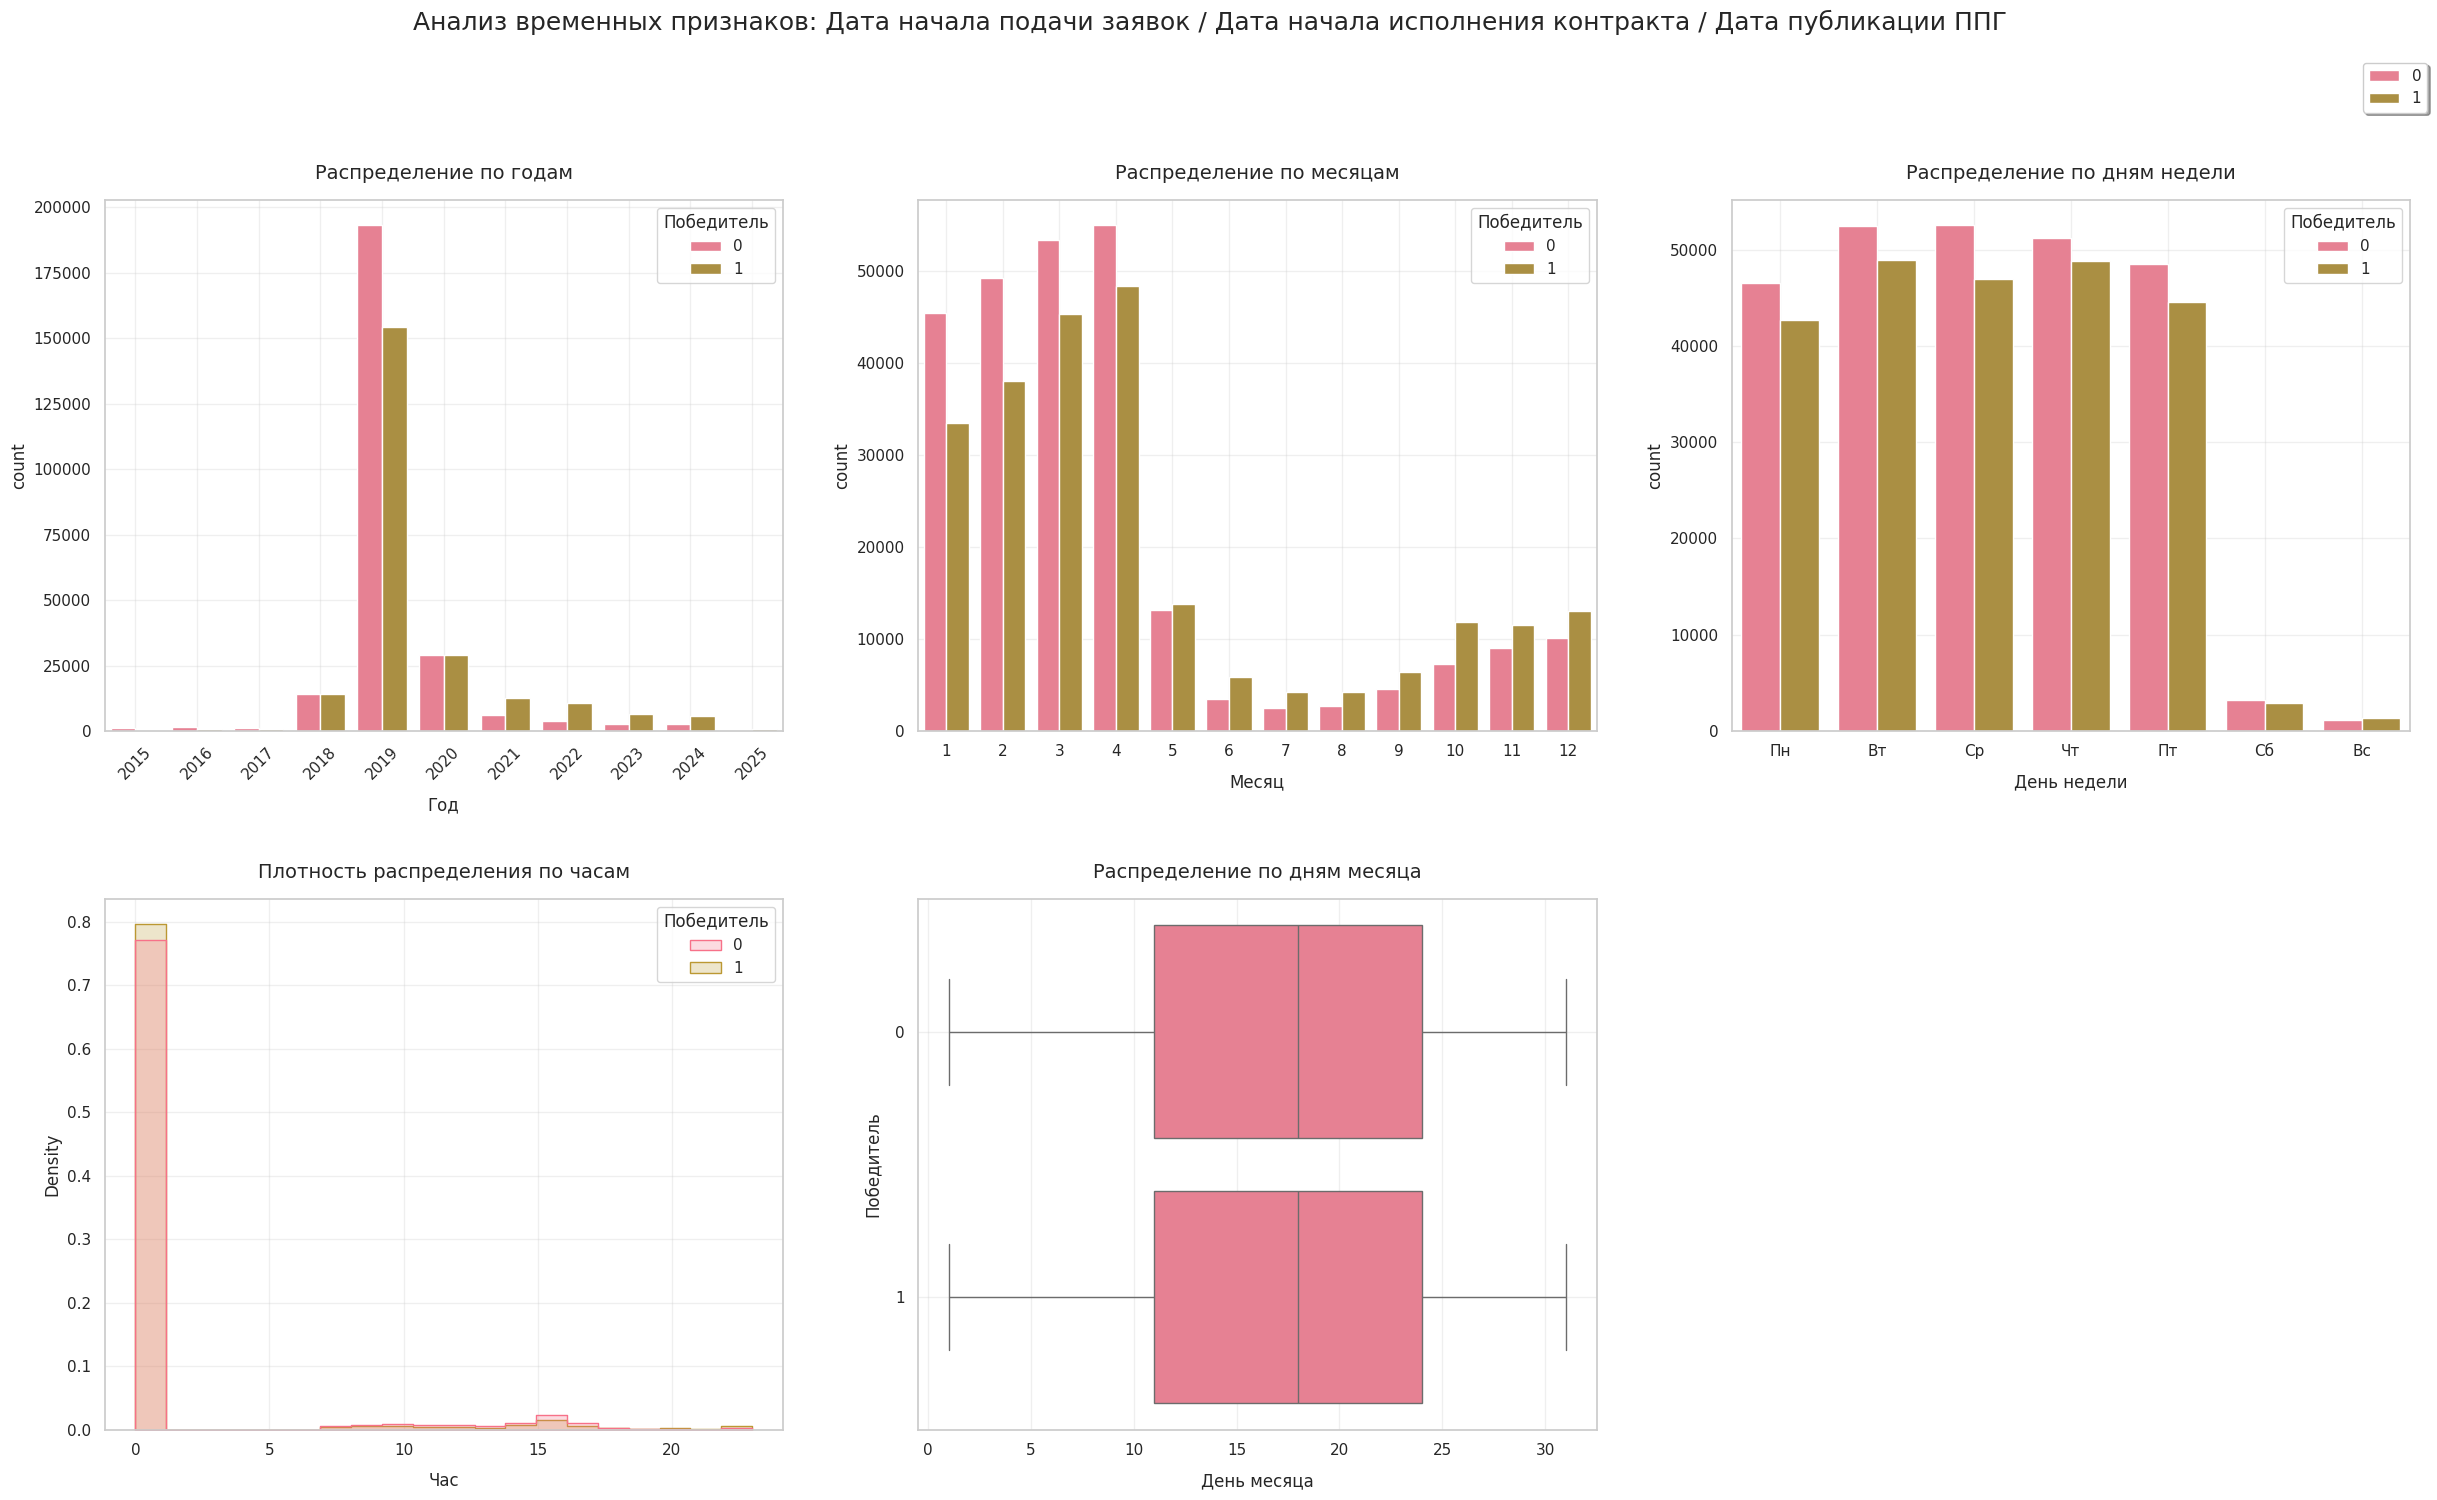

/var/folders/7_/sz_ftshd1b1b9sppxlm9vj9m0000gn/T/ipykernel_72457/3829976560.py:30: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  g3.set_xticklabels(['Пн','Вт','Ср','Чт','Пт','Сб','Вс'])


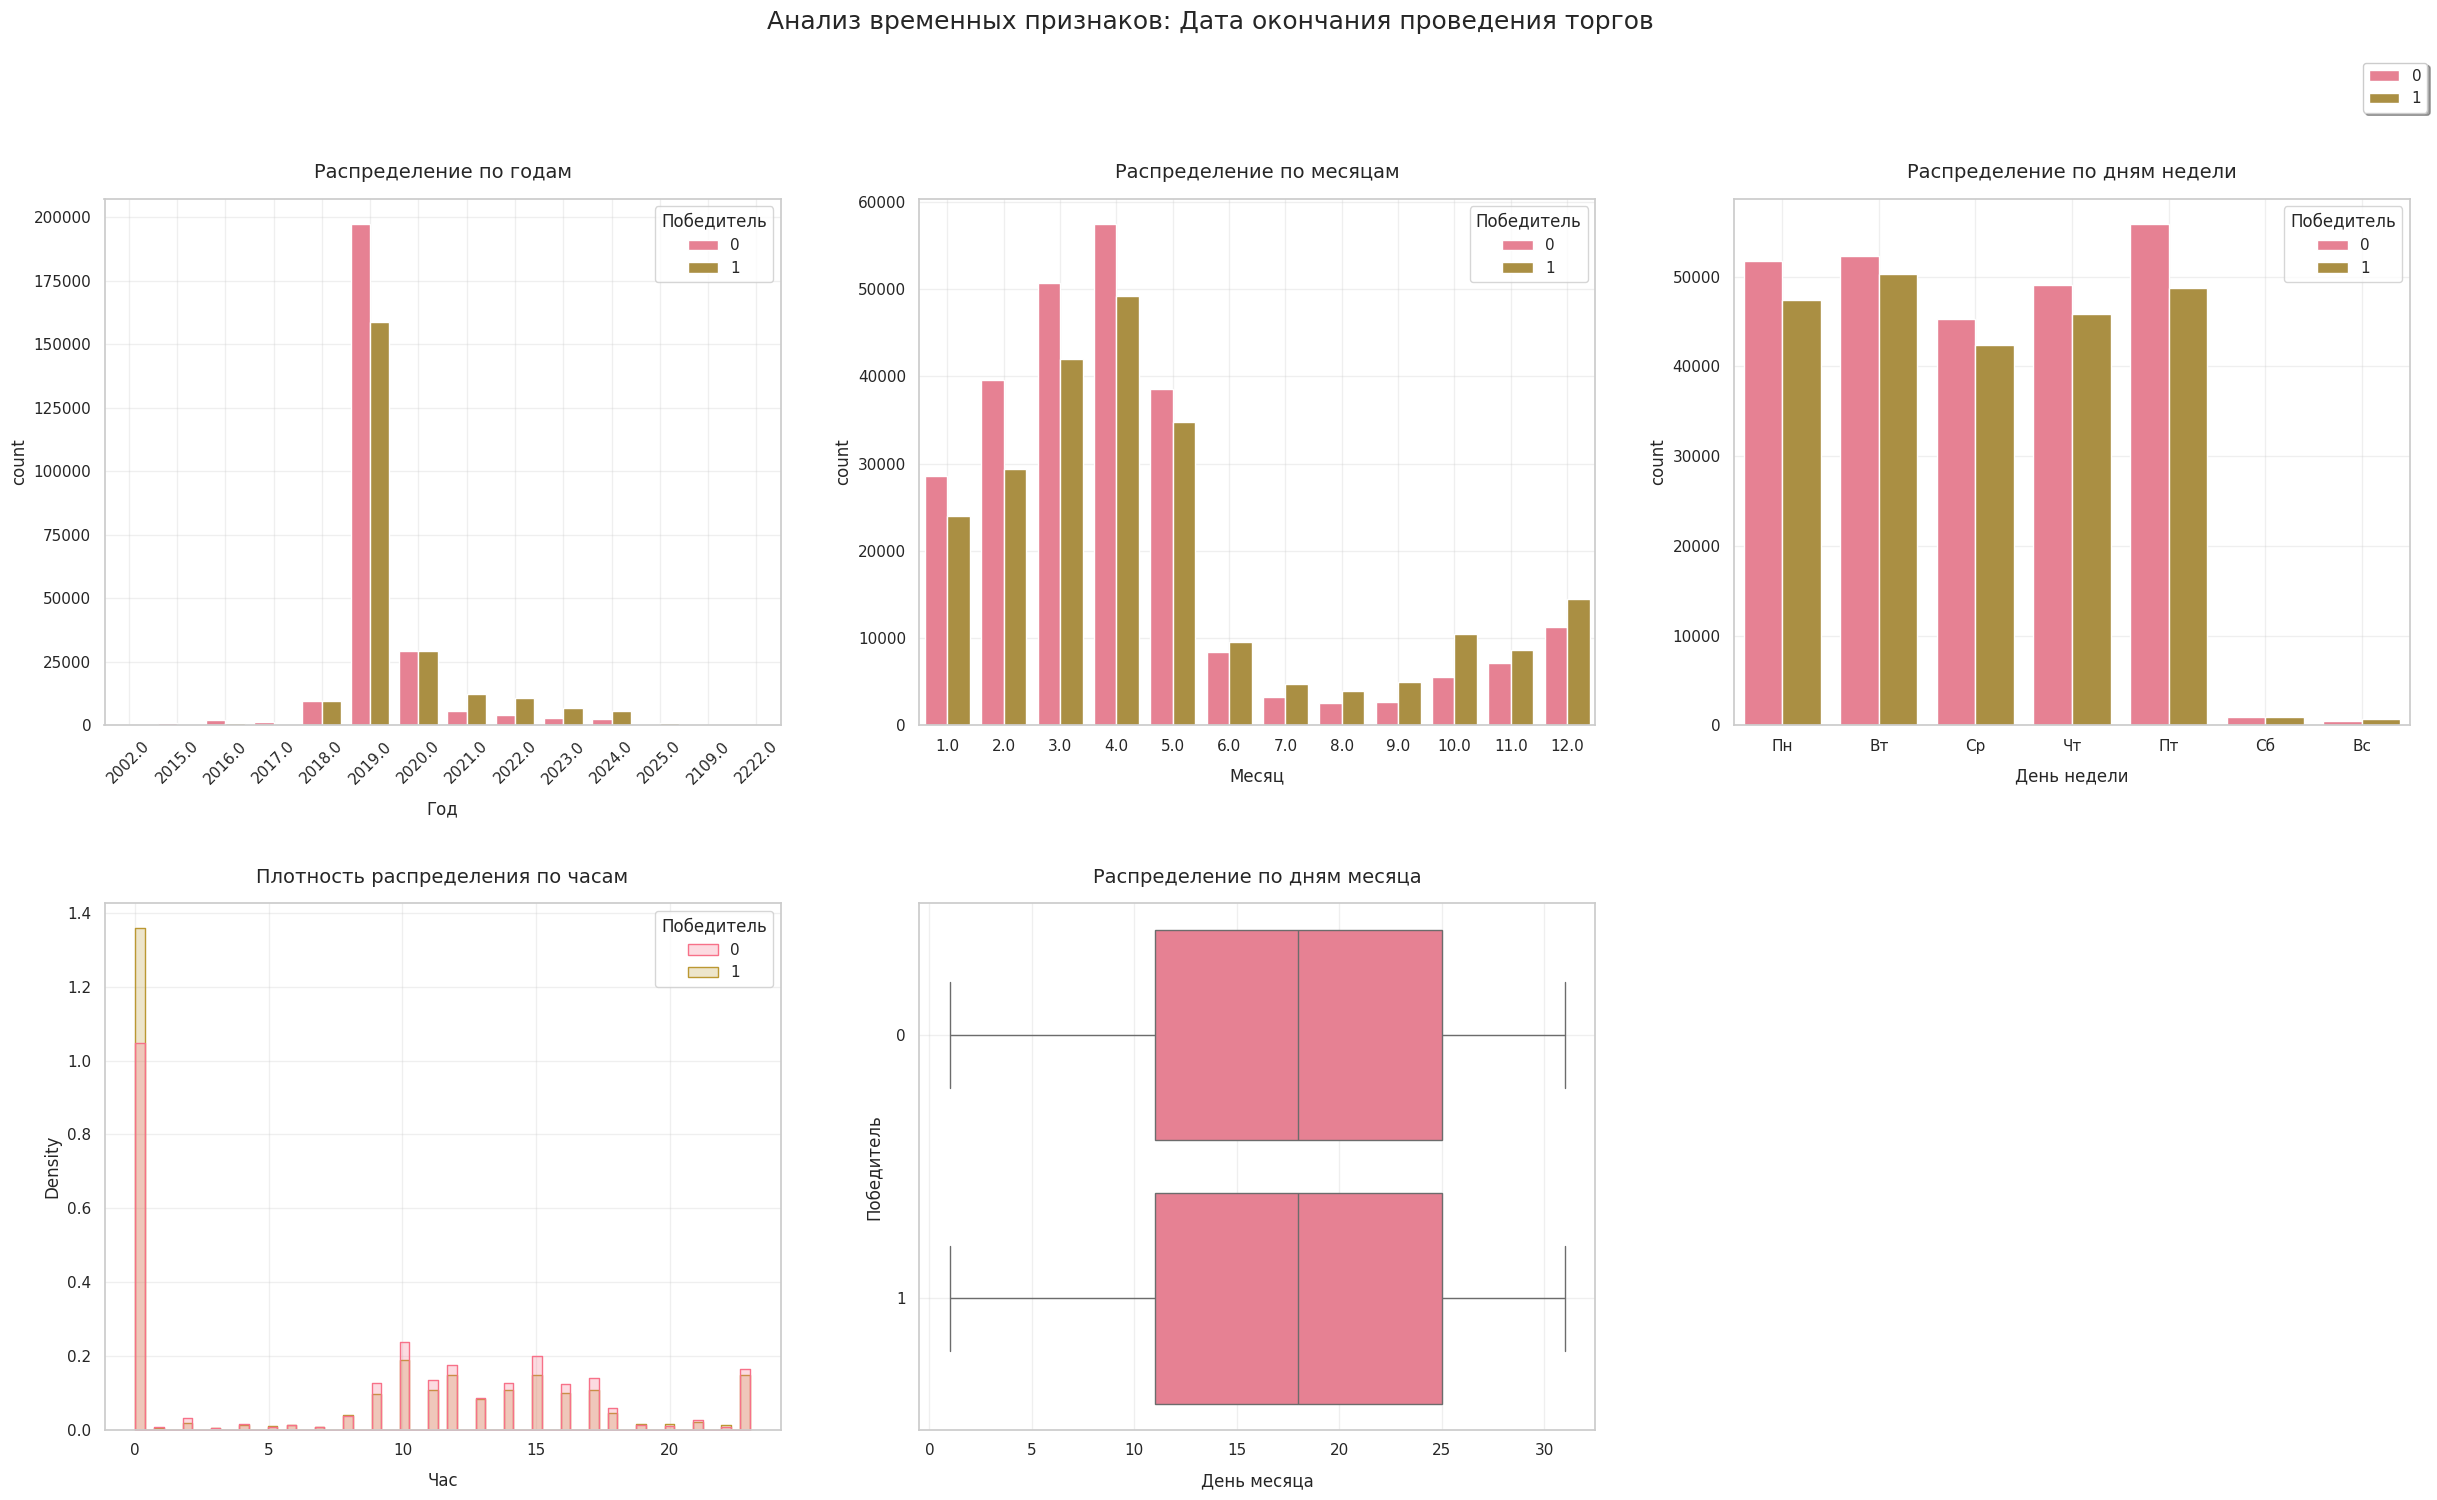

In [86]:
sns.set_theme(style="whitegrid", palette="husl")
plt.rcParams['font.family'] = 'DejaVu Sans'  
time_features = ['Дата публикации',
 'Дата окончания приема заявок / Дата планового окончания исполнения контракта / Плановая дата публикации лота по ППГ',
 'Дата начала подачи заявок / Дата начала исполнения контракта / Дата публикации ППГ',
 'Дата окончания проведения торгов']

#data['Дата окончания проведения торгов'] = pd.to_datetime(data['Дата окончания проведения торгов'])

for time_col in time_features:
    fig, axs = plt.subplots(2, 3, figsize=(25, 15))
    fig.delaxes(axs[1,2])  
    fig.suptitle(f'Анализ временных признаков: {time_col}', fontsize=18, y=1.02)
    
    df_plot = data.assign(year=data[time_col].dt.year,month=data[time_col].dt.month,day=data[time_col].dt.day,
        dayofweek=data[time_col].dt.dayofweek,hour=data[time_col].dt.hour
    )
    
    g1 = sns.countplot(x='year', hue='Победитель', data=df_plot,ax=axs[0,0])
    g1.set_title('Распределение по годам', pad=15)
    g1.set_xlabel('Год', labelpad=10)
    g1.tick_params(axis='x', rotation=45)
    
    g2 = sns.countplot(x='month', hue='Победитель', data=df_plot,ax=axs[0,1])
    g2.set_title('Распределение по месяцам', pad=15)
    g2.set_xlabel('Месяц', labelpad=10)
    
    g3 = sns.countplot(x='dayofweek', hue='Победитель',  data=df_plot,ax=axs[0,2])
    g3.set_title('Распределение по дням недели', pad=15)
    g3.set_xticklabels(['Пн','Вт','Ср','Чт','Пт','Сб','Вс'])
    g3.set_xlabel('День недели', labelpad=10)
    
    g4 = sns.histplot(data=df_plot, x='hour', hue='Победитель', element='step', stat='density', common_norm=False, ax=axs[1,0])
    g4.set_title('Плотность распределения по часам', pad=15)
    g4.set_xlabel('Час', labelpad=10)
    
    g5 = sns.boxplot(x='day', y='Победитель', data=df_plot, orient='h', ax=axs[1,1])
    g5.set_title('Распределение по дням месяца', pad=15)
    g5.set_xlabel('День месяца', labelpad=10)
    g5.set_ylabel('Победитель', labelpad=10)
    
    plt.tight_layout(pad=3.0)
    for ax in axs.flat:
        ax.grid(True, alpha=0.3)
        ax.title.set_fontsize(14)
        ax.xaxis.label.set_fontsize(12)
        ax.yaxis.label.set_fontsize(12)
        
    handles, labels = g1.get_legend_handles_labels()
    fig.legend(handles, labels, loc='upper right', bbox_to_anchor=(0.99, 0.99),frameon=True,shadow=True)
    plt.show()

Из интересного: в январе больше проигравших, во всех остальных месяцах больше победителей - добавим признак на январь. Также добавим разницу между датой окончания приема заявок и датой начала подачи заявок - если, например, дней между ними мало, то это может означаться, что участников будет мало и победителя определить проще. 

Еще видно, что если публикация по времени происходит в 9-11, то победителей больше, чем в другое время (вероятно потому, что в таких тендерах участников меньше), аналогично по окончанию приема заявок в 12. Если начало подачи заявок в 12 ночи, то победителей также больше (аналогично с окончанием проведения торгов в 12 ночи)

В 2020 году количество победителей и участников примерно одинаковое, в отличие от других лет - введем признак на 2020

В общем, пока добавим все это как признаки

In [ ]:
data['Дата окончания проведения торгов'] = data['Дата окончания проведения торгов'].dropna()

In [104]:
data['is_january'] = data['month'].apply(lambda x: 1 if x == 1 else 0)
data['days_between'] = (data['Дата окончания приема заявок / Дата планового окончания исполнения контракта / Плановая дата публикации лота по ППГ'] - 
                       data['Дата начала подачи заявок / Дата начала исполнения контракта / Дата публикации ППГ']).dt.days

data['publication_peak_9_11'] = data['Дата публикации'].dt.hour.between(9, 11, inclusive='both').astype(int)
data['app_end_noon_12'] = (data['Дата окончания приема заявок / Дата планового окончания исполнения контракта / Плановая дата публикации лота по ППГ'].dt.hour == 12).astype(int)
data['app_start_night_12'] = (data['Дата начала подачи заявок / Дата начала исполнения контракта / Дата публикации ППГ'].dt.hour == 0).astype(int)
data['trade_end_night_12'] = (data['Дата окончания проведения торгов'].dt.hour == 0).astype(int)
data['is_2019'] = data['year'].apply(lambda x: 1 if x == 2019 else 0)
data['is_jan_to_april'] = data['month'].apply(lambda x: 1 if x <= 4 else 0)

In [105]:
data.to_csv('preprocessed_full.csv')

____________________________________________________________________________________________________________________

**Encoding and scaling**

In [89]:
data.dtypes

Уровень                                                                                                                         int64
Заказчик                                                                                                                       object
ИНН заказчика                                                                                                                   int64
Стоимость(руб.) Заказчик                                                                                                      float64
Реестровый номер публикации                                                                                                    object
Сфера деятельности                                                                                                             object
Регион поставки                                                                                                                object
Город поставки                                                

In [106]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import RobustScaler

num = [
    "avg_price_drop",
    "log_cost",
    "log_profit",
    "Снижение на торгах,%",
    'win_rate',  'region_win_rate', 
    'customer_win_rate', 'sphere_win_rate',
    "days_between",
    "region_wins",
    "customer_wins",
    "sphere_wins",
    "total_wins",
    "competitors_per_tender",
    "avg_competitors_in_region",
    "avg_competitors_in_sphere",
    "avg_competitors_in_customer"
]

cat = [
    "Сфера деятельности",
    "Регион поставки",
    "Город поставки",
    "Тип торгов",
    "Уровень",
    "year",
    "month",
    "Сводный риск"
]

binary_features = [
    "РНП ранее", 
    "is_january", 
    "publication_peak_9_11", 
    "app_end_noon_12", 
    "app_start_night_12",
    "trade_end_night_12",
    "is_2019",
    "is_jan_to_april",
    "Статус допуска"
]

preprocessor = ColumnTransformer(
    transformers=[
        ('num', RobustScaler(), num),
        ('cat', OneHotEncoder(sparse_output=False,handle_unknown='ignore'), cat),
        ('pass', 'passthrough', binary_features)
    ],
    remainder='drop'
    )

train = data[data['year'].isin(range(2015, 2021))]
test = data[data['year'].isin(range(2021, 2026))]
X_train = train[num + cat + binary_features]
y_train = train["Победитель"]
X_test = test[num + cat + binary_features]
y_test = test["Победитель"]

In [107]:
print(X_test.shape)
print(X_train.shape)

(51991, 34)
(440066, 34)


____________________________________________________________________________________________________________________

**Модели**

In [99]:
def evaluate_model(name, y_true, y_pred, y_proba):
    print(f"\n{name} Metrics:")
    print("Accuracy:", round(accuracy_score(y_true, y_pred), 4))
    print("Precision:", round(precision_score(y_true, y_pred), 4))
    print("Recall:", round(recall_score(y_true, y_pred), 4))
    print("F1-Score:", round(f1_score(y_true, y_pred), 4))
    print("ROC-AUC:", round(roc_auc_score(y_true, y_proba), 4))
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred))
    print("Confusion Matrix:")
    print(confusion_matrix(y_true, y_pred))
    
    plt.figure(figsize=(10, 8))
    conf_matrix = confusion_matrix(y_true, y_pred)
    sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Not Winner', 'Winner'],
                yticklabels=['Not Winner', 'Winner'])
    plt.title(f'Confusion Matrix - {name}')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()
    plt.show()

Важный вопрос - какая метрика нам все-таки важнее, precision или recall? Как будто для задачи победителя тендера, нам интереснее recall, поскольку мы хотим не пропустить потенциальных победителей, но это пока мысли (то есть мы можем пожертвовать precision - лучше попадет несколько ложных, но среди всех предсказанных с большей вероятностью будет потенциальный победитель) - так как пока неясно, подбираю по f1, то есть по сумме precision и recall

1. KNN (k nearest neighbors)

In [108]:
knn_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', KNeighborsClassifier())
])

In [109]:
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import train_test_split

X_train_new, X_val, y_train_new, y_val = train_test_split(X_train, y_train, test_size=0.3, random_state=42)
#здесь было рассмотрено в разы больше параметров, сейчас оставлено немного, чтобы перезапускать удобнее
param_grid = {
    'classifier__n_neighbors': [25, 81],
    'classifier__weights': ['distance'],
    'classifier__p': [1], 
    'classifier__metric': ['minkowski']
}

grid_search = GridSearchCV(
    knn_pipeline,
    param_grid,
    cv=3,
    scoring='f1',
    verbose=2,
    error_score='raise'
)
grid_search.fit(X_val, y_val)

Fitting 3 folds for each of 2 candidates, totalling 6 fits


: 

In [111]:
print("\nBest parameters:", grid_search.best_params_)
print("Best F1 score:", round(grid_search.best_score_, 4))
best_knn = grid_search.best_estimator_
best_knn.fit(X_train, y_train)
y_pred = best_knn.predict(X_test)
y_proba = best_knn.predict_proba(X_test)[:, 1]
evaluate_model("Best KNN Model", y_test, y_pred, y_proba)

NameError: name 'grid_search' is not defined


Best parameters: {'classifier__metric': 'minkowski', 'classifier__n_neighbors': 23, 'classifier__p': 1, 'classifier__weights': 'distance'}
Best F1 score: 0.9464

Best KNN Model Metrics:
Accuracy: 0.8555
Precision: 0.8718
Recall: 0.9295
F1-Score: 0.8997
ROC-AUC: 0.9476

Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.68      0.74      5668
           1       0.87      0.93      0.90     13068

    accuracy                           0.86     18736
   macro avg       0.84      0.81      0.82     18736
weighted avg       0.85      0.86      0.85     18736

Confusion Matrix:
[[ 3881  1787]
 [  921 12147]]


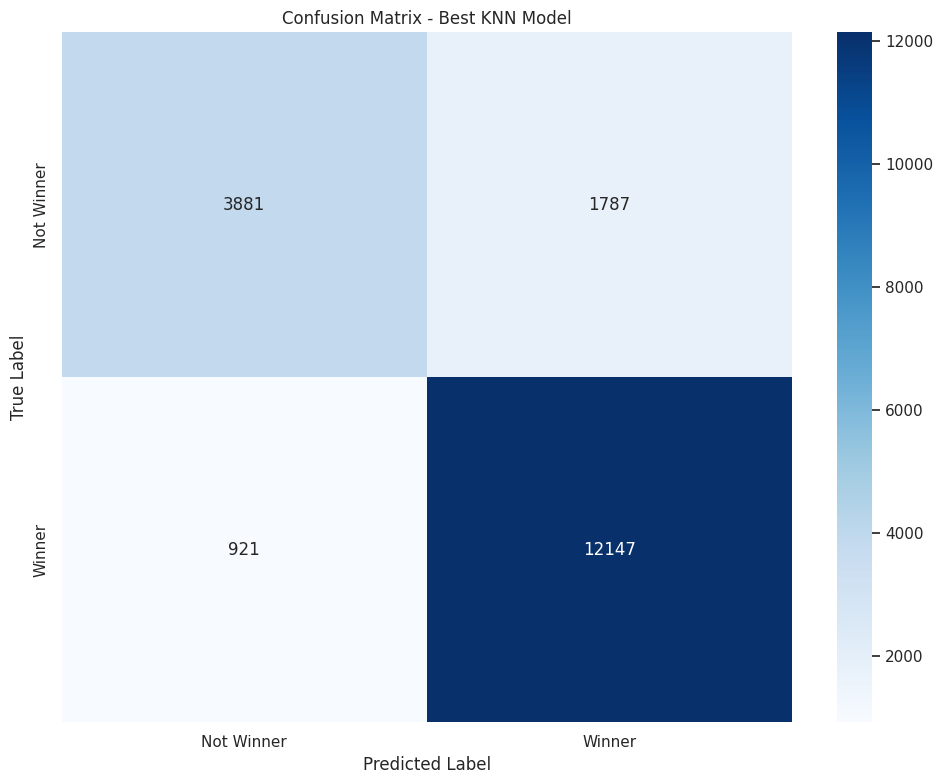

In [87]:
print("\nBest parameters:", grid_search.best_params_)
print("Best F1 score:", round(grid_search.best_score_, 4))
best_knn = grid_search.best_estimator_
best_knn.fit(X_train, y_train)
y_pred = best_knn.predict(X_test)
y_proba = best_knn.predict_proba(X_test)[:, 1]
evaluate_model("Best KNN Model", y_test, y_pred, y_proba)
#recall наибольший при n_neighbours = 15 или 13

По сравнению с предыдущими моделями (без такого шкалирования и с немного иными признаками) общее качество выросло - precision немного снизился, но вот непобедителей модель начала предсказывать в разы лучше (до этого было примерно 50/50, ближе к случайному)

In [ ]:
best_knn_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', KNeighborsClassifier(n_neighbors=grid_search.best_params_['classifier__n_neighbors'], weights=grid_search.best_params_['classifier__weights'], metric=grid_search.best_params_['classifier__metric'], p = grid_search.best_params_['classifier__p']))
])

best_knn_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', RobustScaler(),
                                                  ['avg_price_drop', 'log_cost',
                                                   'log_profit',
                                                   'Снижение на торгах,%',
                                                   'win_rate',
                                                   'region_win_rate',
                                                   'customer_win_rate',
                                                   'sphere_win_rate',
                                                   'days_between',
                                                   'region_wins',
                                                   'customer_wins',
                                                   'sphere_wins', 'total_wins',
                                                   'competitors_per_tender',
                                                   'avg_competitors_in_region',
                                                   'avg_comp...
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Сфера деятельности',
                                                   'Регион поставки',
                                                   'Город поставки',
                                                   'Тип торгов', 'Уровень',
                                                   'year', 'month']),
                                                 ('pass', 'passthrough',
                                                  ['РНП ранее', 'is_january',
                                                   'publication_peak_9_11',
                                                   'app_end_noon_12',
                                                   'app_start_night_12',
                                                   'trade_end_night_12',
                                                   'is_2020',
                                                   'Статус допуска'])])),
                ('classifier',
                 KNeighborsClassifier(n_neighbors=23, p=1,
                                      weights='distance'))])

In [ ]:
X_transformed = preprocessor.fit_transform(X_train).toarray() 
X_transformed.shape

(91139, 7291)

In [90]:
best_knn = KNeighborsClassifier(n_neighbors=grid_search.best_params_['classifier__n_neighbors'], weights=grid_search.best_params_['classifier__weights'], metric=grid_search.best_params_['classifier__metric'], p = grid_search.best_params_['classifier__p'])

In [ ]:
from sklearn.base import clone 
import time
import tqdm

baseline_features = [f for f in num + binary_features + cat if f in X_train.columns]
features_to_evaluate_lofo = [
    'log_cost', 
    'log_profit', 
    #'customer_win_rate', 
    #'Снижение на торгах,%',
    #'days_between',
    'Уровень'
]

features_to_evaluate_lofo = [f for f in features_to_evaluate_lofo if f in baseline_features] 


def create_dynamic_preprocessor(feature_list, num_list, cat_list, bin_list):
    current_num = [f for f in num_list if f in feature_list]
    current_cat = [f for f in cat_list if f in feature_list]
    current_bin = [f for f in bin_list if f in feature_list]
    
    transformers = []
    
    if current_num:
        numeric_transformer = Pipeline(steps=[('scaler', RobustScaler())])
        transformers.append(('num', numeric_transformer, current_num))
        
    if current_cat:
        categorical_transformer = Pipeline(steps=[('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))])
        transformers.append(('cat', categorical_transformer, current_cat))
        
    if current_bin:
         transformers.append(('bin', 'passthrough', current_bin))
         
    preprocessor = ColumnTransformer(
        transformers=transformers,
        remainder='drop' 
    )
    return preprocessor


def calculate_metric(y_true, y_pred):
    return f1_score(y_true, y_pred) 


def calculate_lofo_importance(
    baseline_model_proto, 
    baseline_features_list, 
    features_to_evaluate_list, 
    fn_create_preprocessor, 
    num_list_all, cat_list_all, bin_list_all, 
    X_tr, y_tr, 
    X_va, y_va, 
    metric_func 
    ):
    
    start_time_total = time.time()
    importances = {}
    
    start_time_baseline = time.time()
    baseline_preprocessor = fn_create_preprocessor(baseline_features_list, num_list_all, cat_list_all, bin_list_all)
    
    baseline_pipeline = Pipeline(steps=[
        ('preprocessor', baseline_preprocessor),
        ('classifier', clone(baseline_model_proto))
    ])
    
    baseline_pipeline.fit(X_tr[baseline_features_list], y_tr)
    y_pred_baseline = baseline_pipeline.predict(X_va[baseline_features_list])
    baseline_score = metric_func(y_va, y_pred_baseline)
    
    end_time_baseline = time.time()
    print(f"Baseline Score ({metric_func.__name__}): {baseline_score:.4f}")
    print(f"Время расчета Baseline: {end_time_baseline - start_time_baseline:.2f} сек.")
    
    print(f"\nРасчет LOFO для {len(features_to_evaluate_list)}")
    
    for feature_to_remove in tqdm(features_to_evaluate_list, desc="LOFO Progress"):
        start_time_feature = time.time()
        current_features = [f for f in baseline_features_list if f != feature_to_remove]
        current_preprocessor = fn_create_preprocessor(current_features, num_list_all, cat_list_all, bin_list_all)
        current_pipeline = Pipeline(steps=[
            ('preprocessor', current_preprocessor),
            ('classifier', clone(baseline_model_proto))
        ])
        
        current_pipeline.fit(X_va[current_features], y_va)
        y_pred_without_feature = current_pipeline.predict(X_va[current_features])
        score_without_feature = metric_func(y_va, y_pred_without_feature)
        importance = baseline_score - score_without_feature
        importances[feature_to_remove] = importance
        end_time_feature = time.time()
        print(f"  '{feature_to_remove}': Score={score_without_feature:.4f}, Importance={importance:.4f}, Time={end_time_feature - start_time_feature:.2f} сек.")

    end_time_total = time.time()
    lofo_results = pd.Series(importances).sort_values(ascending=False)
    return lofo_results


lofo_importance_scores = calculate_lofo_importance(
    baseline_model_proto=best_knn,
    baseline_features_list=baseline_features,
    features_to_evaluate_list=features_to_evaluate_lofo,
    fn_create_preprocessor=create_dynamic_preprocessor,
    num_list_all=num, 
    cat_list_all=cat,
    bin_list_all=binary_features,
    X_tr=X_train, 
    y_tr=y_train,
    X_va=X_val, 
    y_va=y_val,
    metric_func=calculate_metric
)

In [ ]:
print("\nРезультаты LOFO Importance:")
print(lofo_importance_scores)

if not lofo_importance_scores.empty:
     plt.figure(figsize=(10, len(lofo_importance_scores) * 0.4))
     lofo_importance_scores.sort_values(ascending=True).plot(kind='barh')
     plt.title(f'LOFO Importance ({calculate_metric.__name__})')
     plt.xlabel(f'Падение метрики ({calculate_metric.__name__}) при удалении признака')
     plt.tight_layout()
     plt.show()

In [54]:
sample_idx = np.random.choice(X_train.shape[0], size=int(X_train.shape[0]*0.05), replace=False)
X_sample = X_train.iloc[sample_idx]
y_sample = y_train.iloc[sample_idx]

Из документации по permutation_importance:

***When two features are correlated and one of the features is permuted, the model still has access to the latter through its correlated feature. This results in a lower reported importance value for both features, though they might actually be important***

так что будем это учитывать, возможно в будущем оставим только некоррелированные между собой фичи

2. SVM 

В силу того, что все это чудо обучается бесконечно количество времени (да и признаков на данный момент больше 7к после кодировки), понизим размерность данных и поробуем на них 

In [56]:
'''
from sklearn.decomposition import PCA

X_transformed = preprocessor.fit_transform(X_train).toarray()

pca = PCA()
pca.fit(X_transformed)
cumsum = np.cumsum(pca.explained_variance_ratio_)
n_components_95 = np.argmax(cumsum >= 0.95) + 1

pca = PCA(n_components=n_components_95)
X_pca = pca.fit_transform(X_transformed)


plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.axhline(y=0.95, color='r', linestyle='--', label='95% Variance Threshold')
plt.axvline(x=n_components_95, color='g', linestyle='--', 
           label=f'Components needed: {n_components_95}')
plt.xlabel('Number of Components')
plt.ylabel('Variance Retained')
plt.legend()
'''

"\nfrom sklearn.decomposition import PCA\n\nX_transformed = preprocessor.fit_transform(X_train).toarray()\n\npca = PCA()\npca.fit(X_transformed)\ncumsum = np.cumsum(pca.explained_variance_ratio_)\nn_components_95 = np.argmax(cumsum >= 0.95) + 1\n\npca = PCA(n_components=n_components_95)\nX_pca = pca.fit_transform(X_transformed)\n\n\nplt.plot(np.cumsum(pca.explained_variance_ratio_))\nplt.axhline(y=0.95, color='r', linestyle='--', label='95% Variance Threshold')\nplt.axvline(x=n_components_95, color='g', linestyle='--', \n           label=f'Components needed: {n_components_95}')\nplt.xlabel('Number of Components')\nplt.ylabel('Variance Retained')\nplt.legend()\n"

In [57]:
#это уже перебиралось, больше сил нет это запускать
'''
param_grid = {
    'classifier__C': [1, 10, 100],
    'classifier__gamma': ['scale', 0.01],
    'classifier__kernel': ['rbf', 'poly', 'linear'],
    'classifier__class_weight': ['balanced']
}

grid_search = GridSearchCV(
    svm_pipeline,
    param_grid,
    cv=3,
    scoring='f1',
    verbose = 1
)
'''
#grid_search.fit(X_sample, y_sample)
#print("\nBest parameters:", grid_search.best_params_)
#print("Best F1 score:", round(grid_search.best_score_, 4))
#best_svm = grid_search.best_estimator_
#y_pred = best_svm.predict(X_test)
#y_proba = best_svm.predict_proba(X_test)[:, 1]
#evaluate_model("Best SVM Model", y_test, y_pred, y_proba)

"\nparam_grid = {\n    'classifier__C': [1, 10, 100],\n    'classifier__gamma': ['scale', 0.01],\n    'classifier__kernel': ['rbf', 'poly', 'linear'],\n    'classifier__class_weight': ['balanced']\n}\n\ngrid_search = GridSearchCV(\n    svm_pipeline,\n    param_grid,\n    cv=3,\n    scoring='f1',\n    verbose = 1\n)\n"

In [58]:
#чтобы не ждать, пока обучится, брала 40% данных
sample_idx = np.random.choice(X_train.shape[0], size=int(X_train.shape[0]*0.4), replace=False)
X_sample = X_train.iloc[sample_idx]
y_sample = y_train.iloc[sample_idx]

In [91]:
svm_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', SVC(probability=True, random_state=42, kernel='rbf', class_weight='balanced', C = 150, gamma = 'scale'))
])


SVM Metrics:
Accuracy: 0.858
Precision: 0.8724
Recall: 0.9329
F1-Score: 0.9016
ROC-AUC: 0.9535

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.69      0.74      5668
           1       0.87      0.93      0.90     13068

    accuracy                           0.86     18736
   macro avg       0.84      0.81      0.82     18736
weighted avg       0.86      0.86      0.85     18736

Confusion Matrix:
[[ 3885  1783]
 [  877 12191]]


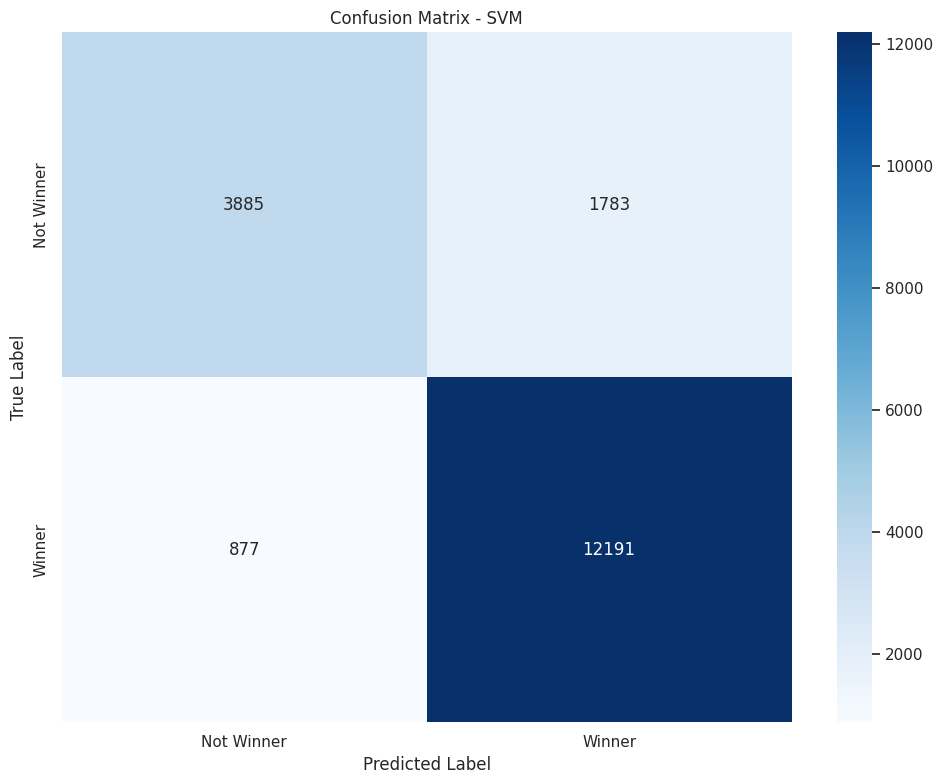

In [92]:
svm_pipeline.fit(X_train, y_train)
svm_pred = svm_pipeline.predict(X_test)
svm_proba = svm_pipeline.predict_proba(X_test)[:, 1]
evaluate_model("SVM", y_test, svm_pred, svm_proba)

Новая модель также получилась лучше предыдущей - в отличие от KNN еще и поточнее на победителях

In [93]:
import joblib

#joblib.dump(svm_pipeline, 'models_joblib/svm_pipeline_model.joblib')
#joblib.dump(best_knn_pipeline, 'models_joblib/knn_pipeline.joblib')

['models_joblib/knn_pipeline.joblib']

3. По данным у нас есть проблема с дисбалансом классов, воспользуемся SMOTE из imbalanced-learn, чтобы попробовать это поправить

Полученные хорошие модели протестим на таких преобработанных данных

In [94]:
print(data['Победитель'].value_counts())
print(y_train.value_counts())
print(y_test.value_counts())

Победитель
1    65518
0    44357
Name: count, dtype: int64
Победитель
1    52450
0    38689
Name: count, dtype: int64
Победитель
1    13068
0     5668
Name: count, dtype: int64


In [95]:
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline as ImbPipeline

balanced_pipeline_knn = ImbPipeline([
    ('preprocessor', preprocessor), 
    ('smote', SMOTE(random_state=42)),  
    ('classifier', KNeighborsClassifier(n_neighbors=19, weights='distance', metric='minkowski', p = 1))
])


Balanced KNN Metrics:
Accuracy: 0.8546
Precision: 0.8719
Recall: 0.9279
F1-Score: 0.899
ROC-AUC: 0.9467

Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.69      0.74      5668
           1       0.87      0.93      0.90     13068

    accuracy                           0.85     18736
   macro avg       0.84      0.81      0.82     18736
weighted avg       0.85      0.85      0.85     18736

Confusion Matrix:
[[ 3886  1782]
 [  942 12126]]


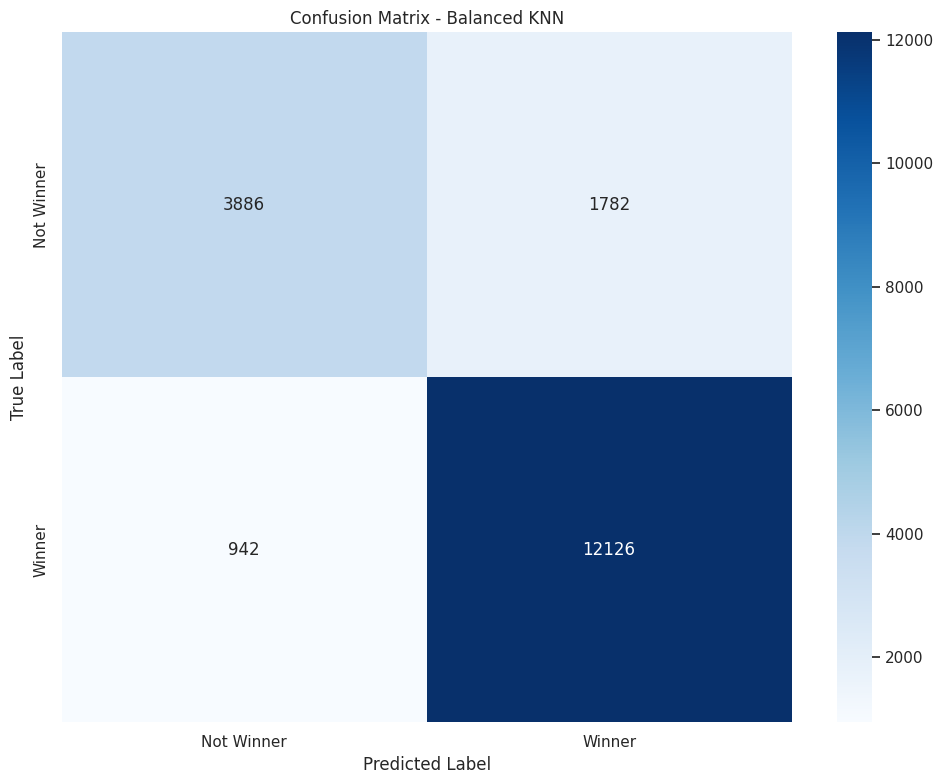

In [ ]:
balanced_pipeline_knn.fit(X_train, y_train)
y_pred = balanced_pipeline_knn.predict(X_test)
y_proba = balanced_pipeline_knn.predict_proba(X_test)[:, 1]
evaluate_model("Balanced KNN", y_test, y_pred, y_proba)


Balanced KNN Metrics:
Accuracy: 0.8546
Precision: 0.8719
Recall: 0.9278
F1-Score: 0.899
ROC-AUC: 0.9467

Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.69      0.74      5668
           1       0.87      0.93      0.90     13068

    accuracy                           0.85     18736
   macro avg       0.84      0.81      0.82     18736
weighted avg       0.85      0.85      0.85     18736

Confusion Matrix:
[[ 3886  1782]
 [  943 12125]]


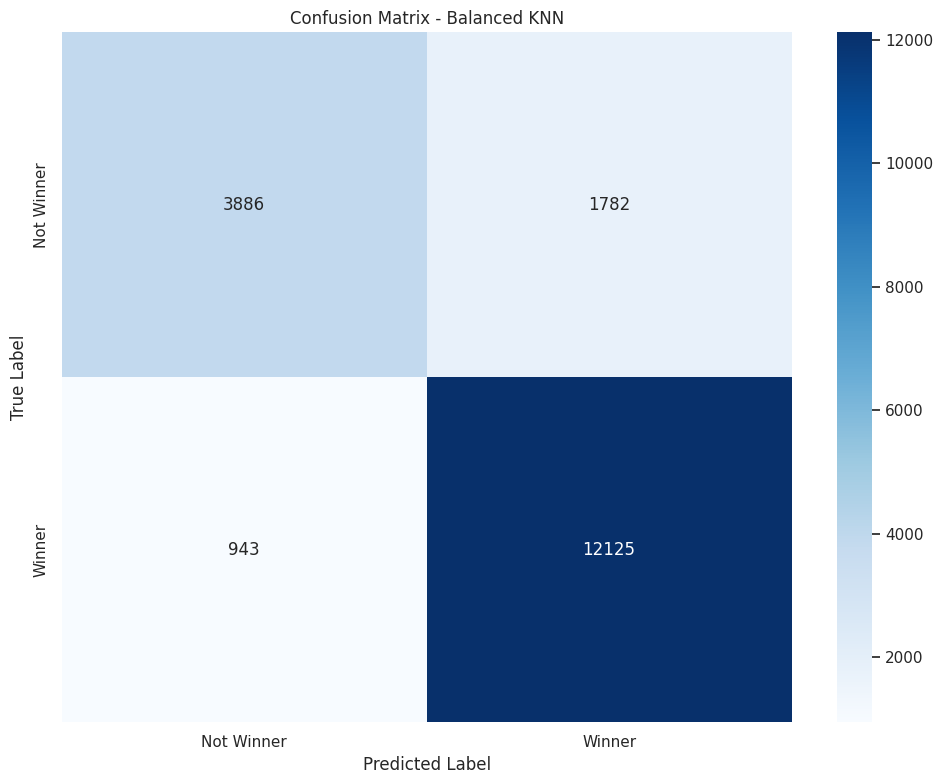

In [ ]:
balanced_pipeline_knn = ImbPipeline([
    ('preprocessor', preprocessor), 
    ('smote', SMOTE(random_state=42)),  
    ('undersampler', RandomUnderSampler(random_state=42)),
    ('classifier', KNeighborsClassifier(n_neighbors=19, weights='distance', metric='minkowski', p = 1))
])
balanced_pipeline_knn.fit(X_train, y_train)
y_pred = balanced_pipeline_knn.predict(X_test)
y_proba = balanced_pipeline_knn.predict_proba(X_test)[:, 1]
evaluate_model("Balanced KNN", y_test, y_pred, y_proba)

На KNN логичным образом почти не влияет, с SVM должно быть получше

Почему не влияет на KNN: SMOTE генерирует синтетические точки минорного класса, причем между уже существующими для миноритарного класса. Метод, который он использует (интерполяция между существующими точками), может создавать артефакты (размытые границы, шум), которые негативно влияют на KNN, так как он основывается исключительно на локальной плотности и расположении конкретных точек данных

***Возможно, впоследствие можно применить более умные версии решения дисбаланса классов***

c SVM глобально требуется абсолютно критическая регуляризация (в виде С), потому что базового он все объекты относит к одной гиперплоскости - видимо, прикол в данных и в них есть аномалии

Высокий штраф за неправильную классификацию точек обучающей выборки: Модель менее терпима к точкам, попадающим внутрь разделяющей полосы или на "неправильную" сторону, становится более чувствительной к отдельным точкам данных, включая выбросы.

Последствия:

Низкое смещение (low bias): Модель хорошо подстраивается под обучающие данные

Высокая дисперсия (high variance): Существует высокий риск переобучения (overfitting). Модель может выучить шум в данных и плохо работать на новых данных

Модель может стать более сложной (особенно с нелинейными ядрами)


Balanced SVM Metrics:
Accuracy: 0.8555
Precision: 0.8645
Recall: 0.9401
F1-Score: 0.9007
ROC-AUC: 0.9531

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.66      0.73      5668
           1       0.86      0.94      0.90     13068

    accuracy                           0.86     18736
   macro avg       0.85      0.80      0.82     18736
weighted avg       0.85      0.86      0.85     18736

Confusion Matrix:
[[ 3743  1925]
 [  783 12285]]


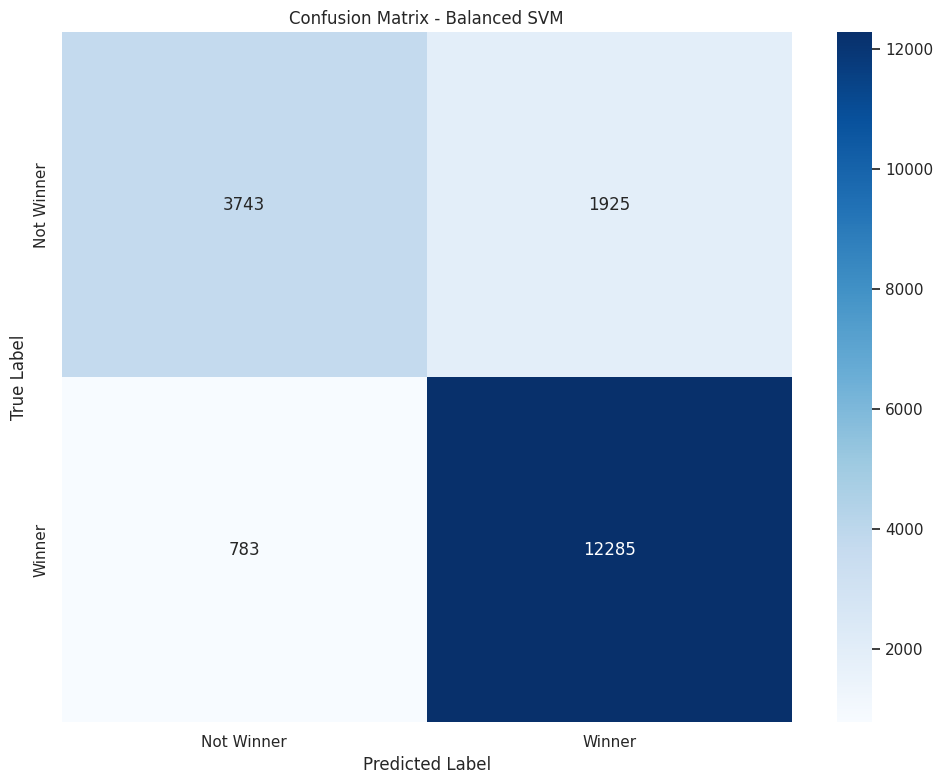

In [ ]:
balanced_pipeline_svm = ImbPipeline([
    ('preprocessor', preprocessor), 
    ('smote', SMOTE(random_state=42, sampling_strategy='auto')),  # oversampling минорного класса
    ('classifier', SVC(probability=True, random_state=42, kernel='rbf', C = 100, gamma = 'scale'))
])

balanced_pipeline_svm.fit(X_train, y_train)
y_pred = balanced_pipeline_svm.predict(X_test)
y_proba = balanced_pipeline_svm.predict_proba(X_test)[:, 1]
evaluate_model("Balanced SVM", y_test, y_pred, y_proba)

In [99]:
#joblib.dump(balanced_pipeline_svm, 'models_joblib/svm_pipeline_model.joblib')

['models_joblib/svm_pipeline_model.joblib']

Есть еще один способ решения проблемы дисбаланса классов - андерсемплинг мажорного класса на основе пропорций кластеров. Реализуем и сравним результаты

In [96]:
numeric = data.select_dtypes(include=np.number)
numeric = numeric.drop(columns=['ИНН заказчика', 'Стоимость(руб.) Заказчик', 'Реестровый номер публикации', 'ИНН поставщика', 'Победитель', 'Выручка', 'Сводный риск'])

In [ ]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.utils import resample 
from collections import Counter
import math

def proportional_cluster_undersampling(X, y, majority_label, numerical_cols, minority_label, 
    n_clusters=10,sampling_factor=1.1, random_state=42):
    
    X_maj = X[y == majority_label]
    y_maj = y[y == majority_label]
    X_min = X[y == minority_label]
    y_min = y[y == minority_label]
    
    n_minority = len(X_min)
    n_majority_original = len(X_maj)
         
    print(f"Исходный размер: Маж.={n_majority_original}, Мин.={n_minority}")

    scaler = StandardScaler()
    X_maj_numeric = X_maj[numerical_cols]
    X_maj_scaled = scaler.fit_transform(X_maj_numeric)
    kmeans = KMeans(n_clusters=n_clusters, random_state=random_state, n_init='auto')
    cluster_labels = kmeans.fit_predict(X_maj_numeric)
    
    cluster_counts = Counter(cluster_labels)
    cluster_proportions = {cls: count / n_majority_original for cls, count in cluster_counts.items()}
    print("Пропорции кластеров в исходном мажоритарном классе:")
    for cls, prop in sorted(cluster_proportions.items()):
         print(f"  Кластер {cls}: {prop:.3f} (Кол-во: {cluster_counts[cls]})")


    n_majority_target = math.ceil(n_minority * sampling_factor) 
    if n_majority_target > n_majority_original:
         print(f"Предупреждение: Целевой размер маж. класса ({n_majority_target}) больше исходного ({n_majority_original}). Используется исходный размер.")
         n_majority_target = n_majority_original
         
    print(f"Целевой размер мажоритарного класса после сэмплинга: {n_majority_target}")

    target_samples_per_cluster = {}
    total_samples_calculated = 0

    for cls, proportion in cluster_proportions.items():
         n_samples = round(n_majority_target * proportion) 
         n_samples = min(n_samples, cluster_counts[cls]) 
         target_samples_per_cluster[cls] = n_samples
         total_samples_calculated += n_samples
         

    diff = n_majority_target - total_samples_calculated
    if diff != 0:
        print(f"Корректировка размера выборки из-за округления: {diff}")
        largest_cluster = max(cluster_counts, key=cluster_counts.get)
        target_samples_per_cluster[largest_cluster] += diff
        target_samples_per_cluster[largest_cluster] = max(0, target_samples_per_cluster[largest_cluster])
        target_samples_per_cluster[largest_cluster] = min(cluster_counts[largest_cluster], target_samples_per_cluster[largest_cluster])
        final_total_samples = sum(target_samples_per_cluster.values())
        if final_total_samples != n_majority_target:
             print(f"Предупреждение: Не удалось точно достичь целевого размера {n_majority_target} из-за округления и размеров кластеров. Итоговый размер: {final_total_samples}")


    sampled_indices = []
    majority_indices = X_maj.index 

    for cls, n_to_sample in target_samples_per_cluster.items():
        if n_to_sample == 0:
            continue
            
        indices_in_cluster = majority_indices[cluster_labels == cls]
        n_to_sample = min(n_to_sample, len(indices_in_cluster)) 
        
        if n_to_sample > 0:
             sampled_cluster_indices = resample(
                 indices_in_cluster, 
                 n_samples=n_to_sample, 
                 replace=False,
                 random_state=random_state
             )
             sampled_indices.extend(sampled_cluster_indices)
             
 
    X_maj_sampled = X_maj.loc[sampled_indices]
    y_maj_sampled = y_maj.loc[sampled_indices]
    
    X_resampled = pd.concat([X_maj_sampled, X_min], ignore_index=True)
    y_resampled = pd.concat([y_maj_sampled, y_min], ignore_index=True)
    
    np.random.seed(random_state) 
    shuffled_indices = np.random.permutation(len(X_resampled))
    X_resampled = X_resampled.iloc[shuffled_indices].reset_index(drop=True)
    y_resampled = y_resampled.iloc[shuffled_indices].reset_index(drop=True)
    
    print(f"Итоговый размер: {len(X_resampled)}")
    print("Распределение классов в итоговой выборке:")
    print(y_resampled.value_counts())
    
    return X_resampled, y_resampled


majority_class_label = 1 
minority_class_label = 0 

X_new_train = preprocessor.fit_transform(X_train)

X_train_resampled, y_train_resampled = proportional_cluster_undersampling(
    X=X_train, y=y_train, 
    majority_label=majority_class_label, minority_label=minority_class_label, 
    n_clusters=10, sampling_factor=1.1, random_state=42, numerical_cols=numeric.columns.tolist()    
)

Исходный размер: Маж.=52450, Мин.=38689
Пропорции кластеров в исходном мажоритарном классе:
  Кластер 0: 0.029 (Кол-во: 1538)
  Кластер 1: 0.811 (Кол-во: 42547)
  Кластер 2: 0.007 (Кол-во: 352)
  Кластер 3: 0.007 (Кол-во: 370)
  Кластер 4: 0.005 (Кол-во: 276)
  Кластер 5: 0.020 (Кол-во: 1023)
  Кластер 6: 0.043 (Кол-во: 2267)
  Кластер 7: 0.058 (Кол-во: 3057)
  Кластер 8: 0.014 (Кол-во: 748)
  Кластер 9: 0.005 (Кол-во: 272)
Целевой размер мажоритарного класса после сэмплинга: 42558
Итоговый размер: 81247
Распределение классов в итоговой выборке:
Победитель
1    42558
0    38689
Name: count, dtype: int64



Balanced KNN Metrics:
Accuracy: 0.8633
Precision: 0.8951
Recall: 0.9106
F1-Score: 0.9028
ROC-AUC: 0.9469

Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.75      0.77      5668
           1       0.90      0.91      0.90     13068

    accuracy                           0.86     18736
   macro avg       0.84      0.83      0.84     18736
weighted avg       0.86      0.86      0.86     18736

Confusion Matrix:
[[ 4274  1394]
 [ 1168 11900]]


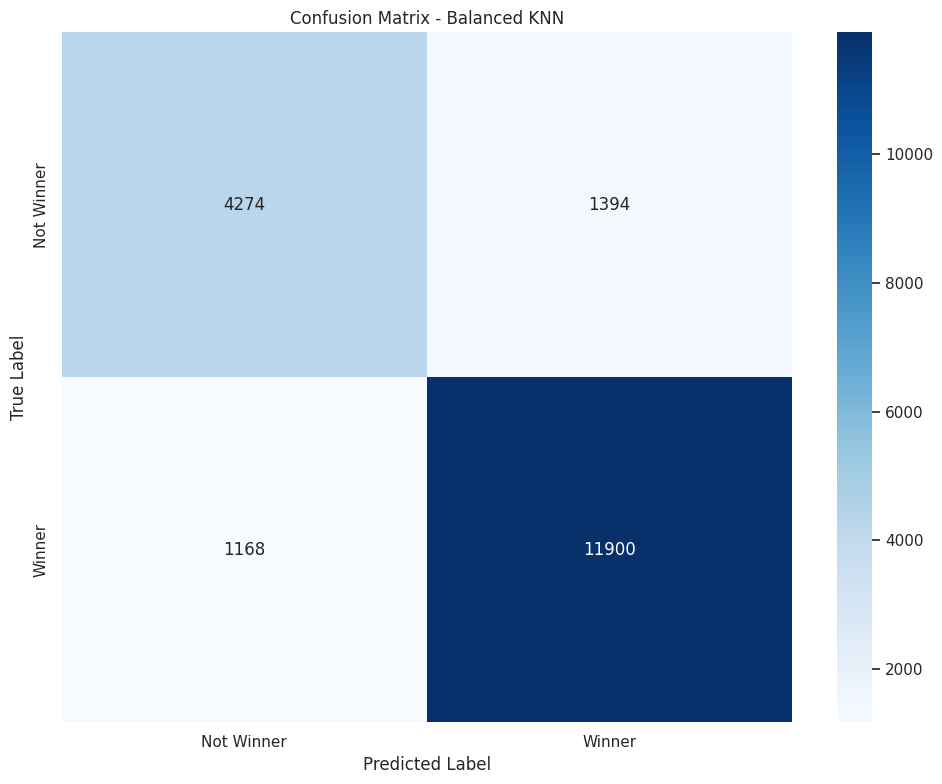

In [116]:
knn_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', KNeighborsClassifier(n_neighbors=grid_search.best_params_['classifier__n_neighbors'], weights=grid_search.best_params_['classifier__weights'], metric=grid_search.best_params_['classifier__metric'], p = grid_search.best_params_['classifier__p']))
])

knn_pipeline.fit(X_train_resampled, y_train_resampled)
y_pred = knn_pipeline.predict(X_test)
y_proba = knn_pipeline.predict_proba(X_test)[:, 1]
evaluate_model("Balanced KNN", y_test, y_pred, y_proba)

In [118]:
#joblib.dump(knn_pipeline, 'models_joblib/knn_with_undersampling')

['models_joblib/knn_with_undersampling']

Этим способом получили модель с наилучшим предсказанием для не победителей, при этом верно предсказанные победители уменьшились не сильно, победа


Balanced SVM Metrics:
Accuracy: 0.8526
Precision: 0.86
Recall: 0.942
F1-Score: 0.8991
ROC-AUC: 0.9522

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.65      0.73      5668
           1       0.86      0.94      0.90     13068

    accuracy                           0.85     18736
   macro avg       0.84      0.79      0.81     18736
weighted avg       0.85      0.85      0.85     18736

Confusion Matrix:
[[ 3664  2004]
 [  758 12310]]


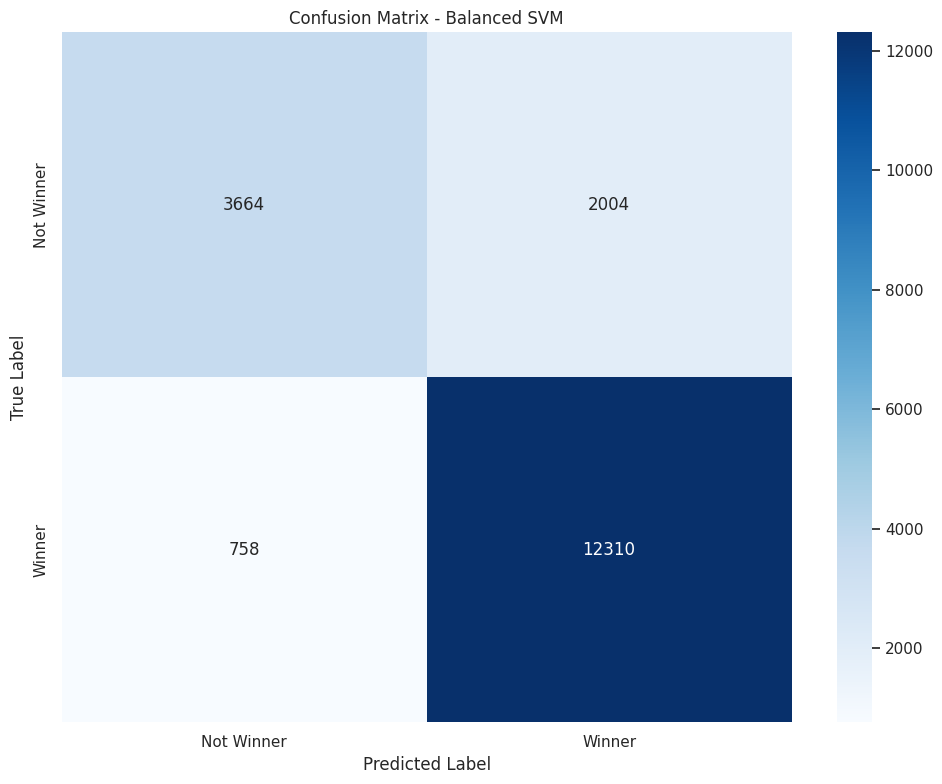

In [117]:
pipeline_svm = Pipeline([
    ('preprocessor', preprocessor), 
    ('classifier', SVC(probability=True, random_state=42, kernel='rbf', C = 100, gamma = 'scale'))
])

pipeline_svm.fit(X_train_resampled, y_train_resampled)
y_pred = pipeline_svm.predict(X_test)
y_proba = pipeline_svm.predict_proba(X_test)[:, 1]
evaluate_model("Balanced SVM", y_test, y_pred, y_proba)

Для SVM получился результат не так значительно лучше предыдущего: видимо, для SVM лучше работает SMOTE, а для KNN - наоборот такой способ решения проблемы дисбаланса

4. Нейросети: MLP

In [83]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from sklearn.model_selection import train_test_split
import copy 
from typing import List, Tuple, Any, Optional, Dict
from tqdm.auto import tqdm 
import os

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

/Users/polina/b2b_reccomendation_systems/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [84]:
class TenderDataset(Dataset):
    def __init__(self, X: np.ndarray, y: np.ndarray):
        if isinstance(X, pd.DataFrame):
            X = X.values
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32).unsqueeze(1)

    def __len__(self) -> int:
        return len(self.X)

    def __getitem__(self, idx: int) -> Tuple[torch.Tensor, torch.Tensor]:
        return self.X[idx], self.y[idx]

class TenderNet(nn.Module):
    def __init__(self, input_size: int, hidden_size1: int = 100, hidden_size2: int = 50, dropout_rate: float = 0.3):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(input_size, hidden_size1),
            nn.ReLU(),
            nn.BatchNorm1d(hidden_size1),
            nn.Dropout(dropout_rate),
            nn.Linear(hidden_size1, hidden_size2),
            nn.ReLU(),
            nn.BatchNorm1d(hidden_size2),
            nn.Dropout(dropout_rate),
            nn.Linear(hidden_size2, 1)
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.layers(x)

def create_weighted_sampler(y: np.ndarray) -> WeightedRandomSampler:
    if isinstance(y, torch.Tensor):
        y = y.cpu().numpy()

    class_counts = np.bincount(y.astype(int))
    if len(class_counts) < 2:
         print("Warning: Only one class present in the sample for sampler calculation.")
         class_weights = torch.ones(len(np.unique(y)), dtype=torch.float)
    elif class_counts[0] == 0 or class_counts[1] == 0:
         print(f"Warning: Class imbalance calculation error. Counts: {class_counts}")
         class_weights = torch.ones(len(class_counts), dtype=torch.float)
    else:
         class_weights = 1. / torch.tensor(class_counts, dtype=torch.float)

    sample_weights = class_weights[y.astype(int)]
    sampler = WeightedRandomSampler(
        weights=sample_weights,
        num_samples=len(sample_weights),
        replacement=True
    )
    return sampler

In [85]:
def train_model(
    model_params: Dict[str, Any], 
    train_params: Dict[str, Any], 
    X_train_orig: pd.DataFrame, 
    y_train_orig: pd.Series,
    X_val_orig: pd.DataFrame,
    y_val_orig: pd.Series,
    preprocessor: ColumnTransformer,
    n_epochs: int = 100,
    patience: int = 10,
    use_sampler: bool = True,
    device: torch.device = torch.device("cpu"), 
    save_path: Optional[str] = None, 
    preprocessor_save_path: Optional[str] = None
    ) -> Tuple[nn.Module, float]: 

    print("Preprocessing data...")
    preprocessor.fit(X_train_orig) 
    X_train_processed = preprocessor.transform(X_train_orig)
    X_val_processed = preprocessor.transform(X_val_orig)
    
    input_size = X_train_processed.shape[1]
    model_params['input_size'] = input_size 
    
    if preprocessor_save_path:
        print(f"Saving fitted preprocessor to {preprocessor_save_path}...")
        os.makedirs(os.path.dirname(preprocessor_save_path), exist_ok=True)
        joblib.dump(preprocessor, preprocessor_save_path)
        print("Preprocessor saved.")


    learning_rate = train_params.get('learning_rate', 0.001)
    batch_size = train_params.get('batch_size', 64)
    optimizer_name = train_params.get('optimizer', 'Adam')

    y_train_np = y_train_orig.values if hasattr(y_train_orig, 'values') else np.array(y_train_orig)
    y_val_np = y_val_orig.values if hasattr(y_val_orig, 'values') else np.array(y_val_orig)
    
    train_dataset = TenderDataset(X_train_processed, y_train_np)
    val_dataset = TenderDataset(X_val_processed, y_val_np)

    sampler: Optional[WeightedRandomSampler] = None
    shuffle: bool = True
    if use_sampler:
        sampler = create_weighted_sampler(y_train_np)
        shuffle = False # Если используем сэмплер, shuffle должен быть False
        print("Weighted sampler created successfully.")
    else:
        print("Weighted sampler is disabled.")

    train_loader = DataLoader(
        train_dataset, batch_size=batch_size, sampler=sampler, shuffle=shuffle,
        num_workers=0, pin_memory=True if device.type == "cuda" else False
    )
    val_loader = DataLoader(
        val_dataset, batch_size=batch_size * 2, shuffle=False, 
        num_workers=0, pin_memory=True if device.type == "cuda" else False
    )

    model = TenderNet(**model_params).to(device)
    criterion = nn.BCEWithLogitsLoss() 

    if optimizer_name.lower() == 'adam':
         optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    elif optimizer_name.lower() == 'rmsprop':
         optimizer = optim.RMSprop(model.parameters(), lr=learning_rate)
    else:
         optimizer = optim.Adam(model.parameters(), lr=learning_rate) 
         
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=patience // 2, factor=0.1)
    best_val_loss = float('inf')
    epochs_no_improve = 0
    best_model_state = None

    epochs_pbar = tqdm(range(n_epochs), desc="Epoch Progress")
    for epoch in epochs_pbar:
        model.train()
        running_loss = 0.0
        train_pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{n_epochs} [Train]", leave=False)
        for inputs, labels in train_pbar:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * inputs.size(0)
            train_pbar.set_postfix(loss=f"{loss.item():.4f}") 

        avg_train_loss = running_loss / len(train_loader.dataset) 

        model.eval()
        val_loss = 0.0
        val_pbar = tqdm(val_loader, desc=f"Epoch {epoch+1}/{n_epochs} [Val]", leave=False)
        with torch.no_grad():
            for inputs, labels in val_pbar:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                val_loss += loss.item() * inputs.size(0) 
                val_pbar.set_postfix(loss=f"{loss.item():.4f}")

        avg_val_loss = val_loss / len(val_loader.dataset) 

        epochs_pbar.set_postfix(TrainLoss=f"{avg_train_loss:.4f}", ValLoss=f"{avg_val_loss:.4f}")
        scheduler.step(avg_val_loss)

        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            epochs_no_improve = 0
            best_model_state = copy.deepcopy(model.state_dict())
            if save_path:
                 print(f"  Saving improved model to {save_path} (Val Loss: {best_val_loss:.4f})...")
                 os.makedirs(os.path.dirname(save_path), exist_ok=True)
                 torch.save(best_model_state, save_path)

        else:
            epochs_no_improve += 1

        if epochs_no_improve >= patience:
            print(f"\nEarly stopping triggered after {epoch+1} epochs.")
            epochs_pbar.close()
            train_pbar.close()
            val_pbar.close()
            break

    if best_model_state:
        print(f"\nLoading best model state with Val Loss: {best_val_loss:.4f}")
        model.load_state_dict(best_model_state)
    else:
        print("\nWarning: No best model state was found/saved. Returning last state.")

        if save_path:
             print(f"  Saving last model state to {save_path}...")
             os.makedirs(os.path.dirname(save_path), exist_ok=True)
             torch.save(model.state_dict(), save_path)


    print("Training finished.")
    return model, best_val_loss 

In [88]:
def predict_proba(model: nn.Module, X: np.ndarray, preprocessor: ColumnTransformer, device: torch.device, batch_size: int = 256) -> np.ndarray:
    X_processed = preprocessor.transform(X)
    pred_dataset = torch.utils.data.TensorDataset(torch.tensor(X_processed, dtype=torch.float32))
    pred_loader = DataLoader(pred_dataset, batch_size=batch_size, shuffle=False)
    pred_pbar = tqdm(pred_loader, desc="Predicting")

    model.eval()
    all_probabilities = []
    with torch.no_grad():
        for batch in pred_pbar:
            inputs = batch[0].to(device)
            logits = model(inputs)
            probabilities = torch.sigmoid(logits)
            all_probabilities.append(probabilities.cpu().numpy())

    all_probabilities = np.concatenate(all_probabilities, axis=0)
    return all_probabilities.squeeze()

In [87]:
def predict_proba(model: nn.Module, X: pd.DataFrame, preprocessor: ColumnTransformer, device: torch.device, batch_size: int = 256) -> np.ndarray:
    X_processed = preprocessor.transform(X) 
    X_processed = X_processed.toarray()
    pred_tensor = torch.tensor(X_processed, dtype=torch.float32)
    pred_dataset = torch.utils.data.TensorDataset(pred_tensor)
    pred_loader = DataLoader(pred_dataset, batch_size=batch_size, shuffle=False)
    pred_pbar = tqdm(pred_loader, desc="Predicting", leave=False)

    model.eval() 
    all_probabilities = []
    with torch.no_grad(): 
        for batch in pred_pbar:
            inputs = batch[0].to(device)
            logits = model(inputs)
            probabilities = torch.sigmoid(logits) 
            all_probabilities.append(probabilities.cpu().numpy())

    all_probabilities = np.concatenate(all_probabilities, axis=0)
    return all_probabilities.squeeze() if all_probabilities.ndim > 1 else all_probabilities


Preprocessing data...
Weighted sampler created successfully.


Epoch Progress:  38%|███▊      | 19/50 [02:09<03:31,  6.82s/it, TrainLoss=0.0651, ValLoss=0.0921]



Early stopping triggered after 20 epochs.

Loading best model state with Val Loss: 0.0872
Training finished.


Predicting: 100%|██████████| 74/74 [00:00<00:00, 246.07it/s]



MLP Metrics:
Accuracy: 0.8715
Precision: 0.9167
Recall: 0.8973
F1-Score: 0.9069
ROC-AUC: 0.9561

Classification Report:
              precision    recall  f1-score   support

           0       0.77      0.81      0.79      5668
           1       0.92      0.90      0.91     13068

    accuracy                           0.87     18736
   macro avg       0.85      0.85      0.85     18736
weighted avg       0.87      0.87      0.87     18736

Confusion Matrix:
[[ 4602  1066]
 [ 1342 11726]]


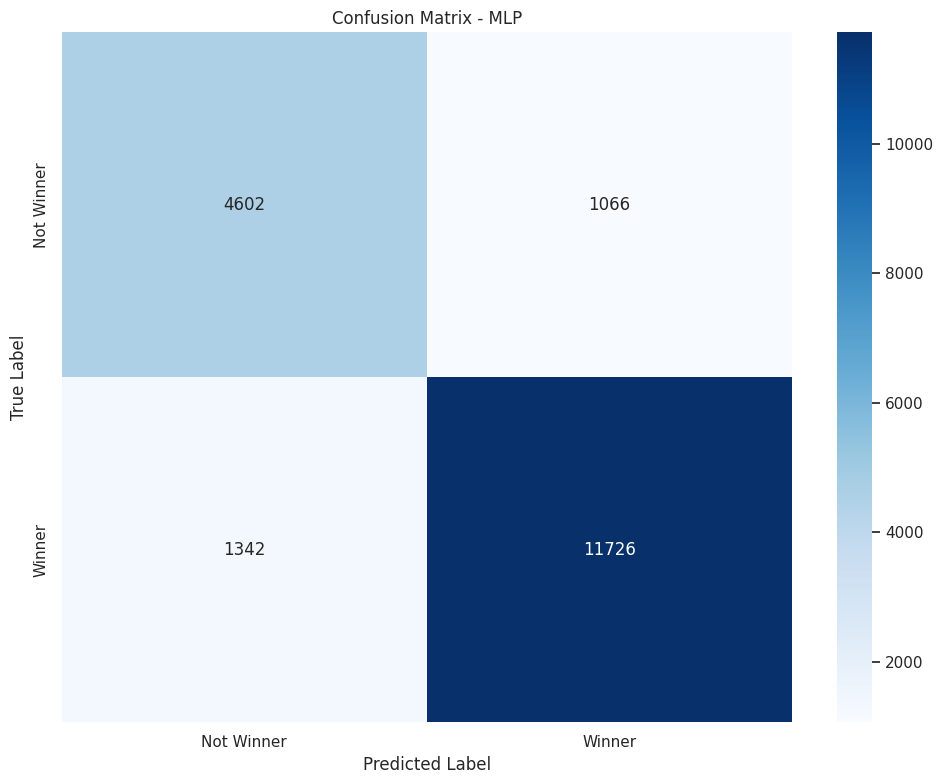

In [91]:
num = [
    "avg_price_drop",
    "log_cost",
    "log_profit",
    "Снижение на торгах,%",
    'win_rate',  'region_win_rate', 
    'customer_win_rate', 'sphere_win_rate',
    "days_between",
    "region_wins",
    "customer_wins",
    "sphere_wins",
    "total_wins",
    "competitors_per_tender",
    "avg_competitors_in_region",
    "avg_competitors_in_sphere",
    "avg_competitors_in_customer"
]

cat = [
    "Сфера деятельности",
    "Регион поставки",
    "Город поставки",
    "Тип торгов",
    "Уровень",
    "year",
    "month",
    "Сводный риск"
]

binary_features = [
    "РНП ранее", 
    "is_january", 
    "publication_peak_9_11", 
    "app_end_noon_12", 
    "app_start_night_12",
    "trade_end_night_12",
    "is_2020",
    "Статус допуска"
]

preprocessor = ColumnTransformer(
    transformers=[
        ('num', RobustScaler(), num),
        ('cat', OneHotEncoder(sparse_output=False, handle_unknown='ignore'), cat),
        ('pass', 'passthrough', binary_features)
    ],
    remainder='drop'
    )


X_train_split, X_val_split, y_train_split, y_val_split = train_test_split(X_train, y_train, test_size=0.2, random_state=42, stratify=y_train)

trained_model, val_loss = train_model(
    model_params = {
        'hidden_size1': 150,
        'hidden_size2': 100,
        'dropout_rate': 0.3
    },
    train_params = {
        'learning_rate': 1e-3,
        'batch_size': 64,
        'optimizer':'Adam'
    },
    X_train_orig=X_train_split,
    y_train_orig=y_train_split,
    X_val_orig = X_val_split,
    y_val_orig=y_val_split,
    preprocessor=preprocessor,
    n_epochs=50,
    patience=10,
    use_sampler=True, 
    device=device
)

y_proba = predict_proba(trained_model, X_test, preprocessor, device)
y_pred = (y_proba > 0.5).astype(int)
evaluate_model("MLP", y_test, y_pred, y_proba)

Теперь обучим на андерсемплированном мажорном классе с использованием unsupervised кластеризации. Как можно видеть ниже, получилось иначе, по сравнению с использованием оригинальных данных и использованием class_weight - но можно заметить, что во всех моделях есть трейд офф между precision и recall - за счет различных гиперпараметров можно получить более точные модели на победителей, и на непобедителей

Preprocessing data...
Weighted sampler is disabled.


Epoch Progress:  38%|███▊      | 19/50 [02:28<04:02,  7.83s/it, TrainLoss=0.0632, ValLoss=0.0882]



Early stopping triggered after 20 epochs.

Loading best model state with Val Loss: 0.0820
Training finished.


Predicting: 100%|██████████| 74/74 [00:00<00:00, 225.21it/s]



MLP Metrics:
Accuracy: 0.8644
Precision: 0.8841
Recall: 0.9271
F1-Score: 0.9051
ROC-AUC: 0.9557

Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.72      0.76      5668
           1       0.88      0.93      0.91     13068

    accuracy                           0.86     18736
   macro avg       0.85      0.82      0.83     18736
weighted avg       0.86      0.86      0.86     18736

Confusion Matrix:
[[ 4080  1588]
 [  953 12115]]


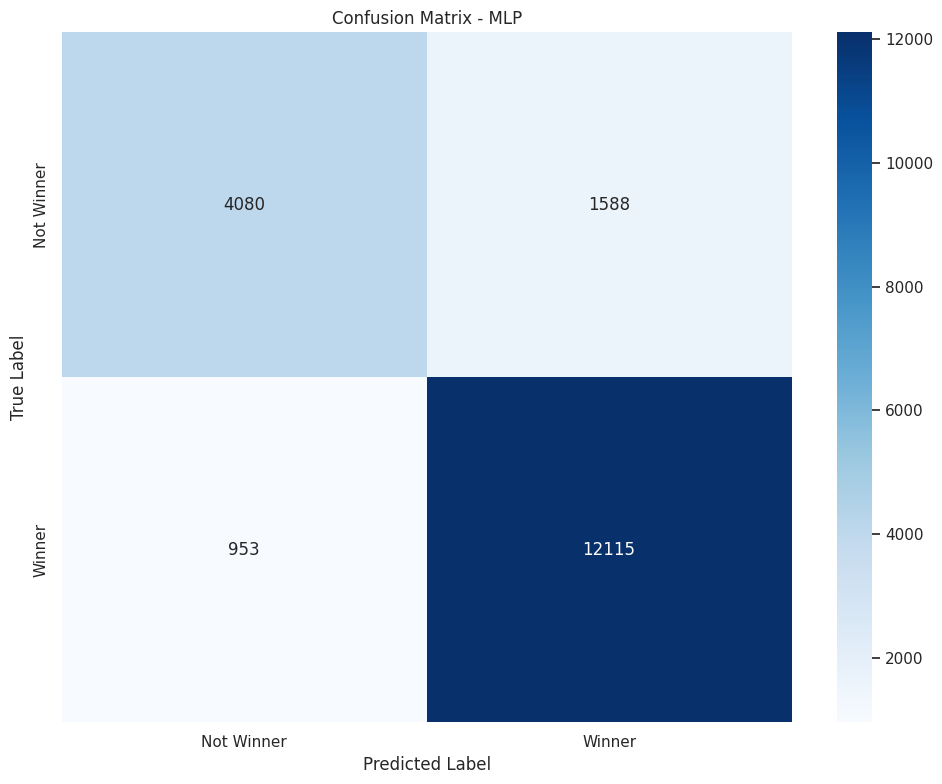

In [100]:
X_train_split, X_val_split, y_train_split, y_val_split = train_test_split(X_train_resampled, y_train_resampled, test_size=0.2, random_state=42)

trained_model, val_loss = train_model(
    model_params = {
        'hidden_size1': 256,
        'hidden_size2': 64,
        'dropout_rate': 0.3
    },
    train_params = {
        'learning_rate': 1e-3,
        'batch_size': 64,
        'optimizer':'Adam'
    },
    X_train_orig=X_train_split,
    y_train_orig=y_train_split,
    X_val_orig = X_val_split,
    y_val_orig=y_val_split,
    preprocessor=preprocessor,
    n_epochs=50,
    patience=10,
    use_sampler=False, 
    device=device
)

y_proba = predict_proba(trained_model, X_test, preprocessor, device)
y_pred = (y_proba > 0.5).astype(int)
evaluate_model("MLP", y_test, y_pred, y_proba)

In [92]:
import optuna
from sklearn.base import clone

def objective(
    trial: optuna.Trial, 
    X_train_orig: pd.DataFrame, 
    y_train_orig: pd.Series, 
    X_val_orig: pd.DataFrame, 
    y_val_orig: pd.Series, 
    preprocessor_base: ColumnTransformer, 
    n_epochs: int, 
    patience: int, 
    use_sampler: bool,
    device: torch.device
    ):

    model_params = {
        'hidden_size1': trial.suggest_int('hidden_size1', 64, 256, log=True),
        'hidden_size2': trial.suggest_int('hidden_size2', 32, 128, log=True),
        'dropout_rate': trial.suggest_float('dropout_rate', 0.1, 0.5, step=0.1)
    }
    train_params = {
        'learning_rate': trial.suggest_float('learning_rate', 1e-5, 1e-2, log=True),
        'batch_size': trial.suggest_categorical('batch_size', [32, 64, 128, 256]),
        'optimizer': trial.suggest_categorical('optimizer', ['Adam', 'RMSprop'])
    }
    
    trial_preprocessor = clone(preprocessor_base)

    _, best_val_loss = train_model(
             model_params=model_params,
             train_params=train_params,
             X_train_orig=X_train_orig,
             y_train_orig=y_train_orig,
             X_val_orig=X_val_orig,
             y_val_orig=y_val_orig,
             preprocessor=trial_preprocessor, 
             n_epochs=n_epochs,
             patience=patience,
             use_sampler=use_sampler,
             device=device,
             save_path=None, 
             preprocessor_save_path=None 
    )
    
    return best_val_loss

In [101]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

preprocessor_base = ColumnTransformer(
    transformers=[
        ('num', RobustScaler(), num),
        ('cat', OneHotEncoder(sparse_output=False, handle_unknown='ignore'), cat),
        ('bin', 'passthrough', binary_features) 
    ],
    remainder='drop',
    verbose_feature_names_out=False 
)

preprocessor_base.set_output(transform='pandas') 

X_train_opt, X_val_opt, y_train_opt, y_val_opt = train_test_split(
    X_train, y_train, test_size=0.25, random_state=42 
)

study = optuna.create_study(direction='minimize', study_name='tender_net_optimization')
objective_with_data = lambda trial: objective(
    trial, 
    X_train_opt, y_train_opt, X_val_opt, y_val_opt, 
    preprocessor_base, 
    n_epochs=10,       
    patience=5,       
    use_sampler=True,  
    device=device
)

#study.optimize(objective_with_data, n_trials=10, show_progress_bar=True)


[I 2025-04-17 14:42:36,107] A new study created in memory with name: tender_net_optimization


In [93]:
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.inspection import permutation_importance

class PyTorchSklearnWrapper(BaseEstimator, ClassifierMixin):
    def __init__(self, model, device):
        self.model = model
        self.device = device
        self.classes_ = np.array([0, 1])
        self.model.to(self.device)
        self.model.eval()

    def fit(self, X, y=None):
        return self

    def predict_proba(self, X):
        self.model.eval() 
        all_probabilities = []
        pred_dataset = torch.utils.data.TensorDataset(torch.tensor(X, dtype=torch.float32))
        pred_loader = DataLoader(pred_dataset, batch_size=256, shuffle=False)

        with torch.no_grad():
            for batch in pred_loader: 
                inputs = batch[0].to(self.device)
                logits = self.model(inputs)
                probabilities_pos = torch.sigmoid(logits)
                probabilities_pos_np = probabilities_pos.cpu().numpy()
                # Вероятность класса 0 = 1 - вероятность класса 1
                probabilities_neg_np = 1.0 - probabilities_pos_np
                batch_probs = np.hstack((probabilities_neg_np, probabilities_pos_np))
                all_probabilities.append(batch_probs)


        all_probabilities = np.concatenate(all_probabilities, axis=0)
        return all_probabilities

    def predict(self, X):
        probabilities = self.predict_proba(X)
        return np.argmax(probabilities, axis=1)


sklearn_estimator = PyTorchSklearnWrapper(trained_model, device)
X_val_processed = preprocessor.transform(X_val_split)
y_val_np = y_val_split.values if hasattr(y_val_split, 'values') else y_val_split


feature_names_processed = preprocessor.get_feature_names_out()
print(f"{len(feature_names_processed)} feature names after preprocessing.")

print("Calculating permutation importance using wrapper...")
result = permutation_importance(
    estimator=sklearn_estimator,      
    X=X_val_processed,          
    y=y_val_np,
    scoring='f1',             
    #scoring=make_scorer(lambda est, x, y: f1_score(y, est.predict(x)))
    n_repeats=1,                 
    random_state=42
)

perm_importance_df = pd.DataFrame(
    {'feature': feature_names_processed,
     'importance_mean': result.importances_mean,
     'importance_std': result.importances_std}
).sort_values('importance_mean', ascending=False)

print("\n--- Permutation Importance (Top 20) ---")
print(perm_importance_df.head(20))
#примерно полтора часа

6715 feature names after preprocessing.
Calculating permutation importance using wrapper...

--- Permutation Importance (Top 20) ---
                                                feature  importance_mean  \
6708                              pass__sphere_win_rate             0.17   
6706                            pass__customer_win_rate             0.16   
6705                                pass__customer_wins             0.01   
6687                         cat__Тип торгов_Неизвестно             0.01   
6703                                  pass__region_wins             0.01   
6702                                     pass__win_rate             0.00   
6673  cat__Тип торгов_Закупка у единственного постав...             0.00   
6672                cat__Тип торгов_Аукцион электронный             0.00   
3958  cat__Сфера деятельности_[ОКПД2 42.21] Сооружен...             0.00   
6692                               pass__Статус допуска             0.00   
6711                       pass

/var/folders/7_/sz_ftshd1b1b9sppxlm9vj9m0000gn/T/ipykernel_25093/3561367101.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


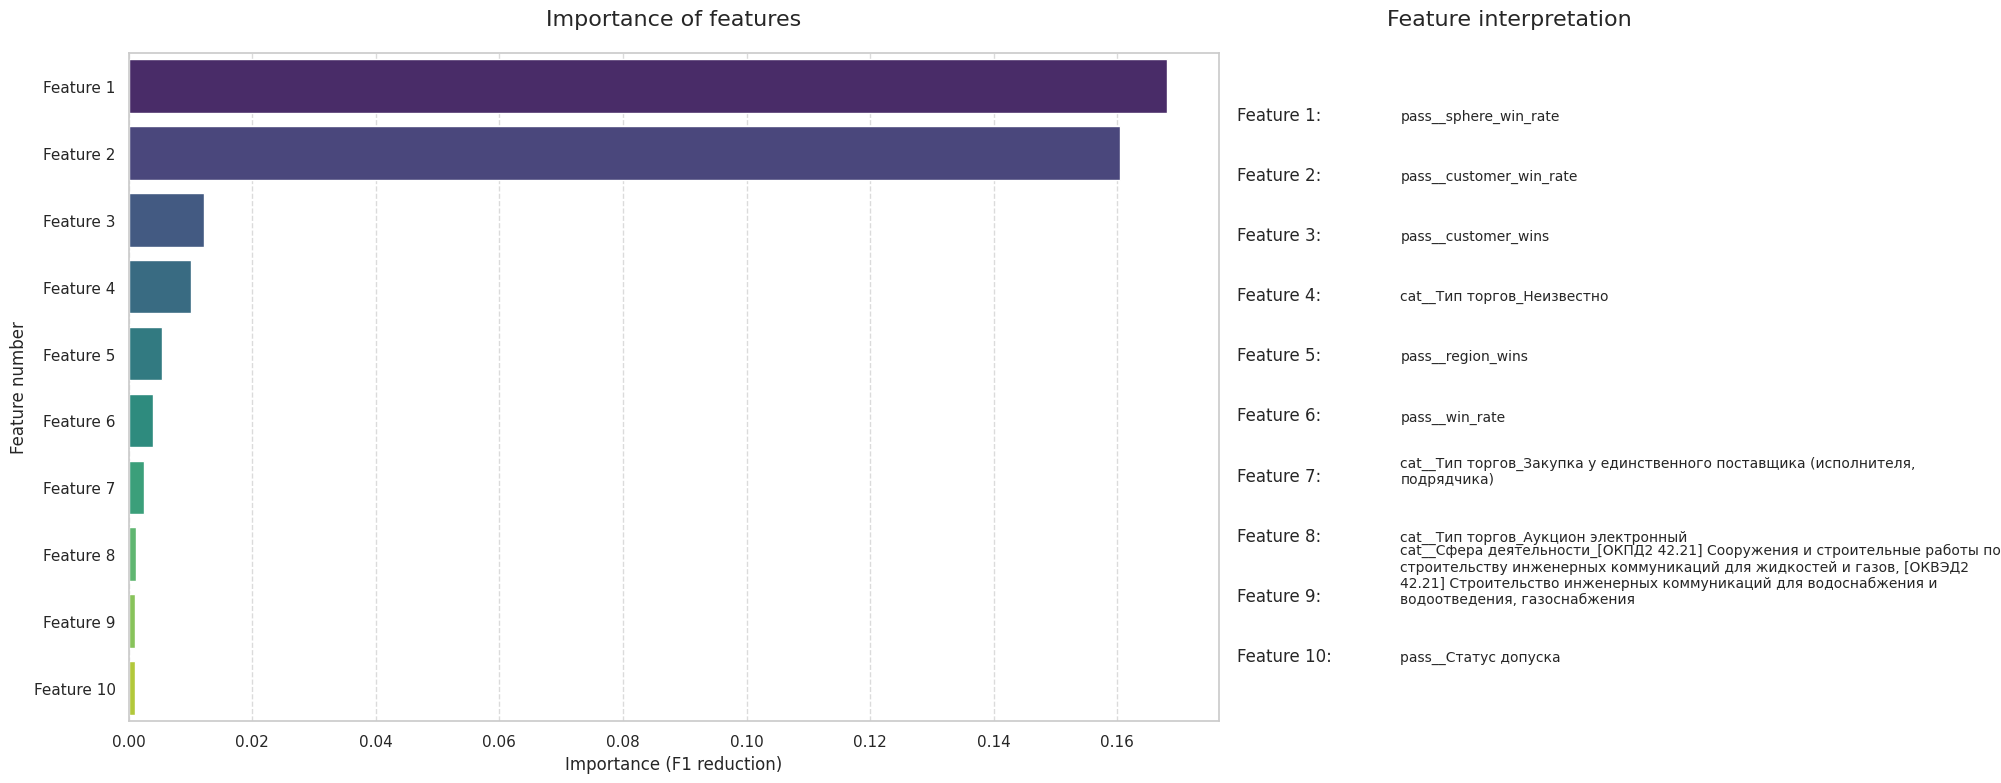

In [105]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8), gridspec_kw={'width_ratios': [2, 1]})
top_n = 10
perm_importance_df_top = perm_importance_df.head(top_n)
feature_names = [f'Feature {i+1}' for i in range(len(perm_importance_df_top))]

sns.barplot(
    x='importance_mean',
    y=feature_names,
    data=perm_importance_df_top,
    palette='viridis',
    errorbar='se',
    capsize=5,
    ax=ax1
)

ax1.set_title('Importance of features', fontsize=16, pad=20)
ax1.set_xlabel('Importance (F1 reduction)', fontsize=12)
ax1.set_ylabel('Feature number', fontsize=12)
ax1.grid(True, axis='x', linestyle='--', alpha=0.7)
ax2.axis('off')
ax2.set_title('Feature interpretation', fontsize=16, pad=20)
for i, (name, feature) in enumerate(zip(feature_names, perm_importance_df_top['feature'])):
    ax2.text(0, 0.9 - i*0.09, f'{name}:', fontsize=12)
    ax2.text(0.3, 0.9 - i*0.09, feature, fontsize=10, wrap=True)

plt.tight_layout()
plt.show()

такие результаты еще и из-за того, что я установила n_repeats=1, то есть каждая фича изменяется только один раз для оценки ее влияния на f1_score - по идее конечно надо бы больше, но не было времени столько ждать сейчас 

***Можно получить результаты лучше (и быстрее), если сначала, например, по Lasso или по деревьям (LightGBM, XGBoost) вытащить важность признаков, чтобы отобрать топ N признаков перед обучением MLP или перед расчетом важности для MLP***

Еще можно вместо One-Hot Encoding для категориальных признаков с большим количеством уникальных значений использовать
Embedding слои в нейронной сети, сильно уменьшит количество входных признаков

_______________________________________________________________________________________________________________________________

**Второй этап: непосредственно рекомендации для нового тендера**

DONE IN second_stage_check.ipynb